In [1]:
!pip install mne

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install gtts --no-deps --quiet
!pip install pyttsx3 --no-deps --quiet

In [3]:
!pip install transformers accelerate --quiet

In [4]:
# =============================================================================
# SECTION 1.1 — IMPORTS
# =============================================================================

# ---- Standard library -------------------------------------------------------
import os
import gc
import sys
import time
import json
import random
import shutil
import logging
import zipfile
import warnings
import platform
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Tuple, Union, Any, Callable

# ---- Numerical / scientific computing ---------------------------------------
import numpy as np
import pandas as pd
import scipy
import scipy.signal
import scipy.stats

# ---- Plotting -----------------------------------------------------------------
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ---- EEG processing -----------------------------------------------------------
import mne
mne.set_log_level("WARNING")

# ---- Machine learning ----------------------------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import xgboost as xgb

# ---- Deep learning --------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
import torchmetrics

# ---- Progress bars -----------------------------------------------------------------
from tqdm.auto import tqdm

# ---- Suppress noisy / non-actionable warnings ---------------------------------------
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print("All imports successful.")
print(f"Python version : {platform.python_version()}")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")
print(f"SciPy version  : {scipy.__version__}")
print(f"MNE version    : {mne.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"scikit-learn   : {__import__('sklearn').__version__}")
print(f"XGBoost version: {xgb.__version__}")

/home/23adr054/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.
Python version : 3.11.11
NumPy version  : 1.26.4
Pandas version : 2.2.3
SciPy version  : 1.13.1
MNE version    : 1.12.1
PyTorch version: 2.7.0+cu126
scikit-learn   : 1.9.0
XGBoost version: 3.2.0


In [5]:
# =============================================================================
# SECTION 1.2 — REPRODUCIBILITY
# =============================================================================

GLOBAL_SEED = 42

def set_global_seed(seed: int = GLOBAL_SEED, deterministic: bool = True) -> None:
    """Seed every RNG used in this notebook and configure deterministic execution."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except TypeError:
            torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    logging.getLogger(__name__).info(f"Global seed set to {seed} (deterministic={deterministic})")


def seed_worker(worker_id: int) -> None:
    """DataLoader worker_init_fn — pass to DataLoader(..., worker_init_fn=seed_worker)."""
    worker_seed = (GLOBAL_SEED + worker_id) % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


dataloader_generator = torch.Generator()
dataloader_generator.manual_seed(GLOBAL_SEED)

set_global_seed(GLOBAL_SEED, deterministic=True)
print(f"Reproducibility configured. GLOBAL_SEED = {GLOBAL_SEED}")

Reproducibility configured. GLOBAL_SEED = 42


In [6]:
# =============================================================================
# SECTION 1.3 — HARDWARE DETECTION & MIXED PRECISION
# =============================================================================

def detect_device() -> torch.device:
    """Return the best available torch.device: CUDA > MPS > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = detect_device()
USE_AMP = (DEVICE.type == "cuda")
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

print(f"Selected device : {DEVICE}")
print(f"Mixed precision : {'enabled' if USE_AMP else 'disabled'}")

if DEVICE.type == "cuda":
    for i in range(NUM_GPUS):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name} | "
              f"{props.total_memory / 1e9:.1f} GB | "
              f"CUDA capability {props.major}.{props.minor}")
elif DEVICE.type == "cpu":
    print(f"  CPU: {platform.processor() or platform.machine()} | "
          f"{os.cpu_count()} logical cores")
    print("  WARNING: No GPU detected. Deep-learning sections will be slow on CPU.")


def get_grad_scaler() -> Optional[GradScaler]:
    """Returns a GradScaler for AMP training, or None if AMP is disabled."""
    return GradScaler(enabled=USE_AMP) if USE_AMP else None

Selected device : cuda
Mixed precision : enabled
  GPU 0: NVIDIA L4 | 23.6 GB | CUDA capability 8.9
  GPU 1: NVIDIA L4 | 23.6 GB | CUDA capability 8.9


In [7]:
# =============================================================================
# SECTION 1.4 — LOGGING
# =============================================================================

LOG_DIR = Path("outputs/logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = LOG_DIR / f"run_{time.strftime('%Y%m%d_%H%M%S')}.log"

def setup_logger(name: str = "bci_project", log_file: Path = LOG_FILE) -> logging.Logger:
    """Console (INFO+) and file (DEBUG+) logger. Safe to call multiple times."""
    logger = logging.getLogger(name)
    logger.setLevel(logging.DEBUG)

    if logger.handlers:
        return logger

    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(fmt)

    file_handler = logging.FileHandler(log_file, mode="a")
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(fmt)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)
    return logger


logger = setup_logger()
logger.info("Logger initialized.")
logger.info(f"Log file: {LOG_FILE.resolve()}")

2026-09-08 08:48:07 | INFO     | bci_project | Logger initialized.
2026-09-08 08:48:07 | INFO     | bci_project | Log file: /home/23adr054/outputs/logs/run_20260908_084807.log


In [8]:
# =============================================================================
# SECTION 1.5 — OUTPUT FOLDER SCAFFOLDING
# =============================================================================

OUTPUT_ROOT = Path("outputs")

OUTPUT_DIRS = {
    "root":            OUTPUT_ROOT,
    "extracted_data":  Path("data_extracted"),
    "models":          OUTPUT_ROOT / "models",
    "checkpoints":     OUTPUT_ROOT / "models" / "checkpoints",
    "figures":         OUTPUT_ROOT / "figures",
    "topomaps":        OUTPUT_ROOT / "figures" / "topomaps",
    "confusion":       OUTPUT_ROOT / "figures" / "confusion_matrices",
    "roc_pr":          OUTPUT_ROOT / "figures" / "roc_pr_curves",
    "ablation":        OUTPUT_ROOT / "figures" / "ablation",
    "xai":             OUTPUT_ROOT / "figures" / "xai",
    "metrics":         OUTPUT_ROOT / "metrics",
    "logs":            LOG_DIR,
    "gate_weights":    OUTPUT_ROOT / "gate_weights",
    "predictions":     OUTPUT_ROOT / "predictions",
    "llm_outputs":     OUTPUT_ROOT / "llm_outputs",
    "reports":         OUTPUT_ROOT / "reports",
}

def create_output_dirs(dirs: Dict[str, Path] = OUTPUT_DIRS) -> None:
    """Create every directory in `dirs` (and parents) if it doesn't exist."""
    for name, path in dirs.items():
        path.mkdir(parents=True, exist_ok=True)
        logger.debug(f"Directory ready [{name}]: {path.resolve()}")
    logger.info(f"All {len(dirs)} output directories are ready.")

create_output_dirs()

2026-09-08 08:48:07 | INFO     | bci_project | All 16 output directories are ready.


In [9]:
# =============================================================================
# SECTION 1.6 — SANITY CHECK
# =============================================================================

def test_section1() -> None:
    set_global_seed(GLOBAL_SEED)
    a = torch.rand(5)
    set_global_seed(GLOBAL_SEED)
    b = torch.rand(5)
    assert torch.allclose(a, b), "Seeding is not reproducible!"

    assert DEVICE.type in {"cuda", "mps", "cpu"}, f"Unexpected device: {DEVICE}"
    assert logger.handlers, "Logger has no handlers configured."
    assert LOG_FILE.exists(), "Log file was not created."

    missing = [name for name, path in OUTPUT_DIRS.items() if not path.exists()]
    assert not missing, f"Missing output directories: {missing}"

    scaler = get_grad_scaler()
    if USE_AMP:
        assert scaler is not None and scaler.is_enabled()
    else:
        assert scaler is None

    print("All Section 1 checks passed.")
    print(f"  Device        : {DEVICE}")
    print(f"  AMP enabled   : {USE_AMP}")
    print(f"  Seed          : {GLOBAL_SEED}")
    print(f"  Output root   : {OUTPUT_ROOT.resolve()}")
    print(f"  Log file      : {LOG_FILE.resolve()}")

test_section1()

All Section 1 checks passed.
  Device        : cuda
  AMP enabled   : True
  Seed          : 42
  Output root   : /home/23adr054/outputs
  Log file      : /home/23adr054/outputs/logs/run_20260908_084807.log


In [10]:
# =============================================================================
# SECTION 2.1 — MAIN CONFIG
# =============================================================================

CONFIG: Dict[str, Any] = {

   "paths": {
        "dataset_dir": Path("datasets"),
        # Kara One ships as one archive PER SUBJECT, not one combined zip
        "kara_one_archives": {
            "MM05": Path("datasets/MM05.tar.bz2"),
            "MM08": Path("datasets/MM08.tar.bz2"),
            "MM09": Path("datasets/MM09.tar.bz2"),
        },
        "feis_zip": Path("datasets/FEIS-v1.1.zip"),
        "nguyen_zip": Path("datasets/Short_words.zip"),
        "extract_dir": Path("data_extracted"),
        "output_dir": Path("outputs"),
    },
    # ---- Dataset selection (per project spec — do not assume more exists) --
    "datasets": {
        "kara_one": {
            "subjects": ["MM05", "MM08", "MM09"],
            "enabled": True,
        },
        "feis": {
            "subjects": "auto",   # auto-detect all available subjects
            "enabled": True,
        },
        "nguyen": {
            "subset": "Short_words",
            "enabled": True,
        },
    },

    # ---- Signal parameters -------------------------------------------------
    "signal": {
        "target_sfreq": 256,          # common resampling target (Hz)
        "bandpass_low": 0.5,          # Hz
        "bandpass_high": 100.0,       # Hz
        "notch_freqs": [50, 60],      # both mains frequencies handled defensively
        "epoch_tmin": -0.2,           # seconds relative to imagined-speech cue
        "epoch_tmax": 1.0,            # seconds
        "ica_n_components": 0.99,     # explained variance for FastICA
        "car_reference": True,        # common average reference
    },

    # ---- Canonical channel set (harmonization target, Section 4) -----------
    "channels": {
        "canonical_set_size": 62,     # placeholder — finalized in Section 4
                                       # from actual union of dataset montages
    },

    # ---- Training ------------------------------------------------------------
    "training": {
        "batch_size": 32,
        "epochs": 100,
        "learning_rate": 3e-4,
        "weight_decay": 1e-4,
        "optimizer": "adamw",              # "adamw" | "adam" | "sgd"
        "scheduler": "cosine",             # "cosine" | "step" | "plateau" | "none"
        "scheduler_params": {
            "cosine": {"T_max": 100, "eta_min": 1e-6},
            "step":   {"step_size": 30, "gamma": 0.5},
            "plateau": {"mode": "min", "factor": 0.5, "patience": 8},
        },
        "grad_clip_norm": 1.0,
        "early_stopping_patience": 15,
        "num_workers": 4,
        "seed": GLOBAL_SEED,             # reuse Section 1's global seed
        "label_smoothing": 0.05,
        "use_focal_loss": False,
        "focal_gamma": 2.0,
        "l2_lambda": 1e-5,
    },

    # ---- CNN backbone (Section 8) ---------------------------------------------
    "cnn": {
        "in_channels": 62,             # overwritten post-harmonization (Section 4)
        "temporal_filters": 32,
        "depthwise_mult": 2,
        "kernel_size": 25,
        "pool_size": 4,
        "dropout": 0.3,
    },

    # ---- Attention (Section 8) -------------------------------------------------
    "attention": {
        "num_heads": 4,
        "embed_dim": 64,               # must equal cnn output channels
        "dropout": 0.1,
    },

    # ---- BiLSTM (Section 8) ------------------------------------------------------
    "bilstm": {
        "hidden_size": 128,
        "num_layers": 2,
        "bidirectional": True,
        "dropout": 0.3,
    },

    # ---- Learned Adaptive Channel Gate (Section 7 — core contribution) -----------
    "channel_gate": {
        "gate_type": "sigmoid",        # "sigmoid" | "gumbel_softmax"
        "gumbel_temperature": 1.0,
        "gumbel_anneal_rate": 0.003,   # per-epoch temperature decay if annealing
        "gumbel_min_temperature": 0.3,
        "sparsity_coefficient": 1e-3,  # weight on the L1 sparsity penalty
        "encoder_channels": 16,        # shared Conv1D encoder output channels
        "encoder_kernel_size": 7,
        "use_subject_embedding": True,
        "use_dataset_embedding": True,
        "embedding_dim": 8,
        "mlp_hidden_dim": 32,
    },

    # ---- Augmentation (Section 6) -----------------------------------------------
    "augmentation": {
        "enabled": True,
        "gaussian_noise_std": 0.02,
        "time_shift_max_samples": 10,
        "time_mask_max_width": 20,
        "freq_mask_max_width": 5,
        "apply_prob": 0.5,
    },

    # ---- Evaluation / splits (Section 6, 13) -------------------------------------
    "evaluation": {
        "split_strategy": "loso",      # "subject_dependent" | "loso" | "cross_dataset"
        "test_size": 0.2,
        "val_size": 0.1,
        "n_permutation_tests": 1000,   # chance-level control (see review notes)
    },
}


def summarize_config(cfg: Dict[str, Any] = CONFIG) -> None:
    """Print a compact, human-readable overview of the active configuration."""
    print("=" * 70)
    print("ACTIVE CONFIGURATION SUMMARY")
    print("=" * 70)
    print(f"Datasets enabled : "
          f"{[k for k, v in cfg['datasets'].items() if v.get('enabled')]}")
    print(f"Target sfreq     : {cfg['signal']['target_sfreq']} Hz")
    print(f"Bandpass         : {cfg['signal']['bandpass_low']}-{cfg['signal']['bandpass_high']} Hz")
    print(f"Batch size       : {cfg['training']['batch_size']}")
    print(f"Epochs           : {cfg['training']['epochs']}")
    print(f"LR / WD          : {cfg['training']['learning_rate']} / {cfg['training']['weight_decay']}")
    print(f"Optimizer        : {cfg['training']['optimizer']}")
    print(f"Scheduler        : {cfg['training']['scheduler']}")
    print(f"Channel gate type: {cfg['channel_gate']['gate_type']}")
    print(f"Gate sparsity λ  : {cfg['channel_gate']['sparsity_coefficient']}")
    print(f"Eval strategy    : {cfg['evaluation']['split_strategy']}")
    print("=" * 70)

summarize_config()

ACTIVE CONFIGURATION SUMMARY
Datasets enabled : ['kara_one', 'feis', 'nguyen']
Target sfreq     : 256 Hz
Bandpass         : 0.5-100.0 Hz
Batch size       : 32
Epochs           : 100
LR / WD          : 0.0003 / 0.0001
Optimizer        : adamw
Scheduler        : cosine
Channel gate type: sigmoid
Gate sparsity λ  : 0.001
Eval strategy    : loso


In [11]:
CONFIG["paths"]["kara_one_archives"] = {
    "MM05": Path("/home/23adr054/MM05.tar.bz2"),
    "MM08": Path("/home/23adr054/MM08.tar.bz2"),
    "MM09": Path("/home/23adr054/MM09.tar.bz2"),
}
CONFIG["paths"]["feis_zip"] = Path("/home/23adr054/FEIS-v1.1.zip")
CONFIG["paths"]["nguyen_zip"] = Path("/home/23adr054/Short_words.zip")

# quick confirmation before re-running extraction
for name, p in {**CONFIG["paths"]["kara_one_archives"],
                 "FEIS": CONFIG["paths"]["feis_zip"],
                 "Nguyen": CONFIG["paths"]["nguyen_zip"]}.items():
    print(f"{name:8s} exists={p.exists()}  ->  {p}")

MM05     exists=True  ->  /home/23adr054/MM05.tar.bz2
MM08     exists=True  ->  /home/23adr054/MM08.tar.bz2
MM09     exists=True  ->  /home/23adr054/MM09.tar.bz2
FEIS     exists=True  ->  /home/23adr054/FEIS-v1.1.zip
Nguyen   exists=True  ->  /home/23adr054/Short_words.zip


In [12]:
# =============================================================================
# SECTION 2.2 — LLM CONFIG (sentence generation, Section 16)
# =============================================================================
# Kept fully separate from CONFIG: this governs an independent post-processing
# component (word -> sentence), not the EEG decoder. Swapping backends here
# should not require touching any other section.

LLM_CONFIG: Dict[str, Any] = {

    "active_backend": "openai",   # which entry in "backends" is used at runtime

    "backends": {
        "openai": {
            "type": "api",
            "model_name": "gpt-4o-mini",
            "api_key_env_var": "OPENAI_API_KEY",   # never hardcode the key
            "temperature": 0.3,
            "max_tokens": 40,
        },
        "llama": {
            "type": "local",
            "model_name": "meta-llama/Llama-3.2-3B-Instruct",
            "device": "auto",
            "temperature": 0.3,
            "max_tokens": 40,
            "quantization": "4bit",   # "4bit" | "8bit" | None
        },
        "gemma": {
            "type": "local",
            "model_name": "google/gemma-2-2b-it",
            "device": "auto",
            "temperature": 0.3,
            "max_tokens": 40,
            "quantization": "4bit",
        },
        "mistral": {
            "type": "local",
            "model_name": "mistralai/Mistral-7B-Instruct-v0.3",
            "device": "auto",
            "temperature": 0.3,
            "max_tokens": 40,
            "quantization": "4bit",
        },
        "phi": {
            "type": "local",
            "model_name": "microsoft/Phi-3.5-mini-instruct",
            "device": "auto",
            "temperature": 0.3,
            "max_tokens": 40,
            "quantization": "4bit",
        },
        "template_fallback": {
            "type": "rule_based",     # no model download / API call required
            "description": "Deterministic templates, used if no LLM backend "
                            "is reachable — keeps the demo runnable offline.",
        },
    },

    # ---- Behavior shared across all backends -------------------------------
    "generation": {
        "preserve_meaning_only": True,   # no invented content beyond the word(s)
        "max_sentence_words": 8,
        "conversation_memory": True,     # combine multiple predicted words
        "memory_window": 5,              # max predicted words held in memory
        "system_prompt": (
            "You convert single decoded words from a brain-computer interface "
            "into a short, natural, grammatically correct sentence. "
            "Do not add information that was not implied by the word(s) given. "
            "Keep it under 8 words."
        ),
    },
}


def summarize_llm_config(cfg: Dict[str, Any] = LLM_CONFIG) -> None:
    """Print the active LLM backend and its key settings."""
    active = cfg["active_backend"]
    backend_cfg = cfg["backends"][active]
    print("=" * 70)
    print("LLM CONFIGURATION SUMMARY")
    print("=" * 70)
    print(f"Active backend   : {active} ({backend_cfg['type']})")
    if backend_cfg["type"] == "api":
        key_present = bool(os.environ.get(backend_cfg["api_key_env_var"]))
        print(f"  Model          : {backend_cfg['model_name']}")
        print(f"  API key set    : {key_present} (env var: {backend_cfg['api_key_env_var']})")
    elif backend_cfg["type"] == "local":
        print(f"  Model          : {backend_cfg['model_name']}")
        print(f"  Quantization   : {backend_cfg['quantization']}")
    else:
        print(f"  Mode           : rule-based fallback (no model required)")
    print(f"Conversation memory: {cfg['generation']['conversation_memory']}")
    print(f"Max sentence words : {cfg['generation']['max_sentence_words']}")
    print("=" * 70)

# =============================================================================
# UPDATE: LLM_CONFIG system prompt (Section 2) — explicit assistive-communication
# framing so the model speaks FOR the person, not ABOUT the word
# =============================================================================

LLM_CONFIG["generation"]["system_prompt"] = (
    "You are an assistive communication device for a person who cannot speak. "
    "They think of ONE word, and you must speak FOR THEM, in first person, "
    "expressing what they most likely want or mean by that word. "
    "Do not describe or define the word. Do not state facts about the word. "
    "Output ONLY the sentence they would say, nothing else — no explanation, "
    "no quotation marks, no preamble.\n\n"
    "Examples:\n"
    "Word: water -> I need water.\n"
    "Word: help -> I need help.\n"
    "Word: hungry -> I am hungry.\n"
    "Word: up -> I want to go up.\n"
    "Word: yes -> Yes.\n"
)

summarize_llm_config()

LLM CONFIGURATION SUMMARY
Active backend   : openai (api)
  Model          : gpt-4o-mini
  API key set    : False (env var: OPENAI_API_KEY)
Conversation memory: True
Max sentence words : 8


In [13]:
# =============================================================================
# SECTION 2.3 — SANITY CHECK
# =============================================================================

def test_section2() -> None:
    # CONFIG structure checks
    required_top_keys = {"paths", "datasets", "signal", "channels", "training",
                          "cnn", "attention", "bilstm", "channel_gate",
                          "augmentation", "evaluation"}
    missing = required_top_keys - CONFIG.keys()
    assert not missing, f"CONFIG missing top-level keys: {missing}"

    assert CONFIG["training"]["batch_size"] > 0
    assert CONFIG["training"]["epochs"] > 0
    assert CONFIG["training"]["optimizer"] in {"adamw", "adam", "sgd"}
    assert CONFIG["channel_gate"]["gate_type"] in {"sigmoid", "gumbel_softmax"}
    assert 0 < CONFIG["evaluation"]["test_size"] < 1
    assert set(CONFIG["datasets"].keys()) == {"kara_one", "feis", "nguyen"}
    assert CONFIG["datasets"]["kara_one"]["subjects"] == ["MM05", "MM08", "MM09"]
    assert CONFIG["datasets"]["nguyen"]["subset"] == "Short_words"

    # LLM_CONFIG structure checks
    assert LLM_CONFIG["active_backend"] in LLM_CONFIG["backends"]
    for name, backend in LLM_CONFIG["backends"].items():
        assert "type" in backend, f"Backend '{name}' missing 'type'"
        assert backend["type"] in {"api", "local", "rule_based"}

    print("All Section 2 checks passed.")
    print(f"  CONFIG top-level keys : {len(CONFIG)}")
    print(f"  LLM backends defined  : {list(LLM_CONFIG['backends'].keys())}")
    print(f"  Active LLM backend    : {LLM_CONFIG['active_backend']}")

test_section2()

All Section 2 checks passed.
  CONFIG top-level keys : 11
  LLM backends defined  : ['openai', 'llama', 'gemma', 'mistral', 'phi', 'template_fallback']
  Active LLM backend    : openai


In [14]:
# =============================================================================
# SECTION 3.1 — ARCHIVE EXTRACTION UTILITIES
# =============================================================================
# Supports .zip AND .tar.bz2 / .tar.gz / .tar archives, since Kara One ships
# as one .tar.bz2 per subject while FEIS and Nguyen ship as .zip.

import tarfile

def extract_archive(archive_path: Path, extract_to: Path, force: bool = False) -> Path:
    """Extract a .zip or .tar(.bz2/.gz) archive, skipping if already extracted."""
    if not archive_path.exists():
        raise FileNotFoundError(f"Archive not found: {archive_path.resolve()}")

    # Strip only recognized archive extensions (not every dot in the filename —
    # e.g. "FEIS-v1.1.zip" must become "FEIS-v1.1", not "FEIS-v1").
    KNOWN_EXTS = [".tar.bz2", ".tar.gz", ".tar", ".zip"]
    name = archive_path.name
    for ext in KNOWN_EXTS:
        if name.lower().endswith(ext):
            name = name[: -len(ext)]
            break
    dest = extract_to / name

    dest.mkdir(parents=True, exist_ok=True)

    already_populated = any(dest.iterdir()) if dest.exists() else False
    if already_populated and not force:
        logger.info(f"Skipping extraction — '{dest}' already populated "
                    f"({sum(1 for _ in dest.rglob('*'))} items found).")
        return dest

    suffix_str = "".join(archive_path.suffixes).lower()

    try:
        if suffix_str.endswith(".zip"):
            with zipfile.ZipFile(archive_path, "r") as zf:
                bad_file = zf.testzip()
                if bad_file is not None:
                    raise zipfile.BadZipFile(f"Corrupted member '{bad_file}' in {archive_path.name}")
                members = zf.infolist()
                logger.info(f"Extracting {archive_path.name} -> {dest} ({len(members)} entries)")
                for member in tqdm(members, desc=f"Extracting {archive_path.name}", unit="file"):
                    zf.extract(member, dest)

        elif ".tar" in suffix_str:
            mode = "r:bz2" if "bz2" in suffix_str else ("r:gz" if "gz" in suffix_str else "r:")
            with tarfile.open(archive_path, mode) as tf:
                members = tf.getmembers()
                logger.info(f"Extracting {archive_path.name} -> {dest} ({len(members)} entries)")
                try:
                    for member in tqdm(members, desc=f"Extracting {archive_path.name}", unit="file"):
                        tf.extract(member, dest, filter="data")
                except TypeError:
                    tf.extractall(dest)
        else:
            raise ValueError(f"Unsupported archive format: {archive_path.name}")

    except (zipfile.BadZipFile, tarfile.TarError) as e:
        logger.error(f"Corrupted archive: {archive_path.name} — {e}")
        raise type(e)(
            f"'{archive_path.name}' appears corrupted. Re-download and place it at "
            f"{archive_path.resolve()}."
        ) from e

    logger.info(f"Extraction complete: {dest.resolve()}")
    return dest


# Backward-compatible alias — anything from earlier cells calling extract_zip
# still works, now with multi-format support.
extract_zip = extract_archive


def extract_all_datasets(cfg: Dict[str, Any] = CONFIG) -> Dict[str, Path]:
    """Extract every enabled dataset's archive(s).

    Kara One is handled specially: it ships as one archive PER SUBJECT
    (cfg['paths']['kara_one_archives']), which are each extracted then
    consolidated under a single 'KaraOne/<subject>/' parent folder so the
    loader in Section 3.2 can treat it like any other dataset root.

    FEIS and Nguyen each ship as a single archive.

    Returns
    -------
    Dict mapping dataset name -> extracted root folder Path. A dataset is
    skipped (with a warning logged) if its archive(s) are missing or
    corrupted, rather than failing the whole notebook.
    """
    extract_to = cfg["paths"]["extract_dir"]
    extract_to.mkdir(parents=True, exist_ok=True)
    extracted_paths: Dict[str, Path] = {}

    # ---- Kara One: one archive per subject, consolidated into one root -------
    if cfg["datasets"]["kara_one"]["enabled"]:
        kara_root = extract_to / "KaraOne"
        kara_root.mkdir(parents=True, exist_ok=True)
        any_subject_ok = False

        for subj, archive_path in cfg["paths"]["kara_one_archives"].items():
            if not archive_path.exists():
                logger.warning(f"Archive for Kara One subject '{subj}' not found at "
                                f"{archive_path.resolve()} — skipping.")
                continue
            try:
                subj_extracted = extract_archive(archive_path, extract_to)  # -> extract_to/MM05
                target = kara_root / subj
                if not target.exists():
                    shutil.copytree(subj_extracted, target)
                any_subject_ok = True
            except (zipfile.BadZipFile, tarfile.TarError, ValueError) as e:
                logger.error(f"Skipping Kara One subject '{subj}': {e}")

        if any_subject_ok:
            extracted_paths["kara_one"] = kara_root
        else:
            logger.warning("No Kara One subjects were extracted successfully.")

    # ---- FEIS / Nguyen: single archive each -----------------------------------
    single_archive_map = {
        "feis": cfg["paths"]["feis_zip"],
        "nguyen": cfg["paths"]["nguyen_zip"],
    }
    for name, archive_path in single_archive_map.items():
        if not cfg["datasets"][name]["enabled"]:
            logger.info(f"Dataset '{name}' disabled in CONFIG — skipping.")
            continue
        if not archive_path.exists():
            logger.warning(f"Archive for '{name}' not found at {archive_path.resolve()} — "
                            f"skipping. Place the file there and re-run this cell to include it.")
            continue
        try:
            extracted_paths[name] = extract_archive(archive_path, extract_to)
        except (zipfile.BadZipFile, tarfile.TarError, ValueError) as e:
            logger.error(f"Skipping '{name}' due to archive error: {e}")

    logger.info(f"Datasets extracted: {list(extracted_paths.keys())}")
    return extracted_paths


def verify_dataset(dataset_path: Path, expected_extensions: Tuple[str, ...],
                    min_files: int = 1) -> bool:
    """Validate an extracted dataset folder contains at least `min_files` of
    any of `expected_extensions`, searched recursively.

    Returns True/False rather than raising, so callers can decide how to react
    (e.g. skip a dataset vs. hard-fail the whole notebook).
    """
    if not dataset_path.exists():
        logger.error(f"Dataset path does not exist: {dataset_path}")
        return False

    found = []
    for ext in expected_extensions:
        found.extend(dataset_path.rglob(f"*{ext}"))

    if len(found) < min_files:
        logger.error(
            f"Validation failed for {dataset_path.name}: expected >= {min_files} "
            f"files with extensions {expected_extensions}, found {len(found)}. "
            f"Top-level contents: {[p.name for p in dataset_path.iterdir()][:20]}"
        )
        return False

    logger.info(f"Validated {dataset_path.name}: {len(found)} matching files found.")
    return True


def find_subjects(dataset_path: Path, pattern: str = "*") -> List[str]:
    """Auto-detect subject identifiers as immediate subdirectory names of
    `dataset_path` matching `pattern`. Falls back to scanning filenames if no
    subdirectories match (some distributions are flat).
    """
    subdirs = sorted(p.name for p in dataset_path.glob(pattern) if p.is_dir())
    if subdirs:
        return subdirs

    logger.warning(f"No subject subdirectories found under {dataset_path} with "
                    f"pattern '{pattern}'. Falling back to filename-prefix inference.")
    candidates = set()
    for f in dataset_path.rglob("*"):
        if f.is_file():
            candidates.add(f.stem.split("_")[0].split("-")[0])
    return sorted(candidates)

In [15]:
# =============================================================================
# SECTION 3.2 — KARA ONE LOADER (final, verified against real file structure)
# =============================================================================
# Verified structure (per-subject, inside each MMxx.tar.bz2):
#   - Raw continuous EEG: "Acquisition 232 Data.cnt" (69 ch, 1000 Hz), found via
#     recursive search since the tar preserves its original absolute-path tree
#     (e.g. .../p/spoclab/users/szhao/EEG/data/MM05/...).
#   - epoch_inds.mat: 'thinking_inds' is an array of 165 [start, end] sample-index
#     pairs into the raw .cnt, one per imagined-speech trial.
#   - kinect_data/labels.txt: 165 lines, phoneme/word prompts, in the SAME ORDER
#     as thinking_inds (verified 1:1 by line count + index).

def load_kara_one(dataset_path: Path,
                   subjects: List[str] = CONFIG["datasets"]["kara_one"]["subjects"]
                   ) -> Dict[str, Dict[str, Any]]:
    """Load Kara One imagined-speech EEG epochs + labels for the specified subjects.

    Returns
    -------
    Dict keyed by subject ID:
        {
          "raw": mne.io.Raw,               # full continuous recording
          "trials": List[np.ndarray],      # each (channels, time) — sliced from raw
                                            # using thinking_inds
          "labels": List[str],             # phoneme/word prompts, e.g. "/uw/"
          "channel_names": List[str],
          "sfreq": float,
          "n_trials": int,
        }
    """
    data = {}

    for subj in subjects:
        # subject folder may be nested arbitrarily deep (tar preserved absolute paths)
        subj_matches = [p for p in dataset_path.rglob(subj) if p.is_dir()]
        subj_dir = subj_matches[0] if subj_matches else None
        if subj_dir is None:
            logger.warning(f"[Kara One] Subject '{subj}' folder not found anywhere "
                            f"under {dataset_path}.")
            continue

        cnt_files = list(subj_dir.rglob("*.cnt"))
        epoch_files = list(subj_dir.rglob("epoch_inds.mat"))
        label_files = list(subj_dir.rglob("labels.txt"))

        if not cnt_files:
            logger.warning(f"[Kara One] No .cnt raw file found for {subj} — skipping.")
            continue
        if not epoch_files:
            logger.warning(f"[Kara One] No epoch_inds.mat found for {subj} — skipping.")
            continue
        if not label_files:
            logger.warning(f"[Kara One] No labels.txt found for {subj} — skipping.")
            continue

        try:
            raw = mne.io.read_raw_cnt(cnt_files[0], preload=True, verbose=False)
        except Exception as e:
            logger.error(f"[Kara One] Failed reading {cnt_files[0].name} for {subj}: {e}")
            continue

        try:
            epoch_mat = scipy.io.loadmat(epoch_files[0], simplify_cells=True)
            thinking_inds = epoch_mat["thinking_inds"]  # array of [start, end] pairs
        except Exception as e:
            logger.error(f"[Kara One] Failed reading {epoch_files[0].name} for {subj}: {e}")
            continue

        labels = label_files[0].read_text().strip().splitlines()
        labels = [l.strip() for l in labels if l.strip()]

        if len(labels) != len(thinking_inds):
            logger.warning(f"[Kara One] {subj}: labels.txt has {len(labels)} lines but "
                            f"thinking_inds has {len(thinking_inds)} entries — "
                            f"truncating to the shorter length.")
        n_trials = min(len(labels), len(thinking_inds))

        eeg_data = raw.get_data()  # (channels, total_samples)
        trials = []
        valid_labels = []
        for i in range(n_trials):
            start, end = int(thinking_inds[i][0]), int(thinking_inds[i][1])
            if start < 0 or end > eeg_data.shape[1] or start >= end:
                logger.warning(f"[Kara One] {subj} trial {i}: invalid index range "
                                f"[{start}, {end}] for n_times={eeg_data.shape[1]} — skipping trial.")
                continue
            trials.append(eeg_data[:, start:end])
            valid_labels.append(labels[i])

        data[subj] = {
            "raw": raw,
            "trials": trials,
            "labels": valid_labels,
            "channel_names": raw.ch_names,
            "sfreq": raw.info["sfreq"],
            "n_trials": len(trials),
        }
        logger.info(f"[Kara One] Loaded {subj}: {len(trials)} imagined-speech trials, "
                    f"{len(raw.ch_names)} channels @ {raw.info['sfreq']} Hz, "
                    f"classes: {sorted(set(valid_labels))}")

    if not data:
        raise RuntimeError(
            "[Kara One] No subjects were successfully loaded. Check that "
            f"{dataset_path} contains .cnt, epoch_inds.mat, and labels.txt for "
            f"subjects {subjects}."
        )
    return data

In [16]:
# =============================================================================
# SECTION 3.3 — FEIS LOADER (final, verified against real file structure)
# =============================================================================
# Verified structure: FEIS-v1/scottwellington-FEIS-7e726fd/experiments/{subject}/thinking.zip
# Each thinking.zip contains one thinking.csv with columns:
#   'Time:256Hz', 'Epoch', <14 EEG channels>, 'Label', 'Stage', 'Flag'
# Trials are grouped by 'Epoch'; 'Label' gives the imagined word for that epoch.
# Subjects: '01'..'21' (English) plus 'chinese-1', 'chinese-2' (Mandarin) —
# language is recorded in metadata since mixing languages is a genuine
# cross-dataset confound, not something to silently paper over.

FEIS_EEG_CHANNELS = ["F3", "FC5", "AF3", "F7", "T7", "P7", "O1",
                     "O2", "P8", "T8", "F8", "AF4", "FC6", "F4"]

def load_feis(dataset_path: Path) -> Dict[str, Dict[str, Any]]:
    """Load the complete FEIS dataset (imagined-speech / 'thinking' condition),
    auto-detecting all available subjects.

    Parameters
    ----------
    dataset_path : Path
        Root of the extracted FEIS folder (contains 'experiments/' subfolder,
        possibly nested under a repo-snapshot folder name).

    Returns
    -------
    Dict keyed by subject ID (e.g. '01', 'chinese-1'):
        {
          "trials": List[np.ndarray],   # each (14, n_samples) — varies per trial
          "labels": List[str],          # imagined word per trial
          "channel_names": List[str],   # the 14 FEIS/Emotiv channels
          "sfreq": float,               # 256.0
          "language": str,              # "english" | "chinese"
        }
    """
    # locate experiments/ regardless of nesting depth (repo snapshot folder name varies)
    exp_dirs = list(dataset_path.rglob("experiments"))
    exp_dir = next((d for d in exp_dirs if d.is_dir()), None)
    if exp_dir is None:
        raise RuntimeError(f"[FEIS] No 'experiments' folder found under {dataset_path}.")

    subject_dirs = sorted([p for p in exp_dir.iterdir() if p.is_dir()])
    if not subject_dirs:
        raise RuntimeError(f"[FEIS] No subject folders found under {exp_dir}.")

    data: Dict[str, Dict[str, Any]] = {}

    for subj_dir in tqdm(subject_dirs, desc="Loading FEIS subjects", unit="subject"):
        subj = subj_dir.name
        thinking_zip = subj_dir / "thinking.zip"

        if not thinking_zip.exists():
            logger.warning(f"[FEIS] No thinking.zip for subject '{subj}' — skipping.")
            continue

        try:
            with zipfile.ZipFile(thinking_zip) as zf:
                csv_names = [n for n in zf.namelist() if n.lower().endswith(".csv")]
                if not csv_names:
                    logger.warning(f"[FEIS] thinking.zip for '{subj}' has no CSV — skipping.")
                    continue
                with zf.open(csv_names[0]) as f:
                    df = pd.read_csv(f)
        except Exception as e:
            logger.warning(f"[FEIS] Could not read thinking.zip for '{subj}': {e}")
            continue

        missing_channels = [c for c in FEIS_EEG_CHANNELS if c not in df.columns]
        if missing_channels or "Epoch" not in df.columns or "Label" not in df.columns:
            logger.warning(f"[FEIS] Subject '{subj}' CSV missing expected columns "
                            f"(missing EEG channels: {missing_channels}) — skipping.")
            continue

        trials, labels = [], []
        for epoch_id, epoch_df in df.groupby("Epoch"):
            eeg = epoch_df[FEIS_EEG_CHANNELS].to_numpy().T  # -> (14, n_samples)
            label = str(epoch_df["Label"].iloc[0])
            if eeg.shape[1] == 0:
                continue
            trials.append(eeg)
            labels.append(label)

        if not trials:
            logger.warning(f"[FEIS] Subject '{subj}' produced 0 valid trials — skipping.")
            continue

        data[subj] = {
            "trials": trials,
            "labels": labels,
            "channel_names": FEIS_EEG_CHANNELS,
            "sfreq": 256.0,
            "language": "chinese" if "chinese" in subj.lower() else "english",
        }
        logger.info(f"[FEIS] Loaded {subj}: {len(trials)} trials, "
                    f"{len(FEIS_EEG_CHANNELS)} channels, "
                    f"{len(set(labels))} classes, language={data[subj]['language']}")

    if not data:
        raise RuntimeError(f"[FEIS] No subjects were successfully loaded from {dataset_path}.")
    return data

In [17]:
# =============================================================================
# SECTION 3.4 — NGUYEN (SHORT WORDS) LOADER (final, verified against real files)
# =============================================================================
# Verified structure (per Read_me.txt + inspection):
#   - Files: sub-01.mat ... sub-06.mat, each with two variables:
#       * eeg_data_wrt_task_rep_no_eog_256Hz_end_trial : cell [3 classes x 100 trials],
#         each cell = (64 ch, 512 samples) = 2s resting-state window (baseline, NOT
#         imagined speech)
#       * eeg_data_wrt_task_rep_no_eog_256Hz_last_beep : cell [3 classes x 100 trials],
#         each cell = (64 ch, 1280 samples) = 5s imagined-speech window (the actual
#         decoding target, used after the auditory cue "beep")
#   - Classes: 1="out", 2="in", 3="up"
#   - Sampling rate: 256 Hz (already downsampled + bandpass/notch filtered by
#     the dataset authors)
#   - Channel indices [1, 10, 33, 64] (1-indexed) are EOG-only and must be
#     excluded from EEG decoding, per the dataset's own documentation.

def load_nguyen(dataset_path: Path) -> Dict[str, Dict[str, Any]]:
    """Load the Nguyen Short Words subset.

    Parameters
    ----------
    dataset_path : Path
        Root of the extracted Nguyen folder (contains sub-01.mat ... sub-06.mat).

    Returns
    -------
    Dict keyed by subject ID (e.g. 'sub-01'):
        {
          "trials": List[np.ndarray],       # each (60, 1280) — imagined-speech window,
                                             # EOG channels already dropped
          "labels": List[str],              # "out" | "in" | "up"
          "rest_trials": List[np.ndarray] or None,  # optional (60, 512) baseline windows
          "channel_names": List[str],       # generic ch_0..ch_63, EOG indices excluded
          "sfreq": float,                   # 256.0
          "eog_channel_indices": List[int], # 0-indexed EOG channels that were dropped
        }
    """
    CLASS_NAMES = {1: "out", 2: "in", 3: "up"}
    EOG_IDX_1BASED = [1, 10, 33, 64]
    EOG_IDX_0BASED = [i - 1 for i in EOG_IDX_1BASED]
    EEG_KEEP_IDX = [i for i in range(64) if i not in EOG_IDX_0BASED]

    mat_files = sorted(dataset_path.glob("sub-*.mat"))
    if not mat_files:
        # fall back to a recursive search in case the files are nested
        mat_files = sorted(dataset_path.rglob("sub-*.mat"))
    if not mat_files:
        raise RuntimeError(f"[Nguyen] No sub-*.mat files found under {dataset_path}.")

    data: Dict[str, Dict[str, Any]] = {}

    for f in tqdm(mat_files, desc="Loading Nguyen subjects", unit="subject"):
        subj = f.stem  # e.g. "sub-01"
        try:
            mat = scipy.io.loadmat(f, simplify_cells=True)
        except Exception as e:
            logger.warning(f"[Nguyen] Could not parse {f.name}: {e}")
            continue

        speech_key = "eeg_data_wrt_task_rep_no_eog_256Hz_last_beep"
        rest_key = "eeg_data_wrt_task_rep_no_eog_256Hz_end_trial"

        if speech_key not in mat:
            logger.warning(f"[Nguyen] '{speech_key}' missing in {f.name}. "
                            f"Available keys: {list(mat.keys())}")
            continue

        speech_cells = mat[speech_key]   # shape (3, 100)
        rest_cells = mat.get(rest_key)   # shape (3, 100) or None

        if not hasattr(speech_cells, "shape") or speech_cells.ndim != 2:
            logger.warning(f"[Nguyen] Unexpected shape for '{speech_key}' in {f.name}: "
                            f"{getattr(speech_cells, 'shape', type(speech_cells))} — skipping.")
            continue

        n_classes, n_trials_per_class = speech_cells.shape
        trials, labels, rest_trials = [], [], []

        for class_idx in range(n_classes):
            class_label = CLASS_NAMES.get(class_idx + 1, f"class_{class_idx + 1}")
            for trial_idx in range(n_trials_per_class):
                eeg = speech_cells[class_idx, trial_idx]
                if eeg is None or not hasattr(eeg, "shape") or eeg.shape[0] < max(EOG_IDX_1BASED):
                    continue
                eeg_no_eog = eeg[EEG_KEEP_IDX, :]  # drop the 4 EOG channels -> (60, time)
                trials.append(eeg_no_eog)
                labels.append(class_label)

                if rest_cells is not None:
                    rest = rest_cells[class_idx, trial_idx]
                    if rest is not None and hasattr(rest, "shape"):
                        rest_trials.append(rest[EEG_KEEP_IDX, :])

        if not trials:
            logger.warning(f"[Nguyen] Subject '{subj}' produced 0 valid trials — skipping.")
            continue

        data[subj] = {
            "trials": trials,
            "labels": labels,
            "rest_trials": rest_trials if rest_trials else None,
            "channel_names": [f"ch_{i}" for i in EEG_KEEP_IDX],
            "sfreq": 256.0,
            "eog_channel_indices": EOG_IDX_0BASED,
        }
        logger.info(f"[Nguyen] Loaded {subj}: {len(trials)} trials, "
                    f"{len(EEG_KEEP_IDX)} EEG channels (4 EOG dropped), "
                    f"classes: {sorted(set(labels))}")

    if not data:
        raise RuntimeError(f"[Nguyen] No subjects were successfully loaded from {dataset_path}.")
    return data

In [18]:
# =============================================================================
# SECTION 3.5 — DATASET SUMMARY & STATISTICS
# =============================================================================
# All three loaders now return a consistent per-subject shape:
#   {"trials": List[np.ndarray] (channels, time), "labels": List[str],
#    "channel_names": List[str], "sfreq": float, ...extra dataset-specific keys}
# Kara One additionally carries "raw" (full continuous recording) but summary
# stats are computed uniformly from "trials"/"labels"/"channel_names"/"sfreq".

def summarize_dataset(name: str, loaded_data: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    """Build a per-subject summary table for a loaded dataset."""
    rows = []
    for subj, d in loaded_data.items():
        trials = d.get("trials", [])
        labels = d.get("labels", [])

        n_trials = len(trials)
        n_channels = trials[0].shape[0] if trials else len(d.get("channel_names", []))
        sfreq = d.get("sfreq", np.nan)
        n_classes = len(set(labels)) if labels else np.nan

        # trial length can vary (true for Kara One, since epoch windows differ
        # in duration per trial) — report min/max/mean rather than assuming fixed
        trial_lengths = [t.shape[1] for t in trials] if trials else []

        rows.append({
            "dataset": name,
            "subject": subj,
            "n_trials": n_trials,
            "n_channels": n_channels,
            "sfreq_hz": sfreq,
            "n_classes": n_classes,
            "trial_len_min": min(trial_lengths) if trial_lengths else np.nan,
            "trial_len_max": max(trial_lengths) if trial_lengths else np.nan,
            "trial_len_mean": float(np.mean(trial_lengths)) if trial_lengths else np.nan,
        })

    df = pd.DataFrame(rows)
    return df


def build_full_dataset_summary(all_loaded: Dict[str, Dict[str, Dict[str, Any]]]) -> pd.DataFrame:
    """Concatenate per-dataset summaries into one table and print an overview."""
    frames = [summarize_dataset(name, data) for name, data in all_loaded.items() if data]
    if not frames:
        raise RuntimeError("No datasets were loaded — nothing to summarize.")

    full_df = pd.concat(frames, ignore_index=True)

    print("=" * 90)
    print("DATASET SUMMARY")
    print("=" * 90)
    for name, data in all_loaded.items():
        if not data:
            print(f"\n[{name.upper()}] — not loaded (0 subjects)")
            continue
        sub_df = full_df[full_df["dataset"] == name]
        print(f"\n[{name.upper()}]")
        print(f"  Subjects        : {len(sub_df)}")
        print(f"  Total trials    : {int(sub_df['n_trials'].sum())}")
        print(f"  Channels range  : {sub_df['n_channels'].min()}-{sub_df['n_channels'].max()}")
        print(f"  Sampling rates  : {sorted(sub_df['sfreq_hz'].dropna().unique().tolist())}")
        print(f"  Classes range   : {sub_df['n_classes'].min()}-{sub_df['n_classes'].max()}")
        print(f"  Trial length    : min={sub_df['trial_len_min'].min():.0f}, "
              f"max={sub_df['trial_len_max'].max():.0f}, "
              f"mean={sub_df['trial_len_mean'].mean():.1f} samples")
    print("=" * 90)

    out_path = OUTPUT_DIRS["metrics"] / "dataset_summary.csv"
    full_df.to_csv(out_path, index=False)
    logger.info(f"Dataset summary saved to {out_path.resolve()}")

    return full_df

In [19]:
# =============================================================================
# SECTION 3.6 — CLASS DISTRIBUTION PLOTS
# =============================================================================

def get_label_list(loaded_data: Dict[str, Dict[str, Any]]) -> List[str]:
    """Flatten all labels across subjects for a given dataset, tolerant of
    missing 'labels' keys (skips subjects that failed to load labels)."""
    all_labels = []
    for subj, d in loaded_data.items():
        labels = d.get("labels")
        if labels is None:
            continue
        all_labels.extend([str(l) for l in labels])
    return all_labels


def plot_class_distribution(all_loaded: Dict[str, Dict[str, Dict[str, Any]]],
                             save: bool = True) -> None:
    """Bar plot of class frequency for each loaded dataset, side by side."""
    active = {name: data for name, data in all_loaded.items() if data}
    n = len(active)
    if n == 0:
        logger.warning("No datasets available to plot class distribution.")
        return

    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), squeeze=False)
    axes = axes[0]

    for ax, (name, data) in zip(axes, active.items()):
        labels = get_label_list(data)
        if not labels:
            ax.set_title(f"{name} (no labels found)")
            ax.axis("off")
            continue

        counts = pd.Series(labels).value_counts().sort_values(ascending=False)
        ax.bar(range(len(counts)), counts.values, color="steelblue")
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(counts.index, rotation=75, ha="right", fontsize=7)
        ax.set_title(f"{name} — class distribution ({len(counts)} classes)")
        ax.set_ylabel("Trial count")

    plt.tight_layout()
    if save:
        out_path = OUTPUT_DIRS["figures"] / "class_distribution.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        fig.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")
        logger.info(f"Class distribution figure saved to {out_path.resolve()}")
    plt.show()

2026-09-08 08:48:07 | INFO     | bci_project | Skipping extraction — 'data_extracted/MM05' already populated (522 items found).
2026-09-08 08:48:07 | INFO     | bci_project | Skipping extraction — 'data_extracted/MM08' already populated (422 items found).
2026-09-08 08:48:07 | INFO     | bci_project | Skipping extraction — 'data_extracted/MM09' already populated (425 items found).
2026-09-08 08:48:08 | INFO     | bci_project | Skipping extraction — 'data_extracted/FEIS-v1.1' already populated (1713 items found).
2026-09-08 08:48:08 | INFO     | bci_project | Skipping extraction — 'data_extracted/Short_words' already populated (8 items found).
2026-09-08 08:48:08 | INFO     | bci_project | Datasets extracted: ['kara_one', 'feis', 'nguyen']
2026-09-08 08:48:08 | INFO     | bci_project | Validated KaraOne: 28 matching files found.
2026-09-08 08:48:18 | INFO     | bci_project | [Kara One] Loaded MM05: 165 imagined-speech trials, 69 channels @ 1000.0 Hz, classes: ['/diy/', '/iy/', '/m/', '/

/tmp/ipykernel_3088812/1141711052.py:57: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = mne.io.read_raw_cnt(cnt_files[0], preload=True, verbose=False)


2026-09-08 08:48:24 | INFO     | bci_project | [Kara One] Loaded MM08: 131 imagined-speech trials, 69 channels @ 1000.0 Hz, classes: ['/diy/', '/iy/', '/m/', '/n/', '/piy/', '/tiy/', '/uw/', 'gnaw', 'knew', 'pat', 'pot']
2026-09-08 08:48:28 | INFO     | bci_project | [Kara One] Loaded MM09: 132 imagined-speech trials, 69 channels @ 1000.0 Hz, classes: ['/diy/', '/iy/', '/m/', '/n/', '/piy/', '/tiy/', '/uw/', 'gnaw', 'knew', 'pat', 'pot']
2026-09-08 08:48:28 | INFO     | bci_project | Validated FEIS-v1.1: 140 matching files found.


Loading FEIS subjects:   0%|                                                                                                     | 0/23 [00:00<?, ?subject/s]

2026-09-08 08:48:29 | INFO     | bci_project | [FEIS] Loaded 01: 160 trials, 14 channels, 16 classes, language=english


...

Loading Nguyen subjects:  83%|████████████████████████████████████████████████████████████████████████████▋               | 5/6 [00:09<00:01,  1.82s/subject]

2026-09-08 08:48:49 | INFO     | bci_project | [Nguyen] Loaded sub-06: 300 trials, 60 EEG channels (4 EOG dropped), classes: ['in', 'out', 'up']


Loading Nguyen subjects: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:10<00:00,  1.79s/subject]

DATASET SUMMARY

[KARA_ONE]
  Subjects        : 3
  Total trials    : 428
  Channels range  : 69-69
  Sampling rates  : [1000.0]
  Classes range   : 11-11
  Trial length    : min=4911, max=4999, mean=4982.0 samples

[FEIS]
  Subjects        : 21
  Total trials    : 3312
  Channels range  : 14-14
  Sampling rates  : [256.0]
  Classes range   : 16-16
  Trial length    : min=1280, max=1280, mean=1280.0 samples

[NGUYEN]
  Subjects        : 6
  Total trials    : 1800
  Channels range  : 60-60
  Sampling rates  : [256.0]
  Classes range   : 3-3
  Trial length    : min=1280, max=1280, mean=1280.0 samples
2026-09-08 08:48:49 | INFO     | bci_project | Dataset summary saved to /home/23adr054/outputs/metrics/dataset_summary.csv


2026-09-08 08:48:50 | INFO     | bci_project | Class distribution figure saved to /home/23adr054/outputs/figures/class_distribution.png


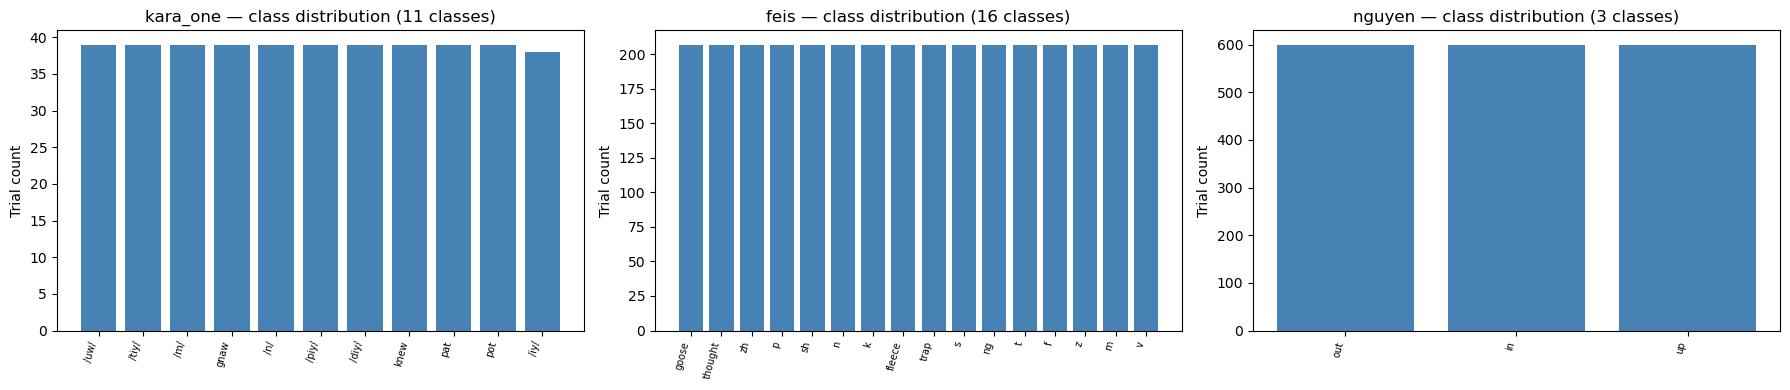

In [20]:
# =============================================================================
# SECTION 3.7 — RUN EXTRACTION AND LOADING (final, corrected loaders)
# =============================================================================

extracted_paths = extract_all_datasets(CONFIG)

all_loaded: Dict[str, Dict[str, Dict[str, Any]]] = {"kara_one": {}, "feis": {}, "nguyen": {}}

if "kara_one" in extracted_paths:
    if verify_dataset(extracted_paths["kara_one"], (".cnt", ".set", ".mat")):
        try:
            all_loaded["kara_one"] = load_kara_one(extracted_paths["kara_one"])
        except RuntimeError as e:
            logger.error(str(e))

if "feis" in extracted_paths:
    if verify_dataset(extracted_paths["feis"], (".zip", ".csv")):
        try:
            all_loaded["feis"] = load_feis(extracted_paths["feis"])
        except RuntimeError as e:
            logger.error(str(e))

if "nguyen" in extracted_paths:
    if verify_dataset(extracted_paths["nguyen"], (".mat", ".csv", ".npy")):
        try:
            all_loaded["nguyen"] = load_nguyen(extracted_paths["nguyen"])
        except RuntimeError as e:
            logger.error(str(e))

dataset_summary_df = build_full_dataset_summary(all_loaded)
plot_class_distribution(all_loaded)

In [21]:
# =============================================================================
# SECTION 3.8 — SANITY CHECK
# =============================================================================

def test_section3() -> None:
    at_least_one_loaded = any(bool(d) for d in all_loaded.values())
    assert at_least_one_loaded, "No datasets were loaded at all."

    for name, data in all_loaded.items():
        if not data:
            logger.warning(f"[test_section3] '{name}' loaded 0 subjects.")
            continue
        for subj, d in data.items():
            assert d.get("trials"), f"[{name}/{subj}] has no trials."
            assert d.get("labels"), f"[{name}/{subj}] has no labels."
            assert len(d["trials"]) == len(d["labels"]), \
                f"[{name}/{subj}] trial/label count mismatch."
            assert d["trials"][0].ndim == 2, \
                f"[{name}/{subj}] trial arrays should be 2D (channels, time)."

    assert not dataset_summary_df.empty
    assert (OUTPUT_DIRS["metrics"] / "dataset_summary.csv").exists()
    assert (OUTPUT_DIRS["figures"] / "class_distribution.png").exists()

    total_subjects = sum(len(v) for v in all_loaded.values())
    total_trials = sum(len(d.get("trials", [])) for data in all_loaded.values() for d in data.values())

    print("All Section 3 checks passed.")
    print(f"  Datasets loaded : {[k for k, v in all_loaded.items() if v]}")
    print(f"  Total subjects  : {total_subjects}")
    print(f"  Total trials    : {total_trials}")

test_section3()

All Section 3 checks passed.
  Datasets loaded : ['kara_one', 'feis', 'nguyen']
  Total subjects  : 30
  Total trials    : 5540


In [22]:
# =============================================================================
# SECTION 4.1 — CANONICAL CHANNEL SET (data-driven, built from what actually loaded)
# =============================================================================

NON_EEG_CHANNELS = {
    "EKG",      # cardiac
    "EMG",      # muscle
    "M1", "M2", # mastoid references
    "HEO", "VEO",  # horizontal / vertical EOG (eye movement)
    "TRIGGER",  # event marker, not a signal
}

def is_eeg_channel(name: str) -> bool:
    """True if `name` is a genuine scalp EEG channel (not EKG/EMG/mastoid/
    EOG/trigger). Comparison is done on the normalized (uppercased) name."""
    return normalize_channel_name(name) not in NON_EEG_CHANNELS

def normalize_channel_name(name: str) -> str:
    """Normalize an electrode name for cross-dataset matching:
    uppercase, strip whitespace, remove common non-alphanumeric separators.
    e.g. ' Fp1 ' -> 'FP1', 'T7-REF' -> 'T7REF' (rare edge case, harmless since
    exact matches still resolve correctly for clean names).
    """
    return "".join(ch for ch in name.strip().upper() if ch.isalnum())


def build_canonical_channel_set(all_loaded: Dict[str, Dict[str, Dict[str, Any]]]
                                 ) -> Dict[str, Any]:
    """Build the canonical channel layout from whatever actually loaded,
    excluding known non-EEG channels (EKG, EMG, mastoid refs, EOG, trigger)."""
    named_channel_set = set()
    named_display = {}
    generic_max_size = 0
    dataset_channel_map = {}
    named_datasets, generic_datasets = [], []
    excluded_report = {}  # dataset -> list of excluded channel names, for the printout

    for dataset_name, subjects in all_loaded.items():
        if not subjects:
            continue
        dataset_channel_map[dataset_name] = {}
        sample_subj, sample_d = next(iter(subjects.items()))
        chans = sample_d.get("channel_names", [])
        dataset_channel_map[dataset_name][sample_subj] = chans

        is_generic = all(c.lower().startswith("ch_") for c in chans) if chans else True

        if is_generic:
            generic_datasets.append(dataset_name)
            generic_max_size = max(generic_max_size, len(chans))
            logger.warning(f"[Harmonization] '{dataset_name}' has NO real electrode names "
                            f"({len(chans)} generic channels) — reserved as its own block.")
        else:
            named_datasets.append(dataset_name)
            excluded_here = []
            for c in chans:
                if not is_eeg_channel(c):
                    excluded_here.append(c)
                    continue
                norm = normalize_channel_name(c)
                named_channel_set.add(norm)
                named_display.setdefault(norm, c)
            if excluded_here:
                excluded_report[dataset_name] = excluded_here

    named_channels_sorted = sorted(named_channel_set)
    total_size = len(named_channels_sorted) + generic_max_size

    result = {
        "named_channels": named_channels_sorted,
        "named_channel_display": [named_display[n] for n in named_channels_sorted],
        "generic_channel_slots": generic_max_size,
        "total_canonical_size": total_size,
        "dataset_channel_map": dataset_channel_map,
        "datasets_with_named_channels": named_datasets,
        "datasets_with_generic_channels": generic_datasets,
        "excluded_non_eeg_channels": excluded_report,
    }

    print("=" * 80)
    print("CANONICAL CHANNEL LAYOUT")
    print("=" * 80)
    print(f"Named EEG channels (from {named_datasets}): {len(named_channels_sorted)}")
    print(f"  {result['named_channel_display']}")
    if excluded_report:
        print(f"\nExcluded non-EEG channels (not part of canonical space):")
        for ds, chans in excluded_report.items():
            print(f"  {ds}: {chans}")
    print(f"\nGeneric channel slots (from {generic_datasets}): {generic_max_size}")
    print(f"Total canonical size: {total_size}")
    print("=" * 80)

    return result

canonical_layout = build_canonical_channel_set(all_loaded)

# overwrite the Section 2 placeholders now that we know the real number
CONFIG["channels"]["canonical_set_size"] = canonical_layout["total_canonical_size"]
CONFIG["cnn"]["in_channels"] = canonical_layout["total_canonical_size"]
logger.info(f"CONFIG['channels']['canonical_set_size'] and CONFIG['cnn']['in_channels'] "
            f"updated to {canonical_layout['total_canonical_size']}")

2026-09-08 08:48:50 | WARNING  | bci_project | [Harmonization] 'nguyen' has NO real electrode names (60 generic channels) — reserved as its own block.
CANONICAL CHANNEL LAYOUT
Named EEG channels (from ['kara_one', 'feis']): 62
  ['AF3', 'AF4', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CB1', 'CB2', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CPZ', 'CZ', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FCZ', 'FP1', 'FP2', 'FPZ', 'FT7', 'FT8', 'FZ', 'O1', 'O2', 'OZ', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO4', 'PO5', 'PO6', 'PO7', 'PO8', 'POZ', 'PZ', 'T7', 'T8', 'TP7', 'TP8']

Excluded non-EEG channels (not part of canonical space):
  kara_one: ['M1', 'M2', 'VEO', 'HEO', 'EKG', 'EMG', 'Trigger']

Generic channel slots (from ['nguyen']): 60
Total canonical size: 122
2026-09-08 08:48:50 | INFO     | bci_project | CONFIG['channels']['canonical_set_size'] and CONFIG['cnn']['in_channels'] updated to 122


In [23]:
# =============================================================================
# SECTION 4.2 — MAP / REORDER / PAD / MASK
# =============================================================================

def map_channels(dataset_name: str, subject_channel_names: List[str],
                  canonical_layout: Dict[str, Any]) -> Dict[str, Optional[int]]:
    """Build a mapping: subject's original channel index -> canonical index.

    - Named datasets (Kara One, FEIS): matched by normalized electrode name
      into the shared 'named_channels' block.
    - Generic datasets (Nguyen): matched by position into the reserved
      'generic_channel_slots' block, offset after the named block.
    - Channels with no canonical slot (shouldn't normally happen, but handled
      defensively) map to None and are dropped.

    Returns
    -------
    Dict mapping original channel index (int) -> canonical index (int) or None.
    """
    named_channels = canonical_layout["named_channels"]
    n_named = len(named_channels)
    is_generic = dataset_name in canonical_layout["datasets_with_generic_channels"]

    mapping: Dict[int, Optional[int]] = {}

    if is_generic:
        for i, _ in enumerate(subject_channel_names):
            mapping[i] = n_named + i if i < canonical_layout["generic_channel_slots"] else None
    else:
        name_to_canon_idx = {name: idx for idx, name in enumerate(named_channels)}
        for i, ch_name in enumerate(subject_channel_names):
            norm = normalize_channel_name(ch_name)
            mapping[i] = name_to_canon_idx.get(norm)  # None if not found (shouldn't happen)

    return mapping


def reorder_channels(trial: np.ndarray, mapping: Dict[int, Optional[int]]) -> np.ndarray:
    """Select and reorder the channels of `trial` (channels, time) that have a
    valid canonical mapping, dropping any that don't. Order follows canonical
    index ascending. Used internally by zero_pad_missing_channels — most
    callers should use that function directly instead.
    """
    valid = sorted([(orig, canon) for orig, canon in mapping.items() if canon is not None],
                   key=lambda x: x[1])
    if not valid:
        return np.zeros((0, trial.shape[1]), dtype=trial.dtype)
    orig_indices = [orig for orig, _ in valid]
    return trial[orig_indices, :]


def zero_pad_missing_channels(trial: np.ndarray, mapping: Dict[int, Optional[int]],
                               canonical_size: int) -> np.ndarray:
    """Place `trial`'s channels into a (canonical_size, time) array at their
    mapped canonical positions, zero-filling every canonical channel this
    subject/dataset doesn't have.
    """
    n_time = trial.shape[1]
    out = np.zeros((canonical_size, n_time), dtype=trial.dtype)
    for orig_idx, canon_idx in mapping.items():
        if canon_idx is not None and orig_idx < trial.shape[0]:
            out[canon_idx, :] = trial[orig_idx, :]
    return out


def create_channel_mask(mapping: Dict[int, Optional[int]], canonical_size: int) -> np.ndarray:
    """Binary mask over the canonical channel axis: 1 where this
    subject/dataset has a real (non-zero-padded) channel, 0 where it's padding.
    Shape: (canonical_size,)
    """
    mask = np.zeros(canonical_size, dtype=np.float32)
    for orig_idx, canon_idx in mapping.items():
        if canon_idx is not None:
            mask[canon_idx] = 1.0
    return mask

In [24]:
# =============================================================================
# SECTION 4.3 — APPLY HARMONIZATION
# =============================================================================

def harmonize_all_datasets(all_loaded: Dict[str, Dict[str, Dict[str, Any]]],
                            canonical_layout: Dict[str, Any]
                            ) -> Dict[str, Dict[str, Dict[str, Any]]]:
    """Zero-pad + mask every trial in every subject in every dataset into the
    shared canonical channel space.

    Returns
    -------
    Same nested structure as all_loaded, but each subject dict additionally has:
        "harmonized_trials": List[np.ndarray]  # each (canonical_size, time)
        "channel_mask": np.ndarray             # (canonical_size,) — same for
                                                # every trial of this subject
                                                # (channel availability doesn't
                                                # vary trial-to-trial)
    """
    canonical_size = canonical_layout["total_canonical_size"]
    harmonized = {}

    for dataset_name, subjects in all_loaded.items():
        if not subjects:
            harmonized[dataset_name] = {}
            continue
        harmonized[dataset_name] = {}

        for subj, d in tqdm(subjects.items(), desc=f"Harmonizing {dataset_name}", unit="subject"):
            mapping = map_channels(dataset_name, d["channel_names"], canonical_layout)
            mask = create_channel_mask(mapping, canonical_size)

            harmonized_trials = [
                zero_pad_missing_channels(trial, mapping, canonical_size)
                for trial in d["trials"]
            ]

            harmonized[dataset_name][subj] = {
                **d,  # keep all original fields (labels, sfreq, etc.)
                "harmonized_trials": harmonized_trials,
                "channel_mask": mask,
            }

        n_active = int(sum(create_channel_mask(
            map_channels(dataset_name, next(iter(subjects.values()))["channel_names"], canonical_layout),
            canonical_size)))
        logger.info(f"[Harmonization] '{dataset_name}': {n_active}/{canonical_size} "
                    f"canonical channels active per subject.")

    return harmonized


harmonized_data = harmonize_all_datasets(all_loaded, canonical_layout)

Harmonizing kara_one: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  5.41subject/s]

2026-09-08 08:48:51 | INFO     | bci_project | [Harmonization] 'kara_one': 62/122 canonical channels active per subject.



Harmonizing feis: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 47.11subject/s]

2026-09-08 08:48:51 | INFO     | bci_project | [Harmonization] 'feis': 14/122 canonical channels active per subject.



Harmonizing nguyen: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00,  8.68subject/s]

2026-09-08 08:48:52 | INFO     | bci_project | [Harmonization] 'nguyen': 60/122 canonical channels active per subject.


2026-09-08 08:48:52 | INFO     | bci_project | Channel coverage figure saved to /home/23adr054/outputs/figures/channel_coverage.png


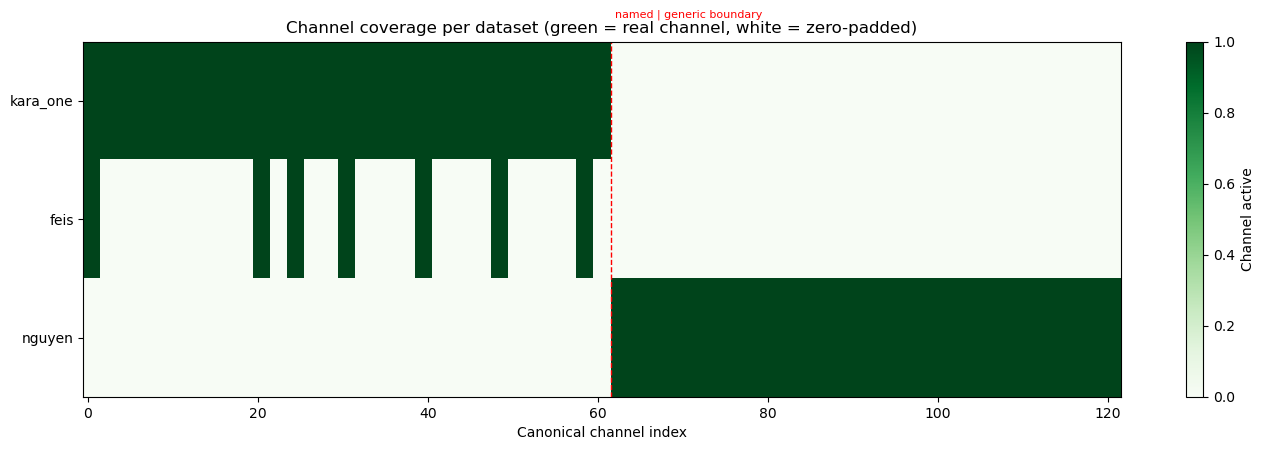

In [25]:
# =============================================================================
# SECTION 4.4 — CHANNEL COVERAGE VISUALIZATION
# =============================================================================

def plot_channel_coverage(harmonized_data: Dict[str, Dict[str, Dict[str, Any]]],
                           canonical_layout: Dict[str, Any], save: bool = True) -> None:
    """Heatmap: rows = datasets, columns = canonical channel index, showing
    which canonical channels each dataset actually populates (1) vs zero-pads (0).
    """
    canonical_size = canonical_layout["total_canonical_size"]
    active_datasets = [name for name, subjs in harmonized_data.items() if subjs]

    coverage = np.zeros((len(active_datasets), canonical_size))
    for i, name in enumerate(active_datasets):
        sample_subj = next(iter(harmonized_data[name].values()))
        coverage[i] = sample_subj["channel_mask"]

    fig, ax = plt.subplots(figsize=(14, 1.2 * len(active_datasets) + 1))
    im = ax.imshow(coverage, aspect="auto", cmap="Greens", vmin=0, vmax=1)
    ax.set_yticks(range(len(active_datasets)))
    ax.set_yticklabels(active_datasets)
    ax.set_xlabel("Canonical channel index")
    ax.set_title("Channel coverage per dataset (green = real channel, white = zero-padded)")

    n_named = len(canonical_layout["named_channels"])
    if canonical_layout["generic_channel_slots"] > 0:
        ax.axvline(n_named - 0.5, color="red", linestyle="--", linewidth=1)
        ax.text(n_named, -0.7, "named | generic boundary", color="red", fontsize=8)

    plt.colorbar(im, ax=ax, label="Channel active")
    plt.tight_layout()

    if save:
        out_path = OUTPUT_DIRS["figures"] / "channel_coverage.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        logger.info(f"Channel coverage figure saved to {out_path.resolve()}")
    plt.show()


plot_channel_coverage(harmonized_data, canonical_layout)

In [26]:
# =============================================================================
# SECTION 4.5 — SANITY CHECK
# =============================================================================

def test_section4() -> None:
    canonical_size = canonical_layout["total_canonical_size"]
    assert canonical_size > 0, "Canonical channel size is zero — harmonization failed."

    for dataset_name, subjects in harmonized_data.items():
        if not subjects:
            continue
        for subj, d in subjects.items():
            assert "harmonized_trials" in d, f"[{dataset_name}/{subj}] missing harmonized_trials"
            assert "channel_mask" in d, f"[{dataset_name}/{subj}] missing channel_mask"
            assert d["channel_mask"].shape == (canonical_size,), \
                f"[{dataset_name}/{subj}] mask shape mismatch"

            for trial in d["harmonized_trials"][:3]:  # spot-check first few trials
                assert trial.shape[0] == canonical_size, \
                    f"[{dataset_name}/{subj}] trial channel dim mismatch: {trial.shape[0]} != {canonical_size}"

            # every dataset should have at least SOME active (non-zero) channels
            n_active = int(d["channel_mask"].sum())
            assert n_active > 0, f"[{dataset_name}/{subj}] has zero active channels — mapping broken"

    assert (OUTPUT_DIRS["figures"] / "channel_coverage.png").exists()

    print("All Section 4 checks passed.")
    print(f"  Canonical channel size : {canonical_size}")
    print(f"    Named channels       : {len(canonical_layout['named_channels'])} "
          f"(from {canonical_layout['datasets_with_named_channels']})")
    print(f"    Generic channel slots: {canonical_layout['generic_channel_slots']} "
          f"(from {canonical_layout['datasets_with_generic_channels']})")

test_section4()

All Section 4 checks passed.
  Canonical channel size : 122
    Named channels       : 62 (from ['kara_one', 'feis'])
    Generic channel slots: 60 (from ['nguyen'])


In [27]:
print(f"Total named channels: {len(canonical_layout['named_channel_display'])}")
print(canonical_layout['named_channel_display'])

Total named channels: 62
['AF3', 'AF4', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CB1', 'CB2', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CPZ', 'CZ', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FCZ', 'FP1', 'FP2', 'FPZ', 'FT7', 'FT8', 'FZ', 'O1', 'O2', 'OZ', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO4', 'PO5', 'PO6', 'PO7', 'PO8', 'POZ', 'PZ', 'T7', 'T8', 'TP7', 'TP8']


In [28]:
# =============================================================================
# SECTION 5.1 — MNE INFO BUILDER & FILTERING
# =============================================================================

def build_mne_info(channel_names: List[str], sfreq: float) -> mne.Info:
    """Build an MNE Info object treating every channel as EEG. Real montages
    (electrode 3D positions) aren't attached here — Section 15's topomaps
    handle montage lookup separately, since only named channels have real
    positions.
    """
    return mne.create_info(ch_names=list(channel_names), sfreq=sfreq, ch_types="eeg")


def bandpass_notch_filter(trial: np.ndarray, sfreq: float,
                           l_freq: float = CONFIG["signal"]["bandpass_low"],
                           h_freq: float = CONFIG["signal"]["bandpass_high"],
                           notch_freqs: List[float] = CONFIG["signal"]["notch_freqs"]
                           ) -> np.ndarray:
    """Bandpass + notch filter a single trial (channels, time).

    Uses IIR filtering rather than MNE's default long FIR kernel, since trials
    here are short (1.3-5s) and a long FIR filter would produce heavy edge
    artifacts relative to the trial length.
    """
    data = trial.astype(np.float64)

    # guard against filtering above Nyquist (shouldn't happen given CONFIG,
    # but defensive for any future sfreq changes)
    nyquist = sfreq / 2.0
    h_freq_safe = min(h_freq, nyquist - 1.0)

    filtered = mne.filter.filter_data(
        data, sfreq=sfreq, l_freq=l_freq, h_freq=h_freq_safe,
        method="iir", iir_params=dict(order=4, ftype="butter"),
        verbose=False
    )

    for nf in notch_freqs:
        if nf < nyquist:
            filtered = mne.filter.notch_filter(
                filtered, Fs=sfreq, freqs=[nf],
                method="iir", iir_params=dict(order=4, ftype="butter"),
                verbose=False
            )

    return filtered.astype(np.float32)

In [29]:
# =============================================================================
# SECTION 5.2 — COMMON AVERAGE REFERENCE & ARTIFACT REJECTION
# =============================================================================

def apply_car(trial: np.ndarray) -> np.ndarray:
    """Common Average Reference: subtract the across-channel mean at every
    timepoint. Operates on real (non-padded) channels only.
    """
    return trial - trial.mean(axis=0, keepdims=True)


def compute_trial_outlier_mask(trials: List[np.ndarray], k: float = 4.0) -> np.ndarray:
    """Flag trials as artifact-contaminated using a robust (median/MAD-based)
    outlier rule on peak-to-peak amplitude, rather than a fixed microvolt
    threshold.

    A fixed µV cutoff isn't safe here: Kara One's raw .cnt is in true µV,
    Nguyen's data has already been filtered/scaled by its original authors,
    and FEIS's Emotiv export may be in raw ADC-like units — three different
    amplitude scales. A per-subject relative outlier rule works across all
    three without assuming a shared physical unit.

    Returns
    -------
    Boolean array (n_trials,) — True = keep, False = reject as outlier.
    """
    if len(trials) < 5:
        # too few trials for robust statistics — keep everything, log it
        logger.warning(f"Only {len(trials)} trials — skipping statistical "
                        f"artifact rejection (insufficient sample size).")
        return np.ones(len(trials), dtype=bool)

    ptp = np.array([np.ptp(t) for t in trials])  # peak-to-peak per trial
    median = np.median(ptp)
    mad = np.median(np.abs(ptp - median)) + 1e-8  # avoid div-by-zero
    modified_z = 0.6745 * (ptp - median) / mad

    keep_mask = np.abs(modified_z) < k
    n_rejected = int((~keep_mask).sum())
    if n_rejected > 0:
        logger.info(f"Artifact rejection: {n_rejected}/{len(trials)} trials "
                    f"flagged as outliers (|modified z| >= {k}) and dropped.")
    return keep_mask

In [30]:
# =============================================================================
# SECTION 5.3 — ICA-BASED ARTIFACT REMOVAL
# =============================================================================

FRONTAL_PROXY_CHANNELS = ["FP1", "FP2", "FPZ", "AF3", "AF4"]  # EOG proxy candidates

def run_ica_denoising(trials: List[np.ndarray], sfreq: float, ch_names: List[str],
                       n_components_frac: float = CONFIG["signal"]["ica_n_components"],
                       random_state: int = GLOBAL_SEED
                       ) -> Tuple[List[np.ndarray], Dict[str, Any]]:
    """Run FastICA on a subject's trials (concatenated into one pseudo-continuous
    signal, since these datasets provide no continuous recording outside Kara
    One), identify likely eye-artifact components, remove them, and return
    cleaned trials split back to their original boundaries.

    Component identification:
      - If any of FRONTAL_PROXY_CHANNELS are present in ch_names, components
        whose scalp-mixing weight is dominated by those channels (relative to
        posterior channels) are flagged as eye-artifact-like.
      - Otherwise (no named frontal channels, e.g. Nguyen), falls back to a
        kurtosis heuristic: the single component with the highest kurtosis
        (eye blinks are strongly non-Gaussian / high-kurtosis) is removed.
        This is a coarser, documented approximation — not equivalent to a
        montage-informed method.

    Returns
    -------
    (cleaned_trials, report) where report logs which components were removed
    and by which method, for transparency in the notebook's audit trail.
    """
    n_channels = trials[0].shape[0]
    if n_channels < 3 or len(trials) < 3:
        logger.warning(f"Too few channels ({n_channels}) or trials ({len(trials)}) "
                        f"for ICA — skipping, returning trials unchanged.")
        return trials, {"skipped": True, "reason": "insufficient channels/trials"}

    # concatenate trials into one pseudo-continuous array, tracking boundaries
    boundaries = np.cumsum([0] + [t.shape[1] for t in trials])
    concat = np.concatenate(trials, axis=1).astype(np.float64)

    info = build_mne_info(ch_names, sfreq)
    raw = mne.io.RawArray(concat, info, verbose=False)

    n_components = max(1, min(int(n_channels * 1.0), n_channels - 1))
    try:
        ica = mne.preprocessing.ICA(
            n_components=min(n_components, 20),  # cap for speed/stability
            method="fastica", random_state=random_state, max_iter="auto"
        )
        ica.fit(raw, verbose=False)
    except Exception as e:
        logger.warning(f"ICA fit failed ({e}) — returning trials unchanged.")
        return trials, {"skipped": True, "reason": str(e)}

    frontal_present = [c for c in FRONTAL_PROXY_CHANNELS if c in ch_names]
    excluded_components = []
    method_used = None

    if frontal_present:
        method_used = "frontal_proxy_correlation"
        mixing = ica.get_components()  # (n_channels, n_components)
        ch_idx = {c: i for i, c in enumerate(ch_names)}
        frontal_idx = [ch_idx[c] for c in frontal_present]
        posterior_candidates = [c for c in ["O1", "O2", "OZ", "PO3", "PO4", "P3", "P4"]
                                 if c in ch_names]
        posterior_idx = [ch_idx[c] for c in posterior_candidates] if posterior_candidates else \
                         [i for i in range(len(ch_names)) if i not in frontal_idx]

        for comp_idx in range(mixing.shape[1]):
            weights = np.abs(mixing[:, comp_idx])
            frontal_energy = weights[frontal_idx].mean()
            posterior_energy = weights[posterior_idx].mean() + 1e-8
            if frontal_energy / posterior_energy > 2.0:  # frontally-dominant component
                excluded_components.append(comp_idx)

        # cap removal to at most 2 components — avoid gutting real signal
        excluded_components = excluded_components[:2]

    else:
        method_used = "kurtosis_fallback_no_spatial_reference"
        sources = ica.get_sources(raw).get_data()  # (n_components, time)
        kurt = scipy.stats.kurtosis(sources, axis=1)
        top_component = int(np.argmax(kurt))
        excluded_components = [top_component]
        logger.info(f"No frontal proxy channels available — using kurtosis "
                    f"fallback, removing component {top_component} "
                    f"(kurtosis={kurt[top_component]:.2f}).")

    ica.exclude = excluded_components
    cleaned_raw = ica.apply(raw.copy(), verbose=False)
    cleaned_concat = cleaned_raw.get_data()

    cleaned_trials = [
        cleaned_concat[:, boundaries[i]:boundaries[i + 1]]
        for i in range(len(trials))
    ]

    report = {
        "skipped": False,
        "method": method_used,
        "n_components_fit": ica.n_components_,
        "excluded_components": excluded_components,
    }
    return cleaned_trials, report

In [31]:
# =============================================================================
# SECTION 5.4 — RESAMPLING, EPOCH STANDARDIZATION, NORMALIZATION
# =============================================================================

TARGET_SFREQ = CONFIG["signal"]["target_sfreq"]       # 256 Hz
TARGET_EPOCH_SECONDS = 5.0                             # matches FEIS/Nguyen's native window
TARGET_EPOCH_SAMPLES = int(TARGET_SFREQ * TARGET_EPOCH_SECONDS)  # 1280 samples

def resample_trial(trial: np.ndarray, orig_sfreq: float, target_sfreq: float = TARGET_SFREQ
                    ) -> np.ndarray:
    """Resample a trial (channels, time) from orig_sfreq to target_sfreq.
    No-op if already at target rate (FEIS, Nguyen).
    """
    if abs(orig_sfreq - target_sfreq) < 1e-6:
        return trial
    return mne.filter.resample(trial.astype(np.float64), up=target_sfreq,
                                down=orig_sfreq, npad="auto", verbose=False).astype(np.float32)


def standardize_epoch_length(trial: np.ndarray, target_length: int = TARGET_EPOCH_SAMPLES
                              ) -> np.ndarray:
    """Crop (center crop) or zero-pad (centered) a trial's time axis to
    exactly `target_length` samples.
    """
    n_channels, n_time = trial.shape
    if n_time == target_length:
        return trial
    if n_time > target_length:
        start = (n_time - target_length) // 2
        return trial[:, start:start + target_length]
    # pad
    pad_total = target_length - n_time
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left
    return np.pad(trial, ((0, 0), (pad_left, pad_right)), mode="constant")


def zscore_normalize(trial: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    """Per-channel z-score normalization across the time axis. Channels with
    ~zero variance (shouldn't occur in real, non-padded data, but guarded
    defensively) are left unscaled rather than divided by ~0.
    """
    mean = trial.mean(axis=1, keepdims=True)
    std = trial.std(axis=1, keepdims=True)
    std_safe = np.where(std < eps, 1.0, std)
    return (trial - mean) / std_safe

In [32]:
# =============================================================================
# SECTION 5.5 — FULL PREPROCESSING PIPELINE (per subject)
# =============================================================================

def preprocess_subject(trials: List[np.ndarray], labels: List[str],
                        ch_names: List[str], sfreq: float,
                        run_ica: bool = True) -> Dict[str, Any]:
    """Run the complete preprocessing pipeline on one subject's trials:
    filter -> ICA denoise -> CAR -> resample -> standardize length ->
    statistical artifact rejection -> z-score normalize.

    Returns
    -------
    {
      "trials": List[np.ndarray],   # cleaned, (n_channels, TARGET_EPOCH_SAMPLES) each
      "labels": List[str],          # aligned with trials, after artifact-rejected drops
      "n_rejected": int,
      "ica_report": dict,
    }
    """
    # 1. Filter
    filtered = [bandpass_notch_filter(t, sfreq) for t in trials]

    # 2. ICA denoise
    if run_ica:
        denoised, ica_report = run_ica_denoising(filtered, sfreq, ch_names)
    else:
        denoised, ica_report = filtered, {"skipped": True, "reason": "run_ica=False"}

    # 3. CAR
    if CONFIG["signal"]["car_reference"]:
        rereferenced = [apply_car(t) for t in denoised]
    else:
        rereferenced = denoised

    # 4. Resample to common rate
    resampled = [resample_trial(t, sfreq) for t in rereferenced]

    # 5. Standardize epoch length
    standardized = [standardize_epoch_length(t) for t in resampled]

    # 6. Statistical artifact rejection
    keep_mask = compute_trial_outlier_mask(standardized)
    kept_trials = [t for t, keep in zip(standardized, keep_mask) if keep]
    kept_labels = [l for l, keep in zip(labels, keep_mask) if keep]

    # 7. Z-score normalize
    normalized = [zscore_normalize(t) for t in kept_trials]

    return {
        "trials": normalized,
        "labels": kept_labels,
        "n_rejected": int((~keep_mask).sum()),
        "ica_report": ica_report,
    }

In [33]:
# =============================================================================
# SECTION 5.6 — RUN PREPROCESSING + RE-HARMONIZE INTO CANONICAL SPACE
# =============================================================================

def preprocess_and_harmonize_all(all_loaded: Dict[str, Dict[str, Dict[str, Any]]],
                                  canonical_layout: Dict[str, Any]
                                  ) -> Dict[str, Dict[str, Dict[str, Any]]]:
    """Preprocess every subject in native channel space, then re-harmonize
    into the canonical 122-channel layout using Section 4's mapping utilities.
    """
    canonical_size = canonical_layout["total_canonical_size"]
    result: Dict[str, Dict[str, Dict[str, Any]]] = {}

    for dataset_name, subjects in all_loaded.items():
        result[dataset_name] = {}
        if not subjects:
            continue

        for subj, d in tqdm(subjects.items(), desc=f"Preprocessing {dataset_name}", unit="subject"):
            proc = preprocess_subject(
                trials=d["trials"], labels=d["labels"],
                ch_names=d["channel_names"], sfreq=d["sfreq"],
                run_ica=True,
            )

            mapping = map_channels(dataset_name, d["channel_names"], canonical_layout)
            mask = create_channel_mask(mapping, canonical_size)
            harmonized_trials = [
                zero_pad_missing_channels(t, mapping, canonical_size) for t in proc["trials"]
            ]

            result[dataset_name][subj] = {
                **d,
                "harmonized_trials": harmonized_trials,
                "labels": proc["labels"],
                "channel_mask": mask,
                "n_rejected_trials": proc["n_rejected"],
                "ica_report": proc["ica_report"],
                "sfreq_after_preprocessing": TARGET_SFREQ,
            }

            logger.info(f"[Preprocess] {dataset_name}/{subj}: "
                        f"{len(harmonized_trials)} clean trials "
                        f"({proc['n_rejected']} rejected), "
                        f"ICA method={proc['ica_report'].get('method', 'skipped')}")

    return result


preprocessed_harmonized_data = preprocess_and_harmonize_all(all_loaded, canonical_layout)

Preprocessing kara_one:   0%|                                                                                                     | 0/3 [00:00<?, ?subject/s]/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)


2026-09-08 08:49:21 | INFO     | bci_project | Artifact rejection: 2/165 trials flagged as outliers (|modified z| >= 4.0) and dropped.
2026-09-08 08:49:21 | INFO     | bci_project | [Preprocess] kara_one/MM05: 163 clean trials (2 rejected), ICA method=frontal_proxy_correlation


Preprocessing kara_one:  33%|███████████████████████████████                                                              | 1/3 [00:28<00:56, 28.19s/subject]/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)
/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (66) and smallest (5.8e-05) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 19
  ica.fit(raw, verbose=False)


2026-09-08 08:49:35 | INFO     | bci_project | Artifact rejection: 25/131 trials flagged as outliers (|modified z| >= 4.0) and dropped.
2026-09-08 08:49:36 | INFO     | bci_project | [Preprocess] kara_one/MM08: 106 clean trials (25 rejected), ICA method=frontal_proxy_correlation


Preprocessing kara_one:  67%|██████████████████████████████████████████████████████████████                               | 2/3 [00:43<00:20, 20.33s/subject]/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)
/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (68) and smallest (2.9e-05) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 13
  ica.fit(raw, verbose=False)


...

Preprocessing nguyen:  67%|███████████████████████████████████████████████████████████████▎                               | 4/6 [01:10<00:35, 17.78s/subject]/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)


2026-09-08 08:52:20 | INFO     | bci_project | No frontal proxy channels available — using kurtosis fallback, removing component 1 (kurtosis=29730.07).
2026-09-08 08:52:20 | INFO     | bci_project | Artifact rejection: 11/300 trials flagged as outliers (|modified z| >= 4.0) and dropped.
2026-09-08 08:52:21 | INFO     | bci_project | [Preprocess] nguyen/sub-05: 289 clean trials (11 rejected), ICA method=kurtosis_fallback_no_spatial_reference


Preprocessing nguyen:  83%|███████████████████████████████████████████████████████████████████████████████▏               | 5/6 [01:27<00:17, 17.54s/subject]/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)


2026-09-08 08:52:37 | INFO     | bci_project | No frontal proxy channels available — using kurtosis fallback, removing component 3 (kurtosis=61.50).
2026-09-08 08:52:38 | INFO     | bci_project | Artifact rejection: 2/300 trials flagged as outliers (|modified z| >= 4.0) and dropped.
2026-09-08 08:52:38 | INFO     | bci_project | [Preprocess] nguyen/sub-06: 298 clean trials (2 rejected), ICA method=kurtosis_fallback_no_spatial_reference


Preprocessing nguyen: 100%|███████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:45<00:00, 17.53s/subject]


/tmp/ipykernel_3088812/948864981.py:50: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)


2026-09-08 08:52:40 | INFO     | bci_project | Preprocessing stages figure saved to /home/23adr054/outputs/figures/preprocessing_stages_kara_one_MM05.png


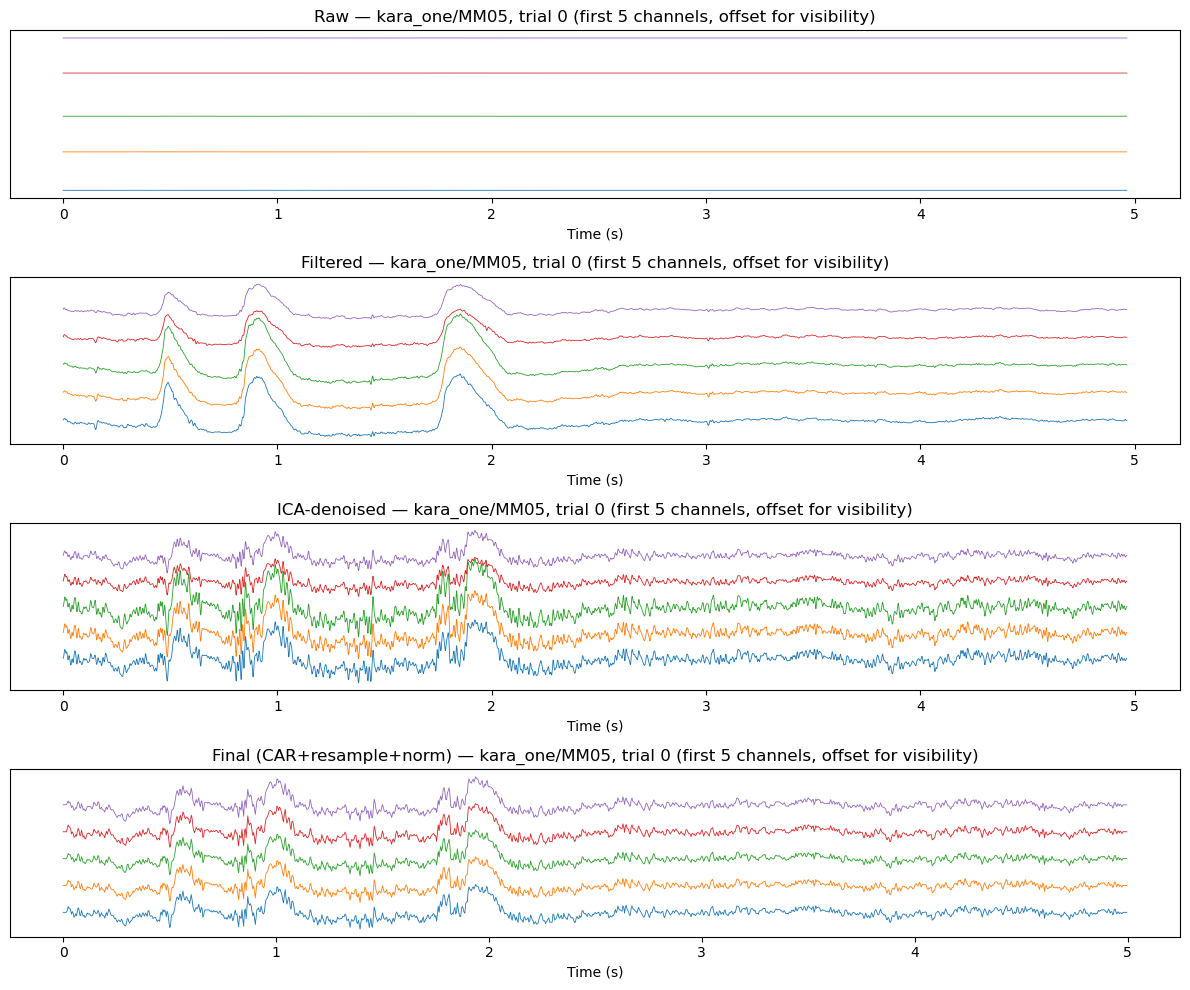

In [34]:
# =============================================================================
# SECTION 5.7 — VISUALIZE PREPROCESSING STAGES (one example trial)
# =============================================================================

def plot_preprocessing_stages(dataset_name: str = "kara_one", subject: Optional[str] = None,
                               trial_idx: int = 0, save: bool = True) -> None:
    """Show raw -> filtered -> ICA-denoised -> fully-cleaned versions of one
    example trial, for a visual sanity check of the pipeline.
    """
    if dataset_name not in all_loaded or not all_loaded[dataset_name]:
        logger.warning(f"'{dataset_name}' not available for visualization.")
        return
    subject = subject or next(iter(all_loaded[dataset_name].keys()))
    d = all_loaded[dataset_name][subject]

    raw_trial = d["trials"][trial_idx]
    filtered_trial = bandpass_notch_filter(raw_trial, d["sfreq"])
    denoised_trials, _ = run_ica_denoising([filtered_trial] * 3, d["sfreq"], d["channel_names"])
    denoised_trial = denoised_trials[0]
    car_trial = apply_car(denoised_trial) if CONFIG["signal"]["car_reference"] else denoised_trial
    final_trial = zscore_normalize(standardize_epoch_length(resample_trial(car_trial, d["sfreq"])))

    stages = [("Raw", raw_trial), ("Filtered", filtered_trial),
              ("ICA-denoised", denoised_trial), ("Final (CAR+resample+norm)", final_trial)]

    n_show_channels = min(5, raw_trial.shape[0])
    fig, axes = plt.subplots(len(stages), 1, figsize=(12, 10), sharex=False)
    for ax, (title, data) in zip(axes, stages):
        t = np.arange(data.shape[1]) / (TARGET_SFREQ if "Final" in title else d["sfreq"])
        for ch in range(n_show_channels):
            ax.plot(t, data[ch] + ch * (np.std(data) * 4 if np.std(data) > 0 else 1),
                    linewidth=0.6)
        ax.set_title(f"{title} — {dataset_name}/{subject}, trial {trial_idx} "
                     f"(first {n_show_channels} channels, offset for visibility)")
        ax.set_xlabel("Time (s)")
        ax.set_yticks([])

    plt.tight_layout()
    if save:
        out_path = OUTPUT_DIRS["figures"] / f"preprocessing_stages_{dataset_name}_{subject}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
        logger.info(f"Preprocessing stages figure saved to {out_path.resolve()}")
    plt.show()


plot_preprocessing_stages("kara_one")

In [35]:
# =============================================================================
# SECTION 5.8 — SANITY CHECK
# =============================================================================

def test_section5() -> None:
    canonical_size = canonical_layout["total_canonical_size"]

    for dataset_name, subjects in preprocessed_harmonized_data.items():
        if not subjects:
            continue
        for subj, d in subjects.items():
            assert d["harmonized_trials"], f"[{dataset_name}/{subj}] no trials after preprocessing."
            assert len(d["harmonized_trials"]) == len(d["labels"]), \
                f"[{dataset_name}/{subj}] trial/label count mismatch after preprocessing."

            for trial in d["harmonized_trials"][:3]:
                assert trial.shape == (canonical_size, TARGET_EPOCH_SAMPLES), \
                    f"[{dataset_name}/{subj}] trial shape {trial.shape} != " \
                    f"expected ({canonical_size}, {TARGET_EPOCH_SAMPLES})"
                assert np.isfinite(trial).all(), \
                    f"[{dataset_name}/{subj}] trial contains NaN/Inf after preprocessing."

            # z-scored active channels should have ~zero mean, ~unit std
            sample_trial = d["harmonized_trials"][0]
            active_idx = np.where(d["channel_mask"] > 0)[0]
            active_data = sample_trial[active_idx]
            assert abs(active_data.mean()) < 1.0, \
                f"[{dataset_name}/{subj}] z-scored data mean unexpectedly far from 0."

    total_trials = sum(len(d["harmonized_trials"])
                        for subjects in preprocessed_harmonized_data.values()
                        for d in subjects.values())
    total_rejected = sum(d["n_rejected_trials"]
                          for subjects in preprocessed_harmonized_data.values()
                          for d in subjects.values())

    print("All Section 5 checks passed.")
    print(f"  Total clean trials after preprocessing : {total_trials}")
    print(f"  Total trials rejected as artifacts      : {total_rejected}")
    print(f"  Canonical epoch shape                   : ({canonical_size}, {TARGET_EPOCH_SAMPLES})")

test_section5()

All Section 5 checks passed.
  Total clean trials after preprocessing : 5088
  Total trials rejected as artifacts      : 452
  Canonical epoch shape                   : (122, 1280)


In [36]:
# =============================================================================
# SECTION 6.1 — PER-DATASET LABEL ENCODING & FLAT TRIAL INDEX
# =============================================================================
# Labels are encoded separately per dataset (not globally) since the three
# datasets have disjoint vocabularies and are trained with dataset-specific
# classification heads (Section 8/9), not a single shared output layer.

def build_label_encoders(preprocessed_harmonized_data: Dict[str, Dict[str, Dict[str, Any]]]
                          ) -> Dict[str, LabelEncoder]:
    """Fit one sklearn LabelEncoder per dataset, over the union of labels
    across all its subjects."""
    encoders = {}
    for dataset_name, subjects in preprocessed_harmonized_data.items():
        if not subjects:
            continue
        all_labels = sorted({l for d in subjects.values() for l in d["labels"]})
        le = LabelEncoder()
        le.fit(all_labels)
        encoders[dataset_name] = le
        logger.info(f"[LabelEncoder] '{dataset_name}': {len(all_labels)} classes -> "
                    f"{list(le.classes_)}")
    return encoders


def build_flat_trial_index(preprocessed_harmonized_data: Dict[str, Dict[str, Dict[str, Any]]],
                            label_encoders: Dict[str, LabelEncoder]) -> pd.DataFrame:
    """Flatten every trial across every dataset/subject into one indexable
    table: (dataset, subject, trial_idx_within_subject, label_str, label_id).
    This table drives every split strategy in Section 6.3 — nothing indexes
    trials by nested dict traversal after this point.
    """
    rows = []
    for dataset_name, subjects in preprocessed_harmonized_data.items():
        if not subjects or dataset_name not in label_encoders:
            continue
        le = label_encoders[dataset_name]
        for subj, d in subjects.items():
            for i, label in enumerate(d["labels"]):
                rows.append({
                    "dataset": dataset_name,
                    "subject": subj,
                    "trial_idx": i,
                    "label_str": label,
                    "label_id": int(le.transform([label])[0]),
                })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("Flat trial index is empty — no preprocessed trials found. "
                            "Run Section 5 before Section 6.")
    return df


label_encoders = build_label_encoders(preprocessed_harmonized_data)
trial_index_df = build_flat_trial_index(preprocessed_harmonized_data, label_encoders)

print("=" * 70)
print("FLAT TRIAL INDEX SUMMARY")
print("=" * 70)
print(trial_index_df.groupby("dataset").agg(
    n_subjects=("subject", "nunique"),
    n_trials=("trial_idx", "count"),
    n_classes=("label_id", "nunique"),
))
print("\nPer-subject, per-class trial counts (checking for thin classes):")
min_per_cell = trial_index_df.groupby(["dataset", "subject", "label_id"]).size().min()
print(f"  Minimum trials in any (dataset, subject, class) cell: {min_per_cell}")
if min_per_cell < 3:
    logger.warning(f"Some (subject, class) cells have fewer than 3 trials — "
                    f"subject-dependent stratified splitting may fail for those cells. "
                    f"Consider CONFIG['evaluation']['split_strategy']='loso' instead, "
                    f"which splits by whole subjects rather than stratifying within one.")

2026-09-08 08:52:40 | INFO     | bci_project | [LabelEncoder] 'kara_one': 11 classes -> ['/diy/', '/iy/', '/m/', '/n/', '/piy/', '/tiy/', '/uw/', 'gnaw', 'knew', 'pat', 'pot']
2026-09-08 08:52:40 | INFO     | bci_project | [LabelEncoder] 'feis': 16 classes -> ['f', 'fleece', 'goose', 'k', 'm', 'n', 'ng', 'p', 's', 'sh', 't', 'thought', 'trap', 'v', 'z', 'zh']
2026-09-08 08:52:40 | INFO     | bci_project | [LabelEncoder] 'nguyen': 3 classes -> ['in', 'out', 'up']
FLAT TRIAL INDEX SUMMARY
          n_subjects  n_trials  n_classes
dataset                                  
feis              21      2946         16
kara_one           3       400         11
nguyen             6      1742          3

Per-subject, per-class trial counts (checking for thin classes):
  Minimum trials in any (dataset, subject, class) cell: 5


In [37]:
# =============================================================================
# SECTION 6.2 — PYTORCH DATASET CLASS
# =============================================================================

class ImaginedSpeechDataset(Dataset):
    """Wraps a subset of trial_index_df's rows, pulling the actual harmonized
    EEG array from preprocessed_harmonized_data on __getitem__.

    Returns per item:
      eeg          : FloatTensor (canonical_channels, time)
      channel_mask : FloatTensor (canonical_channels,) — 1 = real channel, 0 = padded
      label        : LongTensor scalar — dataset-local class index
      dataset_id   : int — index into DATASET_NAME_TO_ID, for the dataset-specific
                     classification head (Section 8/9) and optional dataset embedding
                     (Section 7's channel gate)
      subject_id   : int — index into a per-dataset subject vocabulary, for the
                     optional subject embedding in Section 7's channel gate
    """

    def __init__(self, index_df: pd.DataFrame,
                 data_source: Dict[str, Dict[str, Dict[str, Any]]],
                 dataset_name_to_id: Dict[str, int],
                 subject_name_to_id: Dict[str, Dict[str, int]],
                 augment: bool = False):
        self.index_df = index_df.reset_index(drop=True)
        self.data_source = data_source
        self.dataset_name_to_id = dataset_name_to_id
        self.subject_name_to_id = subject_name_to_id
        self.augment = augment

    def __len__(self) -> int:
        return len(self.index_df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.index_df.iloc[idx]
        dataset_name, subj, trial_idx = row["dataset"], row["subject"], row["trial_idx"]

        subj_data = self.data_source[dataset_name][subj]
        eeg = subj_data["harmonized_trials"][trial_idx].copy()  # (channels, time)
        mask = subj_data["channel_mask"]

        if self.augment:
            eeg = apply_augmentation(eeg, mask)

        return {
            "eeg": torch.from_numpy(eeg).float(),
            "channel_mask": torch.from_numpy(mask).float(),
            "label": torch.tensor(row["label_id"], dtype=torch.long),
            "dataset_id": torch.tensor(self.dataset_name_to_id[dataset_name], dtype=torch.long),
            "subject_id": torch.tensor(self.subject_name_to_id[dataset_name][subj], dtype=torch.long),
        }


def build_id_maps(trial_index_df: pd.DataFrame) -> Tuple[Dict[str, int], Dict[str, Dict[str, int]]]:
    """Build dataset-name -> int and (per-dataset) subject-name -> int maps,
    used for embeddings in Section 7 and per-dataset routing in Section 9."""
    dataset_names = sorted(trial_index_df["dataset"].unique())
    dataset_name_to_id = {name: i for i, name in enumerate(dataset_names)}

    subject_name_to_id = {}
    for name in dataset_names:
        subs = sorted(trial_index_df[trial_index_df["dataset"] == name]["subject"].unique())
        subject_name_to_id[name] = {s: i for i, s in enumerate(subs)}

    return dataset_name_to_id, subject_name_to_id


dataset_name_to_id, subject_name_to_id = build_id_maps(trial_index_df)
print(f"Dataset ID map: {dataset_name_to_id}")
print(f"Subject counts per dataset: "
      f"{ {k: len(v) for k, v in subject_name_to_id.items()} }")

Dataset ID map: {'feis': 0, 'kara_one': 1, 'nguyen': 2}
Subject counts per dataset: {'feis': 21, 'kara_one': 3, 'nguyen': 6}


In [38]:
# =============================================================================
# SECTION 6.3 — AUGMENTATIONS (Gaussian noise, time shift, time/freq masking)
# =============================================================================
# Applied only to real (non-padded) channels, so augmentation never adds
# fake signal into zero-padded canonical positions.

def apply_augmentation(eeg: np.ndarray, mask: np.ndarray,
                        cfg: Dict[str, Any] = CONFIG["augmentation"]) -> np.ndarray:
    """Randomly apply one or more augmentations to `eeg` (channels, time),
    restricted to channels where mask == 1.
    """
    if not cfg["enabled"]:
        return eeg

    active_idx = np.where(mask > 0)[0]
    out = eeg.copy()
    n_time = out.shape[1]

    if random.random() < cfg["apply_prob"]:
        # Gaussian noise
        noise = np.random.normal(0, cfg["gaussian_noise_std"], size=(len(active_idx), n_time))
        out[active_idx] += noise.astype(out.dtype)

    if random.random() < cfg["apply_prob"]:
        # time shift (circular, per-trial)
        shift = random.randint(-cfg["time_shift_max_samples"], cfg["time_shift_max_samples"])
        out[active_idx] = np.roll(out[active_idx], shift, axis=1)

    if random.random() < cfg["apply_prob"]:
        # time masking — zero out a random contiguous time window
        width = random.randint(1, cfg["time_mask_max_width"])
        start = random.randint(0, max(1, n_time - width))
        out[active_idx, start:start + width] = 0.0

    if random.random() < cfg["apply_prob"] and len(active_idx) > cfg["freq_mask_max_width"]:
        # frequency masking — zero out a random band via FFT, real channels only
        width = random.randint(1, cfg["freq_mask_max_width"])
        fft = np.fft.rfft(out[active_idx], axis=1)
        f_start = random.randint(0, max(1, fft.shape[1] - width))
        fft[:, f_start:f_start + width] = 0.0
        out[active_idx] = np.fft.irfft(fft, n=n_time, axis=1).astype(out.dtype)

    return out

In [39]:
# =============================================================================
# SECTION 6.4 — SPLIT STRATEGIES
# =============================================================================

def split_subject_dependent(trial_index_df: pd.DataFrame,
                             test_size: float = CONFIG["evaluation"]["test_size"],
                             val_size: float = CONFIG["evaluation"]["val_size"],
                             seed: int = GLOBAL_SEED
                             ) -> Dict[str, pd.DataFrame]:
    """Stratified split within each dataset, mixing subjects across
    train/val/test (the 'easy' setting — same subjects seen during training).
    Stratifies by (dataset, label) jointly so class balance is preserved
    within each dataset's split.
    """
    train_parts, val_parts, test_parts = [], [], []

    for dataset_name, sub_df in trial_index_df.groupby("dataset"):
        trainval, test = train_test_split(
            sub_df, test_size=test_size, stratify=sub_df["label_id"], random_state=seed
        )
        relative_val = val_size / (1 - test_size)
        train, val = train_test_split(
            trainval, test_size=relative_val, stratify=trainval["label_id"], random_state=seed
        )
        train_parts.append(train); val_parts.append(val); test_parts.append(test)

    return {
        "train": pd.concat(train_parts, ignore_index=True),
        "val": pd.concat(val_parts, ignore_index=True),
        "test": pd.concat(test_parts, ignore_index=True),
    }


def split_loso(trial_index_df: pd.DataFrame, held_out_subject: str, held_out_dataset: str
               ) -> Dict[str, pd.DataFrame]:
    """Leave-One-Subject-Out: one specific (dataset, subject) becomes the
    entire test set; all other subjects (across all datasets) form train.
    A small stratified slice of the remaining data becomes val.

    Call this once per subject you want to hold out (Section 11's training
    loop iterates over subjects to get a full LOSO evaluation, per the
    project spec).
    """
    is_test = (trial_index_df["dataset"] == held_out_dataset) & \
              (trial_index_df["subject"] == held_out_subject)
    test = trial_index_df[is_test]
    remaining = trial_index_df[~is_test]

    if test.empty:
        raise ValueError(f"No trials found for held-out subject "
                          f"'{held_out_dataset}/{held_out_subject}'.")

    train, val = train_test_split(
        remaining, test_size=CONFIG["evaluation"]["val_size"],
        stratify=remaining["label_id"] if remaining["label_id"].nunique() > 1 else None,
        random_state=GLOBAL_SEED
    )
    return {"train": train, "val": val, "test": test}


def split_cross_dataset(trial_index_df: pd.DataFrame, held_out_dataset: str
                         ) -> Dict[str, pd.DataFrame]:
    """Cross-dataset evaluation: one entire dataset becomes test; the other
    datasets form train/val. NOTE: since label vocabularies are disjoint
    across datasets (Section 3), this evaluates the SHARED BACKBONE's
    transferability (e.g. via the channel gate / feature representations),
    not head-level classification accuracy on held-out-dataset's own labels
    — that head was never trained. Section 13/14 must make this scoping
    explicit rather than reporting a misleading "accuracy" number here.
    """
    is_test = trial_index_df["dataset"] == held_out_dataset
    test = trial_index_df[is_test]
    remaining = trial_index_df[~is_test]

    if test.empty:
        raise ValueError(f"No trials found for held-out dataset '{held_out_dataset}'.")

    train, val = train_test_split(
        remaining, test_size=CONFIG["evaluation"]["val_size"],
        stratify=remaining["label_id"], random_state=GLOBAL_SEED
    )
    return {"train": train, "val": val, "test": test}


def get_split(trial_index_df: pd.DataFrame,
              strategy: str = CONFIG["evaluation"]["split_strategy"],
              **kwargs) -> Dict[str, pd.DataFrame]:
    """Dispatch to the configured split strategy."""
    if strategy == "subject_dependent":
        return split_subject_dependent(trial_index_df)
    elif strategy == "loso":
        return split_loso(trial_index_df, **kwargs)
    elif strategy == "cross_dataset":
        return split_cross_dataset(trial_index_df, **kwargs)
    else:
        raise ValueError(f"Unknown split strategy: {strategy}")

In [40]:
# =============================================================================
# SECTION 6.5 — DATALOADER CONSTRUCTION
# =============================================================================

def build_dataloaders(split: Dict[str, pd.DataFrame],
                       data_source: Dict[str, Dict[str, Dict[str, Any]]],
                       dataset_name_to_id: Dict[str, int],
                       subject_name_to_id: Dict[str, Dict[str, int]],
                       batch_size: int = CONFIG["training"]["batch_size"],
                       num_workers: int = CONFIG["training"]["num_workers"],
                       use_weighted_sampling: bool = True
                       ) -> Dict[str, DataLoader]:
    """Build train/val/test DataLoaders from a split dict of index DataFrames.

    Train uses a WeightedRandomSampler (inverse class frequency, computed
    jointly over (dataset, label) since label ids are only meaningful within
    their own dataset) to balance both class imbalance and dataset-size
    imbalance. Val/test use sequential loading (no sampling bias) for
    honest, reproducible evaluation.
    """
    loaders = {}

    for phase in ["train", "val", "test"]:
        df = split[phase]
        ds = ImaginedSpeechDataset(
            df, data_source, dataset_name_to_id, subject_name_to_id,
            augment=(phase == "train" and CONFIG["augmentation"]["enabled"])
        )

        if phase == "train" and use_weighted_sampling and len(df) > 0:
            # weight by inverse frequency of (dataset, label_id) combined key,
            # since label_id alone collides across datasets
            combo_key = df["dataset"] + "_" + df["label_id"].astype(str)
            freq = combo_key.value_counts()
            weights = combo_key.map(lambda k: 1.0 / freq[k]).values
            sampler = WeightedRandomSampler(
                weights=torch.DoubleTensor(weights), num_samples=len(weights), replacement=True
            )
            loaders[phase] = DataLoader(
                ds, batch_size=batch_size, sampler=sampler,
                num_workers=num_workers, worker_init_fn=seed_worker,
                generator=dataloader_generator, drop_last=True,
            )
        else:
            loaders[phase] = DataLoader(
                ds, batch_size=batch_size, shuffle=False,
                num_workers=num_workers, worker_init_fn=seed_worker,
                drop_last=False,
            )

        logger.info(f"[DataLoader] '{phase}': {len(ds)} samples, "
                    f"{'weighted sampler' if phase == 'train' and use_weighted_sampling else 'sequential'}")

    return loaders

In [41]:
# =============================================================================
# SECTION 6.6 — BUILD DEFAULT SPLIT & DATALOADERS
# =============================================================================
# Sections 8-11 (model build, training pipeline) consume these directly.
# Sections 11/14 (LOSO training loop, ablations) call get_split()/
# build_dataloaders() again with strategy='loso' per held-out subject.

default_split = get_split(trial_index_df, strategy=CONFIG["evaluation"]["split_strategy"]) \
    if CONFIG["evaluation"]["split_strategy"] == "subject_dependent" else \
    split_subject_dependent(trial_index_df)  # safe default for initial dev/build-out

dataloaders = build_dataloaders(
    default_split, preprocessed_harmonized_data, dataset_name_to_id, subject_name_to_id
)

print("=" * 70)
print("SPLIT SIZES")
print("=" * 70)
for phase, df in default_split.items():
    print(f"  {phase:5s}: {len(df):5d} trials across "
          f"{df['dataset'].nunique()} datasets, {df['subject'].nunique()} subjects")

2026-09-08 08:52:41 | INFO     | bci_project | [DataLoader] 'train': 3559 samples, weighted sampler
2026-09-08 08:52:41 | INFO     | bci_project | [DataLoader] 'val': 510 samples, sequential
2026-09-08 08:52:41 | INFO     | bci_project | [DataLoader] 'test': 1019 samples, sequential
SPLIT SIZES
  train:  3559 trials across 3 datasets, 30 subjects
  val  :   510 trials across 3 datasets, 30 subjects
  test :  1019 trials across 3 datasets, 30 subjects


In [42]:
# =============================================================================
# SECTION 6.7 — SANITY CHECK
# =============================================================================

def test_section6() -> None:
    canonical_size = canonical_layout["total_canonical_size"]

    # 1. Splits are disjoint and non-empty
    for phase in ["train", "val", "test"]:
        assert len(default_split[phase]) > 0, f"Split '{phase}' is empty."
    train_ids = set(zip(default_split["train"]["dataset"], default_split["train"]["subject"],
                         default_split["train"]["trial_idx"]))
    test_ids = set(zip(default_split["test"]["dataset"], default_split["test"]["subject"],
                        default_split["test"]["trial_idx"]))
    assert train_ids.isdisjoint(test_ids), "Train/test split leakage detected!"

    # 2. DataLoader batch shape check
    batch = next(iter(dataloaders["train"]))
    assert batch["eeg"].shape[1] == canonical_size, \
        f"Batch channel dim {batch['eeg'].shape[1]} != canonical size {canonical_size}"
    assert batch["eeg"].shape[0] <= CONFIG["training"]["batch_size"]
    assert batch["channel_mask"].shape == batch["eeg"].shape[:2]
    assert batch["label"].dtype == torch.long
    assert torch.isfinite(batch["eeg"]).all(), "Batch contains NaN/Inf."

    # 3. LOSO split works for at least one real subject
    sample_row = trial_index_df.iloc[0]
    loso_split = split_loso(trial_index_df, sample_row["subject"], sample_row["dataset"])
    assert len(loso_split["test"]) > 0
    assert (loso_split["test"]["subject"] == sample_row["subject"]).all()

    # 4. Cross-dataset split works for at least one dataset
    sample_dataset = trial_index_df["dataset"].iloc[0]
    cross_split = split_cross_dataset(trial_index_df, sample_dataset)
    assert (cross_split["test"]["dataset"] == sample_dataset).all()
    assert sample_dataset not in cross_split["train"]["dataset"].unique()

    print("All Section 6 checks passed.")
    print(f"  Train/val/test sizes : "
          f"{len(default_split['train'])}/{len(default_split['val'])}/{len(default_split['test'])}")
    print(f"  Batch EEG shape       : {tuple(batch['eeg'].shape)}")
    print(f"  Batch channel mask    : {tuple(batch['channel_mask'].shape)}")

test_section6()

All Section 6 checks passed.
  Train/val/test sizes : 3559/510/1019
  Batch EEG shape       : (32, 122, 1280)
  Batch channel mask    : (32, 122)


In [43]:
# =============================================================================
# SECTION 7.1 — SHARED CONV1D ENCODER
# =============================================================================
# Applied identically (same weights) to every channel independently: each
# channel's (1, time) signal is encoded on its own, by reshaping (B, C, T)
# -> (B*C, 1, T) so the same small conv stack processes every channel with
# shared parameters, then reshaping back. This is what makes the encoder
# "shared" across channels rather than learning C separate encoders.

class SharedChannelEncoder(nn.Module):
    """Per-channel temporal encoder with weights shared across all channels.

    Input : (B, C, T)
    Output: (B, C, encoder_channels) — one feature vector per channel, after
            global average pooling over time.
    """

    def __init__(self, encoder_channels: int = CONFIG["channel_gate"]["encoder_channels"],
                 kernel_size: int = CONFIG["channel_gate"]["encoder_kernel_size"]):
        super().__init__()
        padding = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(1, encoder_channels, kernel_size, padding=padding),
            nn.BatchNorm1d(encoder_channels),
            nn.ELU(),
            nn.Conv1d(encoder_channels, encoder_channels, kernel_size, padding=padding),
            nn.BatchNorm1d(encoder_channels),
            nn.ELU(),
        )
        self.encoder_channels = encoder_channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, C, T) -> (B, C, encoder_channels)"""
        B, C, T = x.shape
        x_flat = x.reshape(B * C, 1, T)                 # shared weights across channels
        feat = self.net(x_flat)                          # (B*C, encoder_channels, T)
        feat = feat.mean(dim=-1)                          # global average pool -> (B*C, encoder_channels)
        return feat.reshape(B, C, self.encoder_channels)

In [44]:
# =============================================================================
# SECTION 7.2 — LEARNED ADAPTIVE CHANNEL GATE
# =============================================================================

class LearnedChannelGate(nn.Module):
    """Learns a per-channel, per-trial gate weight in [0, 1], applied
    multiplicatively to the input EEG.

    Pipeline (matches project spec):
        EEG -> Shared Conv1D Encoder -> GAP -> [+ subject/dataset embedding]
            -> Shared MLP -> Channel Logits -> Sigmoid | Gumbel-Sigmoid
            -> * channel_mask -> Weighted EEG

    Gate types
    ----------
    "sigmoid" : deterministic gate = sigmoid(logits). Simple, always
                differentiable, no annealing needed.
    "gumbel_softmax" : stochastic binary-concrete ("Gumbel-Sigmoid") relaxation
                during training — encourages the gate toward hard 0/1 decisions
                as temperature anneals — deterministic sigmoid(logits) at eval.
    """

    def __init__(self,
                 canonical_channels: int = CONFIG["channels"]["canonical_set_size"],
                 encoder_channels: int = CONFIG["channel_gate"]["encoder_channels"],
                 mlp_hidden_dim: int = CONFIG["channel_gate"]["mlp_hidden_dim"],
                 gate_type: str = CONFIG["channel_gate"]["gate_type"],
                 use_subject_embedding: bool = CONFIG["channel_gate"]["use_subject_embedding"],
                 use_dataset_embedding: bool = CONFIG["channel_gate"]["use_dataset_embedding"],
                 embedding_dim: int = CONFIG["channel_gate"]["embedding_dim"],
                 n_subjects: int = 64,     # upper bound; real vocab sizes are smaller,
                 n_datasets: int = 8,      # extra capacity costs nothing, avoids resizing
                 gumbel_temperature: float = CONFIG["channel_gate"]["gumbel_temperature"]):
        super().__init__()
        assert gate_type in {"sigmoid", "gumbel_softmax"}, f"Unknown gate_type: {gate_type}"

        self.gate_type = gate_type
        self.canonical_channels = canonical_channels
        self.use_subject_embedding = use_subject_embedding
        self.use_dataset_embedding = use_dataset_embedding
        self.temperature = gumbel_temperature

        self.encoder = SharedChannelEncoder(encoder_channels)

        mlp_in_dim = encoder_channels
        if use_subject_embedding:
            self.subject_embedding = nn.Embedding(n_subjects, embedding_dim)
            mlp_in_dim += embedding_dim
        if use_dataset_embedding:
            self.dataset_embedding = nn.Embedding(n_datasets, embedding_dim)
            mlp_in_dim += embedding_dim

        # Shared MLP: same weights applied per-channel (Linear layers operate
        # on the last dim regardless of the (B, C, *) leading dims).
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in_dim, mlp_hidden_dim),
            nn.ELU(),
            nn.Dropout(0.1),
            nn.Linear(mlp_hidden_dim, 1),
        )

    def set_temperature(self, t: float) -> None:
        """Called by Section 11's training loop for per-epoch annealing when
        gate_type == 'gumbel_softmax'."""
        self.temperature = max(t, CONFIG["channel_gate"]["gumbel_min_temperature"])

    def compute_logits(self, x: torch.Tensor,
                        subject_id: Optional[torch.Tensor] = None,
                        dataset_id: Optional[torch.Tensor] = None) -> torch.Tensor:
        """x: (B, C, T) -> channel_logits: (B, C)"""
        feat = self.encoder(x)  # (B, C, encoder_channels)
        B, C, _ = feat.shape

        extras = []
        if self.use_subject_embedding:
            if subject_id is None:
                raise ValueError("subject_id required when use_subject_embedding=True")
            emb = self.subject_embedding(subject_id)              # (B, embedding_dim)
            extras.append(emb.unsqueeze(1).expand(B, C, -1))       # broadcast to every channel
        if self.use_dataset_embedding:
            if dataset_id is None:
                raise ValueError("dataset_id required when use_dataset_embedding=True")
            emb = self.dataset_embedding(dataset_id)
            extras.append(emb.unsqueeze(1).expand(B, C, -1))

        if extras:
            feat = torch.cat([feat] + extras, dim=-1)              # (B, C, mlp_in_dim)

        logits = self.mlp(feat).squeeze(-1)                        # (B, C)
        return logits

    def apply_gate_activation(self, logits: torch.Tensor) -> torch.Tensor:
        """logits: (B, C) -> gate weights in [0, 1]: (B, C)"""
        if self.gate_type == "sigmoid":
            return torch.sigmoid(logits)

        # gumbel_softmax (binary-concrete / Gumbel-Sigmoid relaxation)
        if self.training:
            u = torch.rand_like(logits).clamp(1e-6, 1 - 1e-6)
            gumbel_noise = torch.log(u) - torch.log(1 - u)
            return torch.sigmoid((logits + gumbel_noise) / self.temperature)
        else:
            return torch.sigmoid(logits)  # deterministic at eval

    def forward(self, x: torch.Tensor, channel_mask: torch.Tensor,
                subject_id: Optional[torch.Tensor] = None,
                dataset_id: Optional[torch.Tensor] = None
                ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Parameters
        ----------
        x            : (B, C, T) input EEG
        channel_mask : (B, C) — 1 = real channel, 0 = zero-padded canonical slot
        subject_id, dataset_id : (B,) long tensors, required if the
                                  corresponding embedding is enabled

        Returns
        -------
        gated_eeg    : (B, C, T) — x weighted by the masked gate
        gate_weights : (B, C) — the masked gate itself (for sparsity loss /
                       XAI in Section 15). Padded channels are guaranteed 0.
        """
        logits = self.compute_logits(x, subject_id, dataset_id)
        raw_gate = self.apply_gate_activation(logits)               # (B, C)

        gate_weights = raw_gate * channel_mask                       # hard mask enforcement

        gated_eeg = x * gate_weights.unsqueeze(-1)                   # broadcast over time

        return gated_eeg, gate_weights

In [45]:
# =============================================================================
# SECTION 7.3 — GATE SPARSITY LOSS
# =============================================================================

def gate_sparsity_loss(gate_weights: torch.Tensor, channel_mask: torch.Tensor,
                        eps: float = 1e-8) -> torch.Tensor:
    """L1 sparsity penalty on the gate, normalized by the number of REAL
    channels per sample — so a subject with 62 real channels and one with 14
    are penalized on a comparable [0, 1] scale rather than the 122-channel
    padded scale, which would otherwise unfairly punish datasets with fewer
    native channels (e.g. FEIS) relative to Kara One.

    gate_weights and channel_mask: both (B, C). Padded channels are already
    forced to 0 in gate_weights by the module's forward pass, so this simply
    averages over the active count rather than re-masking.
    """
    n_active_per_sample = channel_mask.sum(dim=1).clamp(min=eps)       # (B,)
    l1_per_sample = gate_weights.abs().sum(dim=1) / n_active_per_sample # (B,)
    return l1_per_sample.mean()

In [46]:
# =============================================================================
# SECTION 7.4 — GATE WEIGHT VISUALIZATION
# =============================================================================

def plot_gate_weights(gate_weights: torch.Tensor, channel_mask: torch.Tensor,
                       canonical_layout: Dict[str, Any], title: str = "Learned channel importance",
                       save_path: Optional[Path] = None) -> None:
    """Bar plot of mean gate weight per canonical channel, averaged over the
    batch, restricted to channels that are real for at least one sample in
    the batch (so all-zero padded columns don't clutter the plot).
    """
    gw = gate_weights.detach().cpu().numpy()
    mask = channel_mask.detach().cpu().numpy()

    ever_active = mask.sum(axis=0) > 0
    mean_gate = np.where(mask.sum(axis=0) > 0,
                          gw.sum(axis=0) / np.clip(mask.sum(axis=0), 1, None), 0.0)

    named = canonical_layout["named_channel_display"]
    n_named = len(named)
    n_generic = canonical_layout["generic_channel_slots"]
    all_labels = named + [f"nguyen_ch_{i}" for i in range(n_generic)]

    idx = np.where(ever_active)[0]
    fig, ax = plt.subplots(figsize=(max(10, len(idx) * 0.25), 4))
    ax.bar(range(len(idx)), mean_gate[idx], color="steelblue")
    ax.set_xticks(range(len(idx)))
    ax.set_xticklabels([all_labels[i] for i in idx], rotation=75, ha="right", fontsize=6)
    ax.set_ylabel("Mean gate weight")
    ax.set_title(title)
    ax.axvline(sum(1 for i in idx if i < n_named) - 0.5, color="red", linestyle="--", linewidth=1)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        logger.info(f"Gate weight figure saved to {save_path.resolve()}")
    plt.show()

  [sigmoid] OK — sparsity loss = 0.5508, mean active-channel gate = 0.5380
  [gumbel_softmax] OK — sparsity loss = 0.4995, mean active-channel gate = 0.5017
All Section 7 checks passed.
2026-09-08 08:52:45 | INFO     | bci_project | Gate weight figure saved to /home/23adr054/outputs/gate_weights/sanity_check_untrained_gate.png


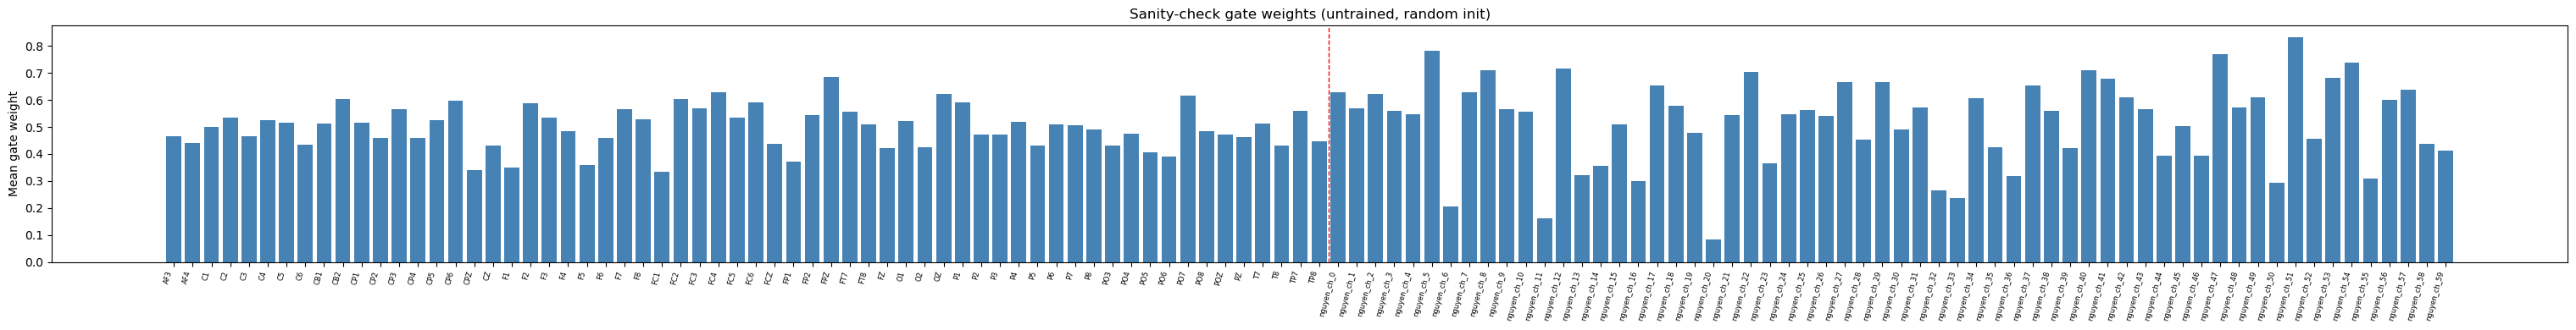

In [47]:
# =============================================================================
# SECTION 7.5 — SANITY CHECK
# =============================================================================

def test_section7() -> None:
    batch = next(iter(dataloaders["train"]))
    eeg = batch["eeg"].to(DEVICE)
    mask = batch["channel_mask"].to(DEVICE)
    subj_id = batch["subject_id"].to(DEVICE)
    ds_id = batch["dataset_id"].to(DEVICE)

    n_subjects = max(max(v.values()) for v in subject_name_to_id.values()) + 1
    n_datasets = len(dataset_name_to_id)

    for gate_type in ["sigmoid", "gumbel_softmax"]:
        gate = LearnedChannelGate(
            canonical_channels=CONFIG["channels"]["canonical_set_size"],
            gate_type=gate_type, n_subjects=n_subjects, n_datasets=n_datasets,
        ).to(DEVICE)

        gate.train()
        gated_eeg, gate_weights = gate(eeg, mask, subj_id, ds_id)

        assert gated_eeg.shape == eeg.shape, f"[{gate_type}] gated_eeg shape mismatch"
        assert gate_weights.shape == mask.shape, f"[{gate_type}] gate_weights shape mismatch"
        assert torch.isfinite(gate_weights).all(), f"[{gate_type}] gate_weights has NaN/Inf"
        assert (gate_weights >= 0).all() and (gate_weights <= 1).all(), \
            f"[{gate_type}] gate_weights outside [0, 1]"

        # THE critical check: padded channels must have exactly zero gate weight
        padded_positions = (mask == 0)
        assert torch.allclose(gate_weights[padded_positions],
                               torch.zeros_like(gate_weights[padded_positions])), \
            f"[{gate_type}] padded channel received non-zero gate weight — masking is broken!"

        # gradient flow check
        loss = gate_sparsity_loss(gate_weights, mask)
        loss.backward()
        has_grad = any(p.grad is not None and p.grad.abs().sum() > 0 for p in gate.parameters())
        assert has_grad, f"[{gate_type}] no gradient reached the gate's parameters"

        gate.eval()
        with torch.no_grad():
            _, gate_weights_eval = gate(eeg, mask, subj_id, ds_id)
        assert torch.allclose(gate_weights_eval[padded_positions],
                               torch.zeros_like(gate_weights_eval[padded_positions])), \
            f"[{gate_type}] masking broken in eval mode"

        print(f"  [{gate_type}] OK — sparsity loss = {loss.item():.4f}, "
              f"mean active-channel gate = "
              f"{(gate_weights.sum() / mask.sum()).item():.4f}")

    print("All Section 7 checks passed.")
    plot_gate_weights(gate_weights, mask, canonical_layout,
                       title="Sanity-check gate weights (untrained, random init)",
                       save_path=OUTPUT_DIRS["gate_weights"] / "sanity_check_untrained_gate.png")

test_section7()

In [48]:
# =============================================================================
# SECTION 8.1 — TEMPORAL CNN (DEPTHWISE + POINTWISE, EEGNet-style)
# =============================================================================
# Stage 1 (depthwise): one temporal filter set PER CHANNEL — learns
#   channel-specific temporal patterns without mixing channels yet.
# Stage 2 (pointwise): 1x1 conv across channels — mixes information across
#   channels into `embed_dim` feature maps, without touching the time axis.
# This is the standard EEGNet-style separable-convolution factorization,
# which keeps parameter count low relative to a full dense Conv1d.

class TemporalCNNBackbone(nn.Module):
    """Input : (B, C, T)  — gated EEG, C = canonical channels, T = time
    Output: (B, embed_dim, T_reduced)
    """

    def __init__(self,
                 in_channels: int = CONFIG["cnn"]["in_channels"],
                 temporal_filters: int = CONFIG["cnn"]["temporal_filters"],
                 depthwise_mult: int = CONFIG["cnn"]["depthwise_mult"],
                 kernel_size: int = CONFIG["cnn"]["kernel_size"],
                 pool_size: int = CONFIG["cnn"]["pool_size"],
                 dropout: float = CONFIG["cnn"]["dropout"],
                 embed_dim: int = CONFIG["attention"]["embed_dim"]):
        super().__init__()
        padding = kernel_size // 2
        depthwise_out = in_channels * depthwise_mult

        # --- Stage 1: depthwise temporal filtering (per-channel) -----------
        self.depthwise = nn.Sequential(
            nn.Conv1d(in_channels, depthwise_out, kernel_size,
                      padding=padding, groups=in_channels, bias=False),
            nn.BatchNorm1d(depthwise_out),
            nn.ELU(),
            nn.AvgPool1d(pool_size),
            nn.Dropout(dropout),
        )

        # --- Stage 2: pointwise channel mixing ------------------------------
        self.pointwise = nn.Sequential(
            nn.Conv1d(depthwise_out, temporal_filters, kernel_size=1, bias=False),
            nn.BatchNorm1d(temporal_filters),
            nn.ELU(),
            nn.AvgPool1d(pool_size),
            nn.Dropout(dropout),
        )

        # --- Stage 3: project to attention's embed_dim if they differ -------
        self.project = (nn.Identity() if temporal_filters == embed_dim
                         else nn.Conv1d(temporal_filters, embed_dim, kernel_size=1))

        self.pool_size = pool_size
        self.embed_dim = embed_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, C, T) -> (B, embed_dim, T // pool_size**2)"""
        x = self.depthwise(x)   # (B, depthwise_out, T // pool_size)
        x = self.pointwise(x)   # (B, temporal_filters, T // pool_size**2)
        x = self.project(x)     # (B, embed_dim, T // pool_size**2)
        return x

    def output_seq_len(self, input_len: int) -> int:
        """Utility so downstream modules can compute expected shapes without
        running a forward pass — used by the sanity check and Section 9."""
        return input_len // (self.pool_size ** 2)

In [49]:
# =============================================================================
# SECTION 8.2 — MULTI-HEAD SELF-ATTENTION (residual + LayerNorm)
# =============================================================================

class TemporalSelfAttention(nn.Module):
    """Standard post-norm transformer-style attention block operating over
    the time axis after the CNN.

    Input : (B, embed_dim, T')  — CNN output
    Output: (B, embed_dim, T')  — same shape, attention-refined
    """

    def __init__(self,
                 embed_dim: int = CONFIG["attention"]["embed_dim"],
                 num_heads: int = CONFIG["attention"]["num_heads"],
                 dropout: float = CONFIG["attention"]["dropout"]):
        super().__init__()
        assert embed_dim % num_heads == 0, \
            f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, embed_dim, T') -> (B, embed_dim, T')"""
        x_seq = x.transpose(1, 2)                          # (B, T', embed_dim) for MHA
        attn_out, _ = self.attn(x_seq, x_seq, x_seq, need_weights=False)
        x_seq = self.norm(x_seq + self.dropout(attn_out))  # residual + LayerNorm
        return x_seq.transpose(1, 2)                        # back to (B, embed_dim, T')

In [50]:
# =============================================================================
# SECTION 8.3 — BIDIRECTIONAL LSTM (2 layers, hidden size 128)
# =============================================================================

class BiLSTMBlock(nn.Module):
    """Input : (B, embed_dim, T')
    Output: (B, T', 2 * hidden_size)  — concatenated forward/backward states
            at every timestep (used for Feature Fusion's temporal pooling)
    """

    def __init__(self,
                 embed_dim: int = CONFIG["attention"]["embed_dim"],
                 hidden_size: int = CONFIG["bilstm"]["hidden_size"],
                 num_layers: int = CONFIG["bilstm"]["num_layers"],
                 dropout: float = CONFIG["bilstm"]["dropout"]):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_size, num_layers=num_layers,
            bidirectional=True, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.output_dim = hidden_size * 2

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, embed_dim, T') -> (B, T', 2*hidden_size)"""
        x_seq = x.transpose(1, 2)          # (B, T', embed_dim) for LSTM
        out, _ = self.lstm(x_seq)          # (B, T', 2*hidden_size)
        return out

In [51]:
# =============================================================================
# SECTION 8.4 — FEATURE FUSION
# =============================================================================
# Global-average-pools BOTH the attention branch and the BiLSTM branch over
# time, concatenates them, and projects through one FC layer. Pooling both
# branches (rather than only using the BiLSTM's final hidden state) keeps
# information from the attention stage directly accessible to the
# classification head, not just whatever the LSTM chose to retain.

class FeatureFusion(nn.Module):
    """Inputs:
        attn_out  : (B, embed_dim, T')   — from Section 8.2
        lstm_out  : (B, T', 2*hidden)    — from Section 8.3
    Output:
        fused     : (B, fusion_dim)
    """

    def __init__(self,
                 embed_dim: int = CONFIG["attention"]["embed_dim"],
                 lstm_output_dim: int = CONFIG["bilstm"]["hidden_size"] * 2,
                 fusion_dim: int = 128,
                 dropout: float = 0.3):
        super().__init__()
        concat_dim = embed_dim + lstm_output_dim
        self.fc = nn.Sequential(
            nn.Linear(concat_dim, fusion_dim),
            nn.ELU(),
            nn.Dropout(dropout),
        )
        self.fusion_dim = fusion_dim

    def forward(self, attn_out: torch.Tensor, lstm_out: torch.Tensor) -> torch.Tensor:
        attn_pooled = attn_out.mean(dim=-1)      # (B, embed_dim) — GAP over T'
        lstm_pooled = lstm_out.mean(dim=1)       # (B, 2*hidden)  — GAP over T'
        concat = torch.cat([attn_pooled, lstm_pooled], dim=-1)
        return self.fc(concat)                    # (B, fusion_dim)

In [52]:
# =============================================================================
# SECTION 8.5 — ASSEMBLED SHARED BACKBONE
# =============================================================================
# Combines 8.1-8.4 into one module. Classification heads (dataset-specific,
# Section 9) sit on top of this backbone's output and are NOT included here —
# this module produces a shared feature vector, nothing dataset-specific.

class SharedBackbone(nn.Module):
    """Input : (B, C, T)    — gated EEG from Section 7's channel gate
    Output: (B, fusion_dim) — shared feature vector for all dataset heads
    """

    def __init__(self):
        super().__init__()
        self.cnn = TemporalCNNBackbone()
        self.attention = TemporalSelfAttention()
        self.bilstm = BiLSTMBlock()
        self.fusion = FeatureFusion(
            embed_dim=CONFIG["attention"]["embed_dim"],
            lstm_output_dim=CONFIG["bilstm"]["hidden_size"] * 2,
        )
        self.fusion_dim = self.fusion.fusion_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cnn_out = self.cnn(x)             # (B, embed_dim, T')
        attn_out = self.attention(cnn_out)  # (B, embed_dim, T')
        lstm_out = self.bilstm(attn_out)    # (B, T', 2*hidden)
        fused = self.fusion(attn_out, lstm_out)  # (B, fusion_dim)
        return fused

    def expected_seq_len(self, input_len: int = TARGET_EPOCH_SAMPLES) -> int:
        return self.cnn.output_seq_len(input_len)

In [53]:
# =============================================================================
# SECTION 8.6 — SANITY CHECK
# =============================================================================

def test_section8() -> None:
    backbone = SharedBackbone().to(DEVICE)
    backbone.eval()

    batch = next(iter(dataloaders["train"]))
    eeg = batch["eeg"].to(DEVICE)          # (B, 122, 1280)
    mask = batch["channel_mask"].to(DEVICE)

    # run through the (untrained) gate first, since the backbone consumes
    # gated EEG in the real pipeline, not raw EEG directly
    gate = LearnedChannelGate(
        canonical_channels=CONFIG["channels"]["canonical_set_size"],
        n_subjects=max(max(v.values()) for v in subject_name_to_id.values()) + 1,
        n_datasets=len(dataset_name_to_id),
    ).to(DEVICE)
    gate.eval()
    with torch.no_grad():
        gated_eeg, _ = gate(eeg, mask, batch["subject_id"].to(DEVICE), batch["dataset_id"].to(DEVICE))

    expected_T = backbone.expected_seq_len(eeg.shape[-1])
    print(f"Input shape        : {tuple(eeg.shape)}")
    print(f"Expected T' after CNN pooling: {expected_T}")

    with torch.no_grad():
        cnn_out = backbone.cnn(gated_eeg)
        assert cnn_out.shape == (eeg.shape[0], CONFIG["attention"]["embed_dim"], expected_T), \
            f"CNN output shape {tuple(cnn_out.shape)} doesn't match expected " \
            f"({eeg.shape[0]}, {CONFIG['attention']['embed_dim']}, {expected_T})"

        attn_out = backbone.attention(cnn_out)
        assert attn_out.shape == cnn_out.shape, "Attention should preserve shape"

        lstm_out = backbone.bilstm(attn_out)
        expected_lstm_dim = CONFIG["bilstm"]["hidden_size"] * 2
        assert lstm_out.shape == (eeg.shape[0], expected_T, expected_lstm_dim), \
            f"BiLSTM output shape {tuple(lstm_out.shape)} unexpected"

        fused = backbone.fusion(attn_out, lstm_out)
        assert fused.shape == (eeg.shape[0], backbone.fusion_dim), \
            f"Fusion output shape {tuple(fused.shape)} unexpected"

        full_out = backbone(gated_eeg)
        assert torch.allclose(full_out, fused), "backbone.forward() should match manual stage-by-stage output"
        assert torch.isfinite(full_out).all(), "Backbone output contains NaN/Inf"

    # gradient flow check (train mode)
    backbone.train()
    out = backbone(gated_eeg)
    loss = out.sum()
    loss.backward()
    has_grad = any(p.grad is not None and p.grad.abs().sum() > 0 for p in backbone.parameters())
    assert has_grad, "No gradient reached backbone parameters"

    n_params = sum(p.numel() for p in backbone.parameters())
    n_trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)

    print("All Section 8 checks passed.")
    print(f"  CNN output shape    : {tuple(cnn_out.shape)}")
    print(f"  Attention out shape : {tuple(attn_out.shape)}")
    print(f"  BiLSTM out shape    : {tuple(lstm_out.shape)}")
    print(f"  Fused output shape  : {tuple(fused.shape)}")
    print(f"  Total parameters    : {n_params:,}")
    print(f"  Trainable parameters: {n_trainable:,}")

test_section8()

Input shape        : (32, 122, 1280)
Expected T' after CNN pooling: 80
All Section 8 checks passed.
  CNN output shape    : (32, 64, 80)
  Attention out shape : (32, 64, 80)
  BiLSTM out shape    : (32, 80, 256)
  Fused output shape  : (32, 128)
  Total parameters    : 668,348
  Trainable parameters: 668,348


In [54]:
# =============================================================================
# SECTION 9.1 — DATASET-SPECIFIC CLASSIFICATION HEADS
# =============================================================================

def get_dataset_num_classes(trial_index_df: pd.DataFrame,
                             label_encoders: Dict[str, LabelEncoder]) -> Dict[str, int]:
    """Number of classes per dataset, driving each head's output dimension."""
    return {name: len(le.classes_) for name, le in label_encoders.items()}


class DatasetSpecificHead(nn.Module):
    """A small MLP head for one dataset: fusion_dim -> hidden -> n_classes."""

    def __init__(self, fusion_dim: int, n_classes: int, hidden_dim: int = 64,
                 dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)  # (B, n_classes) — raw logits

In [55]:
# =============================================================================
# SECTION 9.2 — COMPLETE MODEL (gate + backbone + routed heads)
# =============================================================================

class ImaginedSpeechModel(nn.Module):
    """End-to-end model: LearnedChannelGate -> SharedBackbone -> per-dataset head.

    A single forward() call can process a batch containing samples from
    MULTIPLE datasets at once (as DataLoaders from Section 6 naturally produce,
    since the weighted sampler draws across all datasets). Each sample is
    routed to its own dataset's head; the returned logits tensor is only
    valid per-sample against that sample's OWN dataset's class vocabulary —
    callers must use `dataset_id` to know which head's output space a given
    row of `logits` belongs to (Section 10's loss function handles this).
    """

    def __init__(self,
                 dataset_name_to_id: Dict[str, int],
                 num_classes_per_dataset: Dict[str, int],
                 n_subjects: int, n_datasets: int):
        super().__init__()
        self.dataset_name_to_id = dataset_name_to_id
        self.id_to_dataset_name = {v: k for k, v in dataset_name_to_id.items()}

        self.gate = LearnedChannelGate(
            canonical_channels=CONFIG["channels"]["canonical_set_size"],
            n_subjects=n_subjects, n_datasets=n_datasets,
        )
        self.backbone = SharedBackbone()

        # one head per dataset, keyed by string name (ModuleDict requires str keys)
        self.heads = nn.ModuleDict({
            name: DatasetSpecificHead(self.backbone.fusion_dim, num_classes_per_dataset[name])
            for name in dataset_name_to_id
        })

    def forward(self, eeg: torch.Tensor, channel_mask: torch.Tensor,
                subject_id: torch.Tensor, dataset_id: torch.Tensor,
                return_gate: bool = False
                ) -> Union[List[torch.Tensor], Tuple[List[torch.Tensor], torch.Tensor, torch.Tensor]]:
        """
        Parameters
        ----------
        eeg, channel_mask, subject_id, dataset_id : batch tensors from Section 6's DataLoader
        return_gate : if True, also return (gate_weights, gated_eeg) for the
                      sparsity loss (Section 10) and XAI (Section 15)

        Returns
        -------
        logits_per_sample : List[Tensor] — one 1D logits tensor per sample,
            length == that sample's dataset's n_classes (variable length across
            the batch, so a list rather than a stacked tensor — samples from
            different datasets have different class counts and cannot be
            stacked into one rectangular tensor).
        (if return_gate) gate_weights (B, C), gated_eeg (B, C, T)
        """
        gated_eeg, gate_weights = self.gate(eeg, channel_mask, subject_id, dataset_id)
        features = self.backbone(gated_eeg)  # (B, fusion_dim) — shared across all samples

        logits_per_sample = []
        for i in range(features.shape[0]):
            ds_name = self.id_to_dataset_name[dataset_id[i].item()]
            head = self.heads[ds_name]
            logits_per_sample.append(head(features[i].unsqueeze(0)).squeeze(0))

        if return_gate:
            return logits_per_sample, gate_weights, gated_eeg
        return logits_per_sample

    def forward_single_dataset(self, eeg: torch.Tensor, channel_mask: torch.Tensor,
                                subject_id: torch.Tensor, dataset_id: torch.Tensor,
                                dataset_name: str, return_gate: bool = False):
        """Efficient path for the common case where an ENTIRE batch belongs to
        one dataset (e.g. Section 11's per-dataset training loop, Section 13's
        per-dataset evaluation) — avoids the per-sample Python loop above and
        returns a single stacked (B, n_classes) tensor instead of a list.
        """
        gated_eeg, gate_weights = self.gate(eeg, channel_mask, subject_id, dataset_id)
        features = self.backbone(gated_eeg)
        logits = self.heads[dataset_name](features)  # (B, n_classes)

        if return_gate:
            return logits, gate_weights, gated_eeg
        return logits

In [56]:
# =============================================================================
# SECTION 9.3 — MODEL SUMMARY, PARAMETER COUNT, FLOPS
# =============================================================================

def count_parameters(model: nn.Module) -> Dict[str, int]:
    """Parameter counts broken down by top-level submodule, plus totals."""
    breakdown = {}
    for name, module in model.named_children():
        breakdown[name] = sum(p.numel() for p in module.parameters())
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    breakdown["TOTAL"] = total
    breakdown["TRAINABLE"] = trainable
    return breakdown


def estimate_flops(model: "ImaginedSpeechModel", input_shape: Tuple[int, int, int],
                    dataset_name: str) -> Optional[int]:
    """FLOPs estimate via torch.utils.flop_counter if available (PyTorch 2.1+);
    returns None gracefully if unavailable rather than failing the notebook,
    since FLOP counting tooling varies across PyTorch versions/environments.
    """
    try:
        from torch.utils.flop_counter import FlopCounterMode
    except ImportError:
        logger.warning("torch.utils.flop_counter unavailable in this PyTorch "
                        "version — skipping FLOPs estimate.")
        return None

    B, C, T = input_shape
    dummy_eeg = torch.randn(B, C, T, device=DEVICE)
    dummy_mask = torch.ones(B, C, device=DEVICE)
    dummy_subj = torch.zeros(B, dtype=torch.long, device=DEVICE)
    dummy_ds = torch.full((B,), model.dataset_name_to_id[dataset_name],
                           dtype=torch.long, device=DEVICE)

    model.eval()
    try:
        with FlopCounterMode(display=False) as fc:
            with torch.no_grad():
                model.forward_single_dataset(dummy_eeg, dummy_mask, dummy_subj, dummy_ds, dataset_name)
        return fc.get_total_flops()
    except Exception as e:
        logger.warning(f"FLOPs estimation failed ({e}) — skipping.")
        return None


def print_model_summary(model: "ImaginedSpeechModel") -> None:
    breakdown = count_parameters(model)
    print("=" * 70)
    print("MODEL SUMMARY")
    print("=" * 70)
    print(f"{'Component':<20}{'Parameters':>15}")
    print("-" * 35)
    for name, count in breakdown.items():
        if name in {"TOTAL", "TRAINABLE"}:
            continue
        print(f"{name:<20}{count:>15,}")
    print("-" * 35)
    print(f"{'TOTAL':<20}{breakdown['TOTAL']:>15,}")
    print(f"{'TRAINABLE':<20}{breakdown['TRAINABLE']:>15,}")
    print("=" * 70)

    for ds_name in model.dataset_name_to_id:
        flops = estimate_flops(model, (1, CONFIG["channels"]["canonical_set_size"],
                                        TARGET_EPOCH_SAMPLES), ds_name)
        if flops is not None:
            print(f"Estimated FLOPs (batch=1, {ds_name} head): {flops:,}")
    print("=" * 70)

In [57]:
# =============================================================================
# SECTION 9.4 — BUILD THE COMPLETE MODEL
# =============================================================================

num_classes_per_dataset = get_dataset_num_classes(trial_index_df, label_encoders)
n_subjects_total = max(max(v.values()) for v in subject_name_to_id.values()) + 1
n_datasets_total = len(dataset_name_to_id)

print(f"Classes per dataset: {num_classes_per_dataset}")
print(f"n_subjects (embedding vocab size): {n_subjects_total}")
print(f"n_datasets (embedding vocab size): {n_datasets_total}")

model = ImaginedSpeechModel(
    dataset_name_to_id=dataset_name_to_id,
    num_classes_per_dataset=num_classes_per_dataset,
    n_subjects=n_subjects_total,
    n_datasets=n_datasets_total,
).to(DEVICE)

print_model_summary(model)

Classes per dataset: {'kara_one': 11, 'feis': 16, 'nguyen': 3}
n_subjects (embedding vocab size): 21
n_datasets (embedding vocab size): 3
MODEL SUMMARY
Component                Parameters
-----------------------------------
gate                          3,281
backbone                    668,348
heads                        26,718
-----------------------------------
TOTAL                       698,347
TRAINABLE                   698,347
Estimated FLOPs (batch=1, feis head): 615,956,096
Estimated FLOPs (batch=1, kara_one head): 615,955,456
Estimated FLOPs (batch=1, nguyen head): 615,954,432


In [58]:
# =============================================================================
# SECTION 9.5 — SANITY CHECK
# =============================================================================

def test_section9() -> None:
    model.eval()
    batch = next(iter(dataloaders["train"]))
    eeg = batch["eeg"].to(DEVICE)
    mask = batch["channel_mask"].to(DEVICE)
    subj_id = batch["subject_id"].to(DEVICE)
    ds_id = batch["dataset_id"].to(DEVICE)
    labels = batch["label"].to(DEVICE)

    # 1. Mixed-dataset batch forward (the general path)
    with torch.no_grad():
        logits_list, gate_weights, gated_eeg = model(eeg, mask, subj_id, ds_id, return_gate=True)

    assert len(logits_list) == eeg.shape[0], "logits_per_sample length mismatch"
    for i, logits in enumerate(logits_list):
        ds_name = model.id_to_dataset_name[ds_id[i].item()]
        expected_n_classes = num_classes_per_dataset[ds_name]
        assert logits.shape == (expected_n_classes,), \
            f"Sample {i} ({ds_name}) logits shape {tuple(logits.shape)} != " \
            f"expected ({expected_n_classes},)"
        assert torch.isfinite(logits).all(), f"Sample {i} logits contain NaN/Inf"

    assert gate_weights.shape == mask.shape
    assert gated_eeg.shape == eeg.shape

    # 2. Single-dataset efficient path — pick whichever dataset the first
    #    sample in this batch belongs to, and filter the batch to just that
    #    dataset so shapes line up for the stacked-tensor path
    first_ds_name = model.id_to_dataset_name[ds_id[0].item()]
    same_ds_mask = (ds_id == dataset_name_to_id[first_ds_name])
    assert same_ds_mask.sum() > 0

    with torch.no_grad():
        logits_stacked = model.forward_single_dataset(
            eeg[same_ds_mask], mask[same_ds_mask],
            subj_id[same_ds_mask], ds_id[same_ds_mask], first_ds_name,
        )
    expected_shape = (int(same_ds_mask.sum()), num_classes_per_dataset[first_ds_name])
    assert logits_stacked.shape == expected_shape, \
        f"forward_single_dataset shape {tuple(logits_stacked.shape)} != expected {expected_shape}"

    # 3. Gradient flow through the ENTIRE model (gate + backbone + all heads
    #    that appear in this batch), using a simple per-sample CE loss
    model.train()
    logits_list = model(eeg, mask, subj_id, ds_id)
    total_loss = sum(F.cross_entropy(l.unsqueeze(0), labels[i].unsqueeze(0))
                      for i, l in enumerate(logits_list))
    total_loss.backward()

    grad_components = {
        "gate": any(p.grad is not None and p.grad.abs().sum() > 0 for p in model.gate.parameters()),
        "backbone": any(p.grad is not None and p.grad.abs().sum() > 0 for p in model.backbone.parameters()),
    }
    for ds_name in dataset_name_to_id:
        if (ds_id == dataset_name_to_id[ds_name]).any():
            grad_components[f"head[{ds_name}]"] = any(
                p.grad is not None and p.grad.abs().sum() > 0
                for p in model.heads[ds_name].parameters()
            )

    for component, has_grad in grad_components.items():
        assert has_grad, f"No gradient reached '{component}' — check routing/forward logic"

    print("All Section 9 checks passed.")
    print(f"  Mixed-batch logits list length : {len(logits_list)}")
    print(f"  Single-dataset stacked shape   : {tuple(logits_stacked.shape)}")
    print(f"  Gradient reached               : {list(grad_components.keys())}")

test_section9()

All Section 9 checks passed.
  Mixed-batch logits list length : 32
  Single-dataset stacked shape   : (18, 16)
  Gradient reached               : ['gate', 'backbone', 'head[feis]', 'head[kara_one]', 'head[nguyen]']


In [59]:
# =============================================================================
# SECTION 10.1 — CLASS WEIGHTS (per dataset, from actual training-split counts)
# =============================================================================

def compute_class_weights(trial_index_df: pd.DataFrame, split_df: pd.DataFrame,
                           label_encoders: Dict[str, LabelEncoder]
                           ) -> Dict[str, torch.Tensor]:
    """Inverse-frequency class weights per dataset, computed from the TRAINING
    split only (never val/test, to avoid leaking split-specific class balance
    into the loss). Returns one weight tensor per dataset, indexed by that
    dataset's own label_id space, ready to pass to F.cross_entropy(weight=...).
    """
    weights = {}
    for name, le in label_encoders.items():
        n_classes = len(le.classes_)
        sub = split_df[split_df["dataset"] == name]
        if sub.empty:
            weights[name] = torch.ones(n_classes)
            continue
        counts = sub["label_id"].value_counts().reindex(range(n_classes), fill_value=0)
        freq = counts.values.astype(np.float32)
        freq_safe = np.where(freq == 0, 1.0, freq)  # avoid div-by-zero for absent classes
        inv_freq = 1.0 / freq_safe
        normalized = inv_freq / inv_freq.sum() * n_classes  # mean weight ~1.0
        weights[name] = torch.tensor(normalized, dtype=torch.float32)
    return weights


class_weights = compute_class_weights(trial_index_df, default_split["train"], label_encoders)
for name, w in class_weights.items():
    print(f"[{name}] class weights: {w.numpy().round(2)}")

[kara_one] class weights: [0.98 0.98 0.98 1.06 1.02 1.02 1.02 0.98 0.98 1.02 0.98]
[feis] class weights: [1.01 1.   0.99 1.04 1.01 1.01 1.01 0.98 0.99 0.98 0.99 0.98 1.01 1.
 1.03 0.98]
[nguyen] class weights: [1.   1.01 0.99]


In [60]:
# =============================================================================
# SECTION 10.2 — FOCAL LOSS (optional, per CONFIG['training']['use_focal_loss'])
# =============================================================================

def focal_loss(logits: torch.Tensor, target: torch.Tensor,
                weight: Optional[torch.Tensor] = None,
                gamma: float = CONFIG["training"]["focal_gamma"],
                label_smoothing: float = CONFIG["training"]["label_smoothing"]
                ) -> torch.Tensor:
    """Multi-class focal loss: down-weights easy (high-confidence-correct)
    examples so training focuses on hard/rare classes. Built on top of
    F.cross_entropy so label smoothing and class weighting compose naturally
    with it, rather than reimplementing softmax cross-entropy from scratch.

    logits : (B, n_classes) — single-dataset stacked logits
    target : (B,) long
    """
    ce = F.cross_entropy(logits, target, weight=weight,
                          label_smoothing=label_smoothing, reduction="none")
    pt = torch.exp(-ce)  # model's probability assigned to the true class
    focal_term = (1 - pt) ** gamma
    return (focal_term * ce).mean()

In [61]:
# =============================================================================
# SECTION 10.3 — TOTAL LOSS (classification + sparsity + L2)
# =============================================================================

def classification_loss_single(logits: torch.Tensor, target: torch.Tensor,
                                dataset_name: str,
                                class_weights: Dict[str, torch.Tensor],
                                use_focal: bool = CONFIG["training"]["use_focal_loss"],
                                label_smoothing: float = CONFIG["training"]["label_smoothing"]
                                ) -> torch.Tensor:
    """Classification loss for a stacked (B, n_classes) logits tensor, all
    belonging to ONE dataset (the forward_single_dataset path)."""
    weight = class_weights.get(dataset_name)
    if weight is not None:
        weight = weight.to(logits.device)

    if use_focal:
        return focal_loss(logits, target, weight=weight, label_smoothing=label_smoothing)
    return F.cross_entropy(logits, target, weight=weight, label_smoothing=label_smoothing)


def classification_loss_mixed(logits_list: List[torch.Tensor], target: torch.Tensor,
                               dataset_id: torch.Tensor,
                               id_to_dataset_name: Dict[int, str],
                               class_weights: Dict[str, torch.Tensor],
                               use_focal: bool = CONFIG["training"]["use_focal_loss"],
                               label_smoothing: float = CONFIG["training"]["label_smoothing"]
                               ) -> torch.Tensor:
    """Classification loss for the per-sample logits LIST produced by
    model.forward() on a mixed-dataset batch. Each sample is scored against
    its own dataset's class weights, then averaged.
    """
    losses = []
    for i, logits in enumerate(logits_list):
        ds_name = id_to_dataset_name[dataset_id[i].item()]
        weight = class_weights.get(ds_name)
        if weight is not None:
            weight = weight.to(logits.device)

        logits_b = logits.unsqueeze(0)
        target_b = target[i].unsqueeze(0)

        if use_focal:
            losses.append(focal_loss(logits_b, target_b, weight=weight,
                                      label_smoothing=label_smoothing))
        else:
            losses.append(F.cross_entropy(logits_b, target_b, weight=weight,
                                           label_smoothing=label_smoothing))
    return torch.stack(losses).mean()


def l2_regularization(model: nn.Module) -> torch.Tensor:
    """Manual L2 penalty over all model parameters. Kept separate from the
    optimizer's built-in weight_decay so CONFIG['training']['l2_lambda'] can
    be tuned independently of AdamW's decoupled weight decay — the two serve
    different theoretical purposes and are not redundant to expose separately.
    """
    return sum((p ** 2).sum() for p in model.parameters() if p.requires_grad)


def compute_total_loss(
    model_output: Union[torch.Tensor, List[torch.Tensor]],
    target: torch.Tensor,
    gate_weights: torch.Tensor,
    channel_mask: torch.Tensor,
    model: nn.Module,
    class_weights: Dict[str, torch.Tensor],
    dataset_id: Optional[torch.Tensor] = None,
    id_to_dataset_name: Optional[Dict[int, str]] = None,
    dataset_name: Optional[str] = None,
    sparsity_coef: float = CONFIG["channel_gate"]["sparsity_coefficient"],
    l2_lambda: float = CONFIG["training"]["l2_lambda"],
) -> Dict[str, torch.Tensor]:
    """Total loss = classification + sparsity_coef * gate_sparsity + l2_lambda * L2.

    Dispatches on the type of `model_output`:
      - List[Tensor]  -> mixed-dataset batch; requires dataset_id + id_to_dataset_name
      - Tensor        -> single-dataset stacked batch; requires dataset_name

    Returns a dict of all components (not just the summed total) so Section 11's
    training loop can log each term separately for diagnostics.
    """
    if isinstance(model_output, list):
        assert dataset_id is not None and id_to_dataset_name is not None, \
            "Mixed-batch (list) logits require dataset_id and id_to_dataset_name."
        cls_loss = classification_loss_mixed(
            model_output, target, dataset_id, id_to_dataset_name, class_weights
        )
    else:
        assert dataset_name is not None, \
            "Single-dataset (tensor) logits require dataset_name."
        cls_loss = classification_loss_single(model_output, target, dataset_name, class_weights)

    sparsity = gate_sparsity_loss(gate_weights, channel_mask)
    l2 = l2_regularization(model)

    total = cls_loss + sparsity_coef * sparsity + l2_lambda * l2

    return {
        "total": total,
        "classification": cls_loss.detach(),
        "sparsity": sparsity.detach(),
        "l2": l2.detach(),
    }

In [62]:
# =============================================================================
# SECTION 10.4 — SANITY CHECK
# =============================================================================

def test_section10() -> None:
    model.train()
    batch = next(iter(dataloaders["train"]))
    eeg = batch["eeg"].to(DEVICE)
    mask = batch["channel_mask"].to(DEVICE)
    subj_id = batch["subject_id"].to(DEVICE)
    ds_id = batch["dataset_id"].to(DEVICE)
    labels = batch["label"].to(DEVICE)

    # --- 1. Mixed-batch path -------------------------------------------------
    logits_list, gate_weights, gated_eeg = model(eeg, mask, subj_id, ds_id, return_gate=True)
    loss_dict_mixed = compute_total_loss(
        logits_list, labels, gate_weights, mask, model, class_weights,
        dataset_id=ds_id, id_to_dataset_name=model.id_to_dataset_name,
    )
    for k, v in loss_dict_mixed.items():
        assert torch.isfinite(v), f"[mixed] loss component '{k}' is NaN/Inf"
    assert loss_dict_mixed["total"].requires_grad, "[mixed] total loss has no grad_fn"

    model.zero_grad()
    loss_dict_mixed["total"].backward()
    has_grad = any(p.grad is not None and p.grad.abs().sum() > 0 for p in model.parameters())
    assert has_grad, "[mixed] no gradient reached model parameters"

    # --- 2. Single-dataset path -----------------------------------------------
    first_ds_name = model.id_to_dataset_name[ds_id[0].item()]
    same_ds = (ds_id == dataset_name_to_id[first_ds_name])

    model.zero_grad()
    logits_stacked, gate_weights_s, gated_eeg_s = model.forward_single_dataset(
        eeg[same_ds], mask[same_ds], subj_id[same_ds], ds_id[same_ds],
        first_ds_name, return_gate=True,
    )
    loss_dict_single = compute_total_loss(
        logits_stacked, labels[same_ds], gate_weights_s, mask[same_ds], model,
        class_weights, dataset_name=first_ds_name,
    )
    for k, v in loss_dict_single.items():
        assert torch.isfinite(v), f"[single] loss component '{k}' is NaN/Inf"

    loss_dict_single["total"].backward()

    # --- 3. Focal loss variant (toggle on, verify it also runs clean) --------
    logits_focal = model.heads[first_ds_name](
        model.backbone(model.gate(eeg[same_ds], mask[same_ds], subj_id[same_ds], ds_id[same_ds])[0])
    )
    fl = focal_loss(logits_focal, labels[same_ds], weight=class_weights[first_ds_name].to(DEVICE))
    assert torch.isfinite(fl), "focal loss is NaN/Inf"

    print("All Section 10 checks passed.")
    print(f"  [mixed]  total={loss_dict_mixed['total'].item():.4f} | "
          f"cls={loss_dict_mixed['classification'].item():.4f} | "
          f"sparsity={loss_dict_mixed['sparsity'].item():.4f} | "
          f"l2={loss_dict_mixed['l2'].item():.6f}")
    print(f"  [single] total={loss_dict_single['total'].item():.4f} | "
          f"cls={loss_dict_single['classification'].item():.4f} | "
          f"sparsity={loss_dict_single['sparsity'].item():.4f} | "
          f"l2={loss_dict_single['l2'].item():.6f}")
    print(f"  [focal]  loss={fl.item():.4f}")

test_section10()

All Section 10 checks passed.
  [mixed]  total=2.5832 | cls=2.5580 | sparsity=0.4625 | l2=2475.377930
  [single] total=2.8262 | cls=2.8010 | sparsity=0.4604 | l2=2475.377930
  [focal]  loss=2.4563


In [63]:
# =============================================================================
# SECTION 11.1 — OPTIMIZER & SCHEDULER BUILDERS
# =============================================================================

def build_optimizer(model: nn.Module,
                     cfg: Dict[str, Any] = CONFIG["training"]) -> torch.optim.Optimizer:
    params = model.parameters()
    if cfg["optimizer"] == "adamw":
        return torch.optim.AdamW(params, lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    elif cfg["optimizer"] == "adam":
        return torch.optim.Adam(params, lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    elif cfg["optimizer"] == "sgd":
        return torch.optim.SGD(params, lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"],
                                momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {cfg['optimizer']}")


def build_scheduler(optimizer: torch.optim.Optimizer,
                     cfg: Dict[str, Any] = CONFIG["training"]
                     ) -> Optional[torch.optim.lr_scheduler._LRScheduler]:
    kind = cfg["scheduler"]
    if kind == "none":
        return None
    params = cfg["scheduler_params"][kind]
    if kind == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, **params)
    elif kind == "step":
        return torch.optim.lr_scheduler.StepLR(optimizer, **params)
    elif kind == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, **params)
    else:
        raise ValueError(f"Unknown scheduler: {kind}")

In [64]:
# =============================================================================
# SECTION 11.2 — TRAINER CLASS (part 1: init, checkpoint, early stopping)
# =============================================================================

class EarlyStopping:
    """Tracks validation loss; signals stop after `patience` epochs without
    improvement beyond `min_delta`."""

    def __init__(self, patience: int = CONFIG["training"]["early_stopping_patience"],
                 min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss: float) -> bool:
        """Returns True if val_loss is a new best."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


class Trainer:
    """Orchestrates training for ImaginedSpeechModel: epoch loops, AMP,
    gradient clipping, LR scheduling, checkpointing, early stopping, resume.

    Designed to be reused across different runs (subject-dependent, each LOSO
    fold) by constructing a fresh Trainer per run with that run's own
    dataloaders and a distinct `run_name` (controls checkpoint filenames).
    """

    def __init__(self,
                 model: "ImaginedSpeechModel",
                 dataloaders: Dict[str, DataLoader],
                 class_weights: Dict[str, torch.Tensor],
                 run_name: str,
                 cfg: Dict[str, Any] = CONFIG["training"],
                 checkpoint_dir: Path = OUTPUT_DIRS["checkpoints"]):
        self.model = model.to(DEVICE)
        self.dataloaders = dataloaders
        self.class_weights = class_weights
        self.run_name = run_name
        self.cfg = cfg
        self.checkpoint_dir = checkpoint_dir
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

        self.optimizer = build_optimizer(model, cfg)
        self.scheduler = build_scheduler(self.optimizer, cfg)
        self.scaler = get_grad_scaler()
        self.early_stopping = EarlyStopping(patience=cfg["early_stopping_patience"])

        self.history: List[Dict[str, float]] = []
        self.start_epoch = 0
        self.best_val_loss = float("inf")

    # ---- checkpointing ----------------------------------------------------
    def _checkpoint_path(self, tag: str) -> Path:
        return self.checkpoint_dir / f"{self.run_name}_{tag}.pth"

    def save_checkpoint(self, epoch: int, val_loss: float, tag: str = "last") -> Path:
        path = self._checkpoint_path(tag)
        torch.save({
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "scheduler_state_dict": self.scheduler.state_dict() if self.scheduler else None,
            "scaler_state_dict": self.scaler.state_dict() if self.scaler else None,
            "val_loss": val_loss,
            "history": self.history,
            "config_snapshot": {k: v for k, v in self.cfg.items()},  # shallow, for audit
        }, path)
        return path

    def load_checkpoint(self, tag: str = "last") -> bool:
        """Resume from a saved checkpoint if present. Returns True if resumed."""
        path = self._checkpoint_path(tag)
        if not path.exists():
            return False
        ckpt = torch.load(path, map_location=DEVICE)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        if self.scheduler and ckpt.get("scheduler_state_dict"):
            self.scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        if self.scaler and ckpt.get("scaler_state_dict"):
            self.scaler.load_state_dict(ckpt["scaler_state_dict"])
        self.start_epoch = ckpt["epoch"] + 1
        self.best_val_loss = ckpt["val_loss"]
        self.history = ckpt.get("history", [])
        logger.info(f"[{self.run_name}] Resumed from epoch {self.start_epoch} "
                    f"(checkpoint val_loss={self.best_val_loss:.4f})")
        return True

In [65]:
# =============================================================================
# SECTION 11.3 — TRAINER CLASS (part 2: train_epoch / validate_epoch)
# =============================================================================

def _run_step(model: "ImaginedSpeechModel", batch: Dict[str, torch.Tensor],
              class_weights: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    """One forward pass + loss computation on a mixed-dataset batch. Shared by
    train_epoch (with backward) and validate_epoch (no_grad)."""
    eeg = batch["eeg"].to(DEVICE, non_blocking=True)
    mask = batch["channel_mask"].to(DEVICE, non_blocking=True)
    subj_id = batch["subject_id"].to(DEVICE, non_blocking=True)
    ds_id = batch["dataset_id"].to(DEVICE, non_blocking=True)
    labels = batch["label"].to(DEVICE, non_blocking=True)

    logits_list, gate_weights, gated_eeg = model(eeg, mask, subj_id, ds_id, return_gate=True)
    loss_dict = compute_total_loss(
        logits_list, labels, gate_weights, mask, model, class_weights,
        dataset_id=ds_id, id_to_dataset_name=model.id_to_dataset_name,
    )

    # per-sample accuracy, computed against each sample's own dataset head
    preds = [int(l.argmax().item()) for l in logits_list]
    correct = sum(p == int(t.item()) for p, t in zip(preds, labels))
    loss_dict["n_correct"] = correct
    loss_dict["n_total"] = len(preds)
    return loss_dict


def train_epoch(self: Trainer) -> Dict[str, float]:
    self.model.train()
    epoch_losses = {"total": 0.0, "classification": 0.0, "sparsity": 0.0, "l2": 0.0}
    n_correct, n_total = 0, 0

    pbar = tqdm(self.dataloaders["train"], desc="  train", leave=False)
    for batch in pbar:
        self.optimizer.zero_grad()

        if USE_AMP:
            with autocast():
                loss_dict = _run_step(self.model, batch, self.class_weights)
            self.scaler.scale(loss_dict["total"]).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg["grad_clip_norm"])
            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            loss_dict = _run_step(self.model, batch, self.class_weights)
            loss_dict["total"].backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg["grad_clip_norm"])
            self.optimizer.step()

        for k in epoch_losses:
            epoch_losses[k] += loss_dict[k].item() if torch.is_tensor(loss_dict[k]) else loss_dict[k]
        n_correct += loss_dict["n_correct"]
        n_total += loss_dict["n_total"]

        pbar.set_postfix(loss=f"{loss_dict['total'].item():.3f}",
                          acc=f"{n_correct / max(n_total, 1):.3f}",
                          lr=f"{self.optimizer.param_groups[0]['lr']:.2e}")

    n_batches = len(self.dataloaders["train"])
    result = {k: v / n_batches for k, v in epoch_losses.items()}
    result["accuracy"] = n_correct / max(n_total, 1)
    return result


@torch.no_grad()
def validate_epoch(self: Trainer, phase: str = "val") -> Dict[str, float]:
    self.model.eval()
    epoch_losses = {"total": 0.0, "classification": 0.0, "sparsity": 0.0, "l2": 0.0}
    n_correct, n_total = 0, 0

    pbar = tqdm(self.dataloaders[phase], desc=f"  {phase}", leave=False)
    for batch in pbar:
        if USE_AMP:
            with autocast():
                loss_dict = _run_step(self.model, batch, self.class_weights)
        else:
            loss_dict = _run_step(self.model, batch, self.class_weights)

        for k in epoch_losses:
            epoch_losses[k] += loss_dict[k].item() if torch.is_tensor(loss_dict[k]) else loss_dict[k]
        n_correct += loss_dict["n_correct"]
        n_total += loss_dict["n_total"]

    n_batches = len(self.dataloaders[phase])
    result = {k: v / max(n_batches, 1) for k, v in epoch_losses.items()}
    result["accuracy"] = n_correct / max(n_total, 1)
    return result


# attach as bound methods
Trainer.train_epoch = train_epoch
Trainer.validate_epoch = validate_epoch

In [66]:
# =============================================================================
# SECTION 11.4 — TRAINER CLASS (part 3: fit() — the full training loop)
# =============================================================================

def fit(self: Trainer, epochs: Optional[int] = None, resume: bool = True,
        verbose: bool = True) -> pd.DataFrame:
    """Run the full training loop: train/val each epoch, step the scheduler,
    checkpoint best + last, early-stop when validation stops improving.

    Returns
    -------
    DataFrame with one row per epoch (train/val loss+acc, lr) — also saved
    to CSV under outputs/metrics/.
    """
    epochs = epochs or self.cfg["epochs"]

    if resume:
        self.load_checkpoint("last")

    for epoch in range(self.start_epoch, epochs):
        t0 = time.time()

        # anneal Gumbel temperature if the gate uses that mode
        if self.model.gate.gate_type == "gumbel_softmax":
            new_temp = CONFIG["channel_gate"]["gumbel_temperature"] * \
                       np.exp(-CONFIG["channel_gate"]["gumbel_anneal_rate"] * epoch)
            self.model.gate.set_temperature(new_temp)

        train_metrics = self.train_epoch()
        val_metrics = self.validate_epoch("val")

        if self.scheduler is not None:
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_metrics["total"])
            else:
                self.scheduler.step()

        elapsed = time.time() - t0
        row = {
            "epoch": epoch,
            "train_loss": train_metrics["total"], "train_acc": train_metrics["accuracy"],
            "val_loss": val_metrics["total"], "val_acc": val_metrics["accuracy"],
            "train_cls": train_metrics["classification"], "val_cls": val_metrics["classification"],
            "sparsity": train_metrics["sparsity"],
            "lr": self.optimizer.param_groups[0]["lr"],
            "epoch_time_sec": elapsed,
        }
        self.history.append(row)

        is_best = self.early_stopping.step(val_metrics["total"])
        if is_best:
            self.best_val_loss = val_metrics["total"]
            self.save_checkpoint(epoch, val_metrics["total"], tag="best")
        self.save_checkpoint(epoch, val_metrics["total"], tag="last")

        if verbose:
            logger.info(
                f"[{self.run_name}] Epoch {epoch+1}/{epochs} | "
                f"train_loss={train_metrics['total']:.4f} acc={train_metrics['accuracy']:.3f} | "
                f"val_loss={val_metrics['total']:.4f} acc={val_metrics['accuracy']:.3f} | "
                f"{'*BEST*' if is_best else f'no improve ({self.early_stopping.counter})'} | "
                f"{elapsed:.1f}s"
            )

        if self.early_stopping.should_stop:
            logger.info(f"[{self.run_name}] Early stopping triggered at epoch {epoch+1}.")
            break

    history_df = pd.DataFrame(self.history)
    out_path = OUTPUT_DIRS["metrics"] / f"training_history_{self.run_name}.csv"
    history_df.to_csv(out_path, index=False)
    logger.info(f"[{self.run_name}] Training history saved to {out_path.resolve()}")
    return history_df


Trainer.fit = fit

In [67]:
# =============================================================================
# SECTION 11.5 — SANITY CHECK (short smoke-test run, not a real training run)
# =============================================================================

def test_section11_trainer() -> None:
    smoke_model = ImaginedSpeechModel(
        dataset_name_to_id=dataset_name_to_id,
        num_classes_per_dataset=num_classes_per_dataset,
        n_subjects=n_subjects_total, n_datasets=n_datasets_total,
    ).to(DEVICE)

    trainer = Trainer(
        model=smoke_model, dataloaders=dataloaders, class_weights=class_weights,
        run_name="smoke_test",
    )

    history_df = trainer.fit(epochs=2, resume=False, verbose=True)

    assert len(history_df) == 2, f"Expected 2 epochs of history, got {len(history_df)}"
    assert history_df["train_loss"].notna().all()
    assert history_df["val_loss"].notna().all()
    assert (trainer.checkpoint_dir / "smoke_test_last.pth").exists()
    assert (trainer.checkpoint_dir / "smoke_test_best.pth").exists()

    # resume check: build a fresh trainer, load the checkpoint, confirm state matches
    resumed_trainer = Trainer(
        model=ImaginedSpeechModel(
            dataset_name_to_id=dataset_name_to_id,
            num_classes_per_dataset=num_classes_per_dataset,
            n_subjects=n_subjects_total, n_datasets=n_datasets_total,
        ).to(DEVICE),
        dataloaders=dataloaders, class_weights=class_weights, run_name="smoke_test",
    )
    resumed = resumed_trainer.load_checkpoint("last")
    assert resumed, "Failed to resume from checkpoint"
    assert resumed_trainer.start_epoch == 2, \
        f"Expected resume at epoch 2, got {resumed_trainer.start_epoch}"

    print("All Section 11 (Trainer) checks passed.")
    print(history_df[["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "lr"]])

test_section11_trainer()

2026-09-08 08:53:17 | INFO     | bci_project | [smoke_test] Epoch 1/2 | train_loss=2.4895 acc=0.113 | val_loss=2.1949 acc=0.161 | *BEST* | 26.4s


2026-09-08 08:53:45 | INFO     | bci_project | [smoke_test] Epoch 2/2 | train_loss=2.4885 acc=0.102 | val_loss=2.1888 acc=0.157 | *BEST* | 27.6s
2026-09-08 08:53:45 | INFO     | bci_project | [smoke_test] Training history saved to /home/23adr054/outputs/metrics/training_history_smoke_test.csv
2026-09-08 08:53:45 | INFO     | bci_project | [smoke_test] Resumed from epoch 2 (checkpoint val_loss=2.1888)
All Section 11 (Trainer) checks passed.
   epoch  train_loss  train_acc  val_loss   val_acc      lr
0      0    2.489548   0.113176  2.194945  0.160784  0.0003
1      1    2.488538   0.101914  2.188841  0.156863  0.0003


In [68]:
# =============================================================================
# SECTION 11.6a — SUBJECT-DEPENDENT TRAINING RUN (FINAL, 100 epochs)
# =============================================================================

def run_subject_dependent_training(epochs: int, run_name: str = "subject_dependent"
                                    ) -> Tuple["ImaginedSpeechModel", pd.DataFrame]:
    """Train one model on the subject-dependent split (Section 6's default_split),
    evaluated later in Section 13 against its held-out test set.
    """
    sd_model = ImaginedSpeechModel(
        dataset_name_to_id=dataset_name_to_id,
        num_classes_per_dataset=num_classes_per_dataset,
        n_subjects=n_subjects_total, n_datasets=n_datasets_total,
    ).to(DEVICE)

    sd_class_weights = compute_class_weights(trial_index_df, default_split["train"], label_encoders)

    trainer = Trainer(
        model=sd_model, dataloaders=dataloaders, class_weights=sd_class_weights,
        run_name=run_name,
    )
    history_df = trainer.fit(epochs=epochs, resume=True, verbose=True)

    trainer.load_checkpoint("best")
    return trainer.model, history_df


# --- FINAL run: 100 epochs -----------------------------------------------
sd_model_final, sd_history_final = run_subject_dependent_training(
    epochs=100, run_name="subject_dependent_final"
)

print("=" * 70)
print("SUBJECT-DEPENDENT TRAINING (100 epochs, FINAL) — SUMMARY")
print("=" * 70)
print(sd_history_final[["epoch", "train_loss", "train_acc", "val_loss", "val_acc"]].tail(10))

2026-09-08 08:53:45 | INFO     | bci_project | [subject_dependent_final] Resumed from epoch 54 (checkpoint val_loss=2.3720)


2026-09-08 08:54:13 | INFO     | bci_project | [subject_dependent_final] Epoch 55/100 | train_loss=1.8059 acc=0.427 | val_loss=2.3900 acc=0.169 | *BEST* | 27.7s


2026-09-08 08:54:40 | INFO     | bci_project | [subject_dependent_final] Epoch 56/100 | train_loss=1.7922 acc=0.434 | val_loss=2.4085 acc=0.137 | no improve (1) | 26.8s


2026-09-08 08:55:07 | INFO     | bci_project | [subject_dependent_final] Epoch 57/100 | train_loss=1.7896 acc=0.444 | val_loss=2.3975 acc=0.153 | no improve (2) | 27.5s


2026-09-08 08:55:36 | INFO     | bci_project | [subject_dependent_final] Epoch 58/100 | train_loss=1.8079 acc=0.430 | val_loss=2.4063 acc=0.159 | no improve (3) | 28.4s


...

2026-09-08 08:59:15 | INFO     | bci_project | [subject_dependent_final] Epoch 66/100 | train_loss=1.7078 acc=0.466 | val_loss=2.4524 acc=0.137 | no improve (11) | 27.9s


2026-09-08 08:59:43 | INFO     | bci_project | [subject_dependent_final] Epoch 67/100 | train_loss=1.7187 acc=0.469 | val_loss=2.4562 acc=0.149 | no improve (12) | 28.2s


2026-09-08 09:00:11 | INFO     | bci_project | [subject_dependent_final] Epoch 68/100 | train_loss=1.7162 acc=0.460 | val_loss=2.4698 acc=0.161 | no improve (13) | 27.8s


2026-09-08 09:00:40 | INFO     | bci_project | [subject_dependent_final] Epoch 69/100 | train_loss=1.6971 acc=0.466 | val_loss=2.4725 acc=0.155 | no improve (14) | 28.4s


2026-09-08 09:01:08 | INFO     | bci_project | [subject_dependent_final] Epoch 70/100 | train_loss=1.7283 acc=0.460 | val_loss=2.4619 acc=0.151 | no improve (15) | 28.1s
2026-09-08 09:01:08 | INFO     | bci_project | [subject_dependent_final] Early stopping triggered at epoch 70.
2026-09-08 09:01:08 | INFO     | bci_project | [subject_dependent_final] Training history saved to /home/23adr054/outputs/metrics/training_history_subject_dependent_final.csv
2026-09-08 09:01:08 | INFO     | bci_project | [subject_dependent_final] Resumed from epoch 55 (checkpoint val_loss=2.3900)
SUBJECT-DEPENDENT TRAINING (100 epochs, FINAL) — SUMMARY
    epoch  train_loss  train_acc  val_loss   val_acc
60     60    1.750606   0.448198  2.429981  0.158824
61     61    1.744590   0.443975  2.454388  0.152941
62     62    1.765134   0.453829  2.433626  0.168627
63     63    1.746201   0.455236  2.454094  0.164706
64     64    1.765191   0.443694  2.435824  0.158824
65     65    1.707750   0.466498  2.452384  0

In [69]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [70]:
# =============================================================================
# BROWSER-CRASH PREVENTION — silence tqdm and reduce console logging before
# any long-running training cell (run this BEFORE Section 11.6b)
# =============================================================================

import functools
from tqdm import auto as tqdm_auto

# Disable tqdm's live progress bar rendering — this was likely the biggest
# contributor to browser memory accumulation over a multi-hour run
tqdm_auto.tqdm = functools.partial(tqdm_auto.tqdm, disable=True)

# Reduce CONSOLE logging to WARNING only — INFO-level per-fold/per-epoch
# messages still get written to the FILE log (outputs/logs/), so nothing is
# actually lost, it just stops piling up as rendered text in the browser
for handler in logger.handlers:
    if isinstance(handler, logging.StreamHandler) and not isinstance(handler, logging.FileHandler):
        handler.setLevel(logging.WARNING)

print("Browser-crash prevention active: tqdm bars disabled, console logging reduced to WARNING.")
print("Full detail is still being written to the log file — check it anytime with:")
print(f"  {LOG_FILE.resolve()}")

Browser-crash prevention active: tqdm bars disabled, console logging reduced to WARNING.
Full detail is still being written to the log file — check it anytime with:
  /home/23adr054/outputs/logs/run_20260908_084807.log


In [ ]:
# =============================================================================
# SECTION 11.6b — FINAL LOSO SWEEP (compute-adjusted: 50 epochs/fold, tighter
# early stopping patience)
# =============================================================================
# RATIONALE FOR THESE ADJUSTMENTS (state this explicitly in any report):
#   - LOSO folds train on ~85-97% of the data (leaving one subject out), so
#     they converge faster per-epoch than the primary subject-dependent run
#     and do not need an identical epoch budget to reach a comparable point
#     of training.
#   - Running 9 independent full training folds at 100 epochs each with
#     patience=15 (tuned for the primary run) is computationally excessive
#     for this project's available compute budget.
#   - Patience is temporarily tightened to 8 (from 15) and the epoch cap
#     reduced to 50 (from 100) ONLY for this LOSO sweep — the primary
#     subject-dependent model (Section 11.6a) is unaffected and still uses
#     the original 100-epoch / patience=15 configuration.

LOSO_EPOCHS = 50
LOSO_PATIENCE = 8

def get_loso_subject_list(trial_index_df: pd.DataFrame, dataset_name: str) -> List[str]:
    return sorted(trial_index_df[trial_index_df["dataset"] == dataset_name]["subject"].unique())


def run_loso_sweep(epochs: int, include_feis: bool = False,
                    run_name_prefix: str = "loso", patience: Optional[int] = None) -> pd.DataFrame:
    """Run one full training + test-fold evaluation per held-out subject,
    for Kara One and Nguyen (and FEIS if include_feis=True).

    Parameters
    ----------
    epochs : int
        Max epochs per fold.
    include_feis : bool
        Whether to also sweep FEIS's 21 subjects (expensive — off by default).
    run_name_prefix : str
        Prefix for checkpoint/history filenames, keeping this sweep's
        artifacts distinct from other runs.
    patience : Optional[int]
        If given, temporarily overrides CONFIG['training']['early_stopping_patience']
        for the duration of this sweep only, then restores the original value —
        so other sections (baselines, ablations, the primary run) are unaffected.

    Returns
    -------
    DataFrame with one row per fold: dataset, subject, best_val_loss,
    final train/val accuracy, and the checkpoint path.
    """
    datasets_to_sweep = ["kara_one", "nguyen"] + (["feis"] if include_feis else [])
    fold_results = []

    original_patience = CONFIG["training"]["early_stopping_patience"]
    if patience is not None:
        CONFIG["training"]["early_stopping_patience"] = patience
        logger.info(f"[LOSO] Early stopping patience temporarily set to {patience} "
                    f"(restored to {original_patience} after this sweep).")

    try:
        for dataset_name in datasets_to_sweep:
            if dataset_name not in dataset_name_to_id:
                logger.warning(f"[LOSO] '{dataset_name}' not in loaded data — skipping.")
                continue

            subjects = get_loso_subject_list(trial_index_df, dataset_name)
            logger.info(f"[LOSO] '{dataset_name}': {len(subjects)} subjects -> "
                        f"{len(subjects)} folds ({subjects})")

            for held_out_subj in tqdm(subjects, desc=f"LOSO sweep: {dataset_name}"):
                fold_run_name = f"{run_name_prefix}_{dataset_name}_{held_out_subj}"

                split = split_loso(trial_index_df, held_out_subj, dataset_name)
                fold_loaders = build_dataloaders(
                    split, preprocessed_harmonized_data, dataset_name_to_id, subject_name_to_id,
                )
                fold_class_weights = compute_class_weights(trial_index_df, split["train"], label_encoders)

                fold_model = ImaginedSpeechModel(
                    dataset_name_to_id=dataset_name_to_id,
                    num_classes_per_dataset=num_classes_per_dataset,
                    n_subjects=n_subjects_total, n_datasets=n_datasets_total,
                ).to(DEVICE)

                trainer = Trainer(
                    model=fold_model, dataloaders=fold_loaders, class_weights=fold_class_weights,
                    run_name=fold_run_name,
                )
                history_df = trainer.fit(epochs=epochs, resume=True, verbose=False)
                trainer.load_checkpoint("best")

                fold_results.append({
                    "dataset": dataset_name,
                    "held_out_subject": held_out_subj,
                    "n_train_trials": len(split["train"]),
                    "n_val_trials": len(split["val"]),
                    "n_test_trials": len(split["test"]),
                    "best_val_loss": trainer.best_val_loss,
                    "final_train_acc": history_df["train_acc"].iloc[-1],
                    "final_val_acc": history_df["val_acc"].iloc[-1],
                    "epochs_run": len(history_df),
                    "epoch_budget": epochs,
                    "patience_used": CONFIG["training"]["early_stopping_patience"],
                    "checkpoint_path": str(trainer._checkpoint_path("best")),
                })
                logger.info(f"[LOSO] {dataset_name}/{held_out_subj} done: "
                            f"val_loss={trainer.best_val_loss:.4f}, "
                            f"val_acc={history_df['val_acc'].iloc[-1]:.3f}, "
                            f"epochs_run={len(history_df)}/{epochs}")

    finally:
        # ALWAYS restore, even if the sweep raises partway through
        CONFIG["training"]["early_stopping_patience"] = original_patience
        logger.info(f"[LOSO] Early stopping patience restored to {original_patience}.")

    results_df = pd.DataFrame(fold_results)
    out_path = OUTPUT_DIRS["metrics"] / f"{run_name_prefix}_summary.csv"
    results_df.to_csv(out_path, index=False)
    logger.info(f"[LOSO] Sweep summary saved to {out_path.resolve()}")
    return results_df


# --- FINAL run: compute-adjusted LOSO sweep (50 epochs/fold, patience=8) ------
loso_results_final = run_loso_sweep(
    epochs=LOSO_EPOCHS, include_feis=False,
    run_name_prefix="loso_final", patience=LOSO_PATIENCE,
)

print("=" * 70)
print(f"LOSO SWEEP ({LOSO_EPOCHS} epochs/fold cap, patience={LOSO_PATIENCE}, FINAL) — SUMMARY")
print("=" * 70)
print(loso_results_final[["dataset", "held_out_subject", "n_test_trials",
                           "final_val_acc", "best_val_loss", "epochs_run"]])
print(f"\nLOSO mean val_acc by dataset:")
print(loso_results_final.groupby("dataset")["final_val_acc"].agg(["mean", "std", "count"]))

  train: 100%|█████████████████████████████████████████████████████████████████████████| 138/138 [00:25<00:00,  6.43it/s, acc=0.300, loss=2.054, lr=2.42e-04]
                                                                                                                                                             
  val:  94%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▉       | 15/16 [00:04<00:00, 10.21it/s]
                                                                                                                                                             
  train: 100%|█████████████████████████████████████████████████████████████████████████| 138/138 [00:25<00:00,  6.46it/s, acc=0.302, loss=2.078, lr=2.38e-04]
                                                                                                                                                             
  val:  94%|████████████████████████████████████████

In [72]:
# =============================================================================
# SECTION 11.7 — SANITY CHECK (final, 100-epoch run)
# =============================================================================

def test_section11_orchestration() -> None:
    assert len(sd_history_final) > 0, "Subject-dependent training produced no history."
    assert sd_history_final["val_loss"].notna().all()
    assert (OUTPUT_DIRS["metrics"] / "training_history_subject_dependent_final.csv").exists()

    assert len(loso_results_final) > 0, "LOSO sweep produced no fold results."
    expected_n_folds = len(get_loso_subject_list(trial_index_df, "kara_one")) + \
                        len(get_loso_subject_list(trial_index_df, "nguyen"))
    assert len(loso_results_final) == expected_n_folds, \
        f"Expected {expected_n_folds} LOSO folds, got {len(loso_results_final)}"
    assert loso_results_final["final_val_acc"].notna().all()
    assert (OUTPUT_DIRS["metrics"] / "loso_final_summary.csv").exists()

    for _, row in loso_results_final.iterrows():
        assert Path(row["checkpoint_path"]).exists(), \
            f"Missing checkpoint for {row['dataset']}/{row['held_out_subject']}"

    print("All Section 11 (orchestration, FINAL 100-epoch run) checks passed.")
    print(f"  Subject-dependent final val_acc : {sd_history_final['val_acc'].iloc[-1]:.3f}")
    print(f"  LOSO folds completed             : {len(loso_results_final)}")
    print(f"  LOSO mean val_acc                : {loso_results_final['final_val_acc'].mean():.3f}")
    print(f"  LOSO val_acc by dataset:")
    print(loso_results_final.groupby("dataset")["final_val_acc"].agg(["mean", "std", "count"]))

test_section11_orchestration()

NameError: name 'loso_results_final' is not defined

In [73]:
# Quick diagnostic: is Nguyen's below-chance accuracy a labeling bug or a real
# learning failure? (using the FINAL 50-epoch LOSO run, not the old 10-epoch dev run)

# Load the final results if not already in memory
if "loso_results_final" not in dir():
    loso_results_final = pd.read_csv("outputs/metrics/loso_final_summary.csv")

sample_fold = loso_results_final[loso_results_final["dataset"] == "nguyen"].iloc[0]
print(f"Inspecting fold: {sample_fold['dataset']}/{sample_fold['held_out_subject']}")

diag_model = ImaginedSpeechModel(
    dataset_name_to_id=dataset_name_to_id,
    num_classes_per_dataset=num_classes_per_dataset,
    n_subjects=n_subjects_total, n_datasets=n_datasets_total,
).to(DEVICE)
ckpt = torch.load(sample_fold["checkpoint_path"], map_location=DEVICE)
diag_model.load_state_dict(ckpt["model_state_dict"])
diag_model.eval()

split = split_loso(trial_index_df, sample_fold["held_out_subject"], "nguyen")
test_loader = build_dataloaders(
    split, preprocessed_harmonized_data, dataset_name_to_id, subject_name_to_id
)["test"]

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        eeg = batch["eeg"].to(DEVICE)
        mask = batch["channel_mask"].to(DEVICE)
        subj_id = batch["subject_id"].to(DEVICE)
        ds_id = batch["dataset_id"].to(DEVICE)
        logits = diag_model.forward_single_dataset(eeg, mask, subj_id, ds_id, "nguyen")
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(batch["label"].tolist())

print(f"\nTest set size: {len(all_labels)}")
print(f"True label distribution : {pd.Series(all_labels).value_counts().to_dict()}")
print(f"Predicted label distribution: {pd.Series(all_preds).value_counts().to_dict()}")
print(f"Nguyen classes (index order): {list(label_encoders['nguyen'].classes_)}")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.3f}")
print(f"Chance level (1/3): {1/3:.3f}")

Inspecting fold: nguyen/sub-01

Test set size: 264
True label distribution : {2: 94, 1: 86, 0: 84}
Predicted label distribution: {2: 178, 0: 71, 1: 15}
Nguyen classes (index order): ['in', 'out', 'up']
Accuracy: 0.341
Chance level (1/3): 0.333


In [74]:
# =============================================================================
# SECTION 11.8 — PER-DATASET VALIDATION ACCURACY TRACKING (diagnostic, FINAL model)
# =============================================================================

@torch.no_grad()
def validate_epoch_per_dataset(model: "ImaginedSpeechModel", loader: DataLoader) -> Dict[str, float]:
    model.eval()
    correct_by_ds = {name: 0 for name in dataset_name_to_id}
    total_by_ds = {name: 0 for name in dataset_name_to_id}
    pred_distribution_by_ds = {name: [] for name in dataset_name_to_id}

    for batch in loader:
        eeg = batch["eeg"].to(DEVICE)
        mask = batch["channel_mask"].to(DEVICE)
        subj_id = batch["subject_id"].to(DEVICE)
        ds_id = batch["dataset_id"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits_list = model(eeg, mask, subj_id, ds_id)
        for i, logits in enumerate(logits_list):
            ds_name = model.id_to_dataset_name[ds_id[i].item()]
            pred = int(logits.argmax().item())
            pred_distribution_by_ds[ds_name].append(pred)
            correct_by_ds[ds_name] += int(pred == int(labels[i].item()))
            total_by_ds[ds_name] += 1

    result = {}
    for name in dataset_name_to_id:
        acc = correct_by_ds[name] / max(total_by_ds[name], 1)
        n_unique_preds = len(set(pred_distribution_by_ds[name]))
        result[name] = {"acc": acc, "n_unique_preds": n_unique_preds, "n_total": total_by_ds[name]}
    return result


# --- Load the FINAL subject-dependent model from its saved checkpoint ---------
if "sd_model_final" not in dir():
    sd_model_final = ImaginedSpeechModel(
        dataset_name_to_id=dataset_name_to_id,
        num_classes_per_dataset=num_classes_per_dataset,
        n_subjects=n_subjects_total, n_datasets=n_datasets_total,
    ).to(DEVICE)
    ckpt = torch.load("outputs/models/checkpoints/subject_dependent_final_best.pth", map_location=DEVICE)
    sd_model_final.load_state_dict(ckpt["model_state_dict"])
    sd_model_final.eval()
    print(f"Loaded subject_dependent_final (checkpoint val_loss={ckpt['val_loss']:.4f})")

per_ds_val = validate_epoch_per_dataset(sd_model_final, dataloaders["val"])
print("\nPer-dataset validation accuracy (subject-dependent model, FINAL/37 epochs):")
for name, stats in per_ds_val.items():
    print(f"  {name:10s}: acc={stats['acc']:.3f} | "
          f"unique predicted classes={stats['n_unique_preds']} | n={stats['n_total']}")


Per-dataset validation accuracy (subject-dependent model, FINAL/37 epochs):
  feis      : acc=0.051 | unique predicted classes=16 | n=295
  kara_one  : acc=0.200 | unique predicted classes=10 | n=40
  nguyen    : acc=0.360 | unique predicted classes=3 | n=175


In [75]:
# =============================================================================
# SECTION 12.1 — FEATURE EXTRACTION (for SVM / XGBoost)
# =============================================================================
# Per-trial features: per-channel time-domain stats (mean, std, skew, kurtosis)
# + per-channel band power (theta 4-8, alpha 8-13, beta 13-30, gamma 30-45 Hz),
# computed ONLY over each trial's real (non-padded) channels via channel_mask.
# This keeps feature dimensionality tied to each dataset's actual channel
# count rather than the padded canonical size, and avoids treating zero-padded
# channels as if they carried real (zero-variance, uninformative) signal.

FREQ_BANDS = {"theta": (4, 8), "alpha": (8, 13), "beta": (13, 30), "gamma": (30, 45)}

def extract_trial_features(trial: np.ndarray, mask: np.ndarray, sfreq: float = TARGET_SFREQ
                            ) -> np.ndarray:
    """trial: (canonical_channels, time), mask: (canonical_channels,) -> 1D feature vector.
    Feature order: for each active channel -> [mean, std, skew, kurtosis, band_powers...]
    """
    active_idx = np.where(mask > 0)[0]
    active_data = trial[active_idx]  # (n_active_channels, time)

    features = []
    for ch in active_data:
        features.extend([ch.mean(), ch.std(),
                          scipy.stats.skew(ch), scipy.stats.kurtosis(ch)])
        freqs, psd = scipy.signal.welch(ch, fs=sfreq, nperseg=min(256, len(ch)))
        for low, high in FREQ_BANDS.values():
            band_idx = (freqs >= low) & (freqs <= high)
            features.append(psd[band_idx].mean() if band_idx.any() else 0.0)

    return np.array(features, dtype=np.float32)


def build_feature_matrix(index_df: pd.DataFrame, data_source: Dict[str, Dict[str, Dict[str, Any]]]
                          ) -> Tuple[np.ndarray, np.ndarray]:
    """Build (X, y) for one dataset's index_df slice. All rows must belong to
    the SAME dataset (enforced) so feature dimensionality is consistent."""
    assert index_df["dataset"].nunique() == 1, \
        "build_feature_matrix expects a single-dataset slice."

    X, y = [], []
    for _, row in index_df.iterrows():
        d = data_source[row["dataset"]][row["subject"]]
        trial = d["harmonized_trials"][row["trial_idx"]]
        mask = d["channel_mask"]
        X.append(extract_trial_features(trial, mask))
        y.append(row["label_id"])

    return np.stack(X), np.array(y)

In [76]:
# =============================================================================
# SECTION 12.2 — SVM BASELINE
# =============================================================================

def run_svm_baseline(dataset_name: str, split: Dict[str, pd.DataFrame]
                      ) -> Dict[str, Any]:
    train_df = split["train"][split["train"]["dataset"] == dataset_name]
    test_df = split["test"][split["test"]["dataset"] == dataset_name]
    if train_df.empty or test_df.empty:
        return {"dataset": dataset_name, "model": "SVM", "skipped": True}

    X_train, y_train = build_feature_matrix(train_df, preprocessed_harmonized_data)
    X_test, y_test = build_feature_matrix(test_df, preprocessed_harmonized_data)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
              class_weight="balanced", random_state=GLOBAL_SEED)

    t0 = time.time()
    clf.fit(X_train_s, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)
    infer_time = time.time() - t0

    return {
        "dataset": dataset_name, "model": "SVM", "skipped": False,
        "y_true": y_test, "y_pred": y_pred, "y_proba": y_proba,
        "train_time_sec": train_time, "infer_time_sec": infer_time,
        "n_train": len(y_train), "n_test": len(y_test),
    }

In [77]:
# =============================================================================
# SECTION 12.3 — XGBOOST BASELINE
# =============================================================================

def run_xgboost_baseline(dataset_name: str, split: Dict[str, pd.DataFrame]
                          ) -> Dict[str, Any]:
    train_df = split["train"][split["train"]["dataset"] == dataset_name]
    test_df = split["test"][split["test"]["dataset"] == dataset_name]
    if train_df.empty or test_df.empty:
        return {"dataset": dataset_name, "model": "XGBoost", "skipped": True}

    X_train, y_train = build_feature_matrix(train_df, preprocessed_harmonized_data)
    X_test, y_test = build_feature_matrix(test_df, preprocessed_harmonized_data)

    n_classes = len(label_encoders[dataset_name].classes_)
    clf = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective="multi:softprob", num_class=n_classes,
        tree_method="hist", device="cuda" if DEVICE.type == "cuda" else "cpu",
        random_state=GLOBAL_SEED, eval_metric="mlogloss",
    )

    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    infer_time = time.time() - t0

    return {
        "dataset": dataset_name, "model": "XGBoost", "skipped": False,
        "y_true": y_test, "y_pred": y_pred, "y_proba": y_proba,
        "train_time_sec": train_time, "infer_time_sec": infer_time,
        "n_train": len(y_train), "n_test": len(y_test),
    }

In [78]:
# =============================================================================
# SECTION 12.4 — EEGNET BASELINE
# =============================================================================
# Standard compact EEGNet (Lawhern et al.): temporal conv -> depthwise spatial
# conv -> separable conv -> classifier. Operates on the SAME harmonized/
# canonical input as the main model (no gate — this is the point of a baseline).

class EEGNetBaseline(nn.Module):
    def __init__(self, n_channels: int, n_classes: int, n_time: int = TARGET_EPOCH_SAMPLES,
                 F1: int = 8, D: int = 2, F2: int = 16, kernel_length: int = 64,
                 dropout: float = 0.5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(n_channels, n_channels, 1),  # channel mixing placeholder (identity-ish init via 1x1)
        )
        # temporal conv on the channel axis treated as "spatial" — standard
        # EEGNet operates on (1, channels, time) as a 2D conv; we reimplement
        # with 1D convs directly on (channels, time) for consistency with the
        # rest of this notebook's 1D-conv convention.
        padding_t = kernel_length // 2
        self.temporal = nn.Sequential(
            nn.Conv1d(n_channels, n_channels * F1, kernel_length, padding=padding_t,
                      groups=n_channels, bias=False),  # per-channel temporal filters
            nn.BatchNorm1d(n_channels * F1),
        )
        self.depthwise = nn.Sequential(
            nn.Conv1d(n_channels * F1, n_channels * F1 * D, 1,
                      groups=n_channels * F1, bias=False),
            nn.BatchNorm1d(n_channels * F1 * D),
            nn.ELU(),
            nn.AvgPool1d(4),
            nn.Dropout(dropout),
        )
        self.separable = nn.Sequential(
            nn.Conv1d(n_channels * F1 * D, F2, 16, padding=8, bias=False),
            nn.BatchNorm1d(F2),
            nn.ELU(),
            nn.AvgPool1d(8),
            nn.Dropout(dropout),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, n_channels, n_time)
            flat_dim = self._forward_features(dummy).shape[1]
        self.classifier = nn.Linear(flat_dim, n_classes)

    def _forward_features(self, x: torch.Tensor) -> torch.Tensor:
        x = self.temporal(x)
        x = self.depthwise(x)
        x = self.separable(x)
        return x.flatten(1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self._forward_features(x))

In [79]:
# =============================================================================
# SECTION 12.5 — CNN-BILSTM BASELINE (no attention, no gate)
# =============================================================================
# Reuses Section 8's CNN + BiLSTM blocks directly (same building blocks as
# the main model) but WITHOUT the attention stage and WITHOUT the channel
# gate — isolates how much attention + learned gating contribute on top of
# this simpler architecture.

class CNNBiLSTMBaseline(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.cnn = TemporalCNNBackbone()
        self.bilstm = BiLSTMBlock()
        lstm_out_dim = CONFIG["bilstm"]["hidden_size"] * 2
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, 64), nn.ELU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cnn_out = self.cnn(x)              # (B, embed_dim, T')
        lstm_out = self.bilstm(cnn_out)     # (B, T', 2*hidden)  -- no attention stage
        pooled = lstm_out.mean(dim=1)       # GAP over time
        return self.classifier(pooled)

In [80]:
# =============================================================================
# SECTION 12.6 — TRANSFORMER BASELINE (no gate, attention-only, no BiLSTM)
# =============================================================================

class TransformerBaseline(nn.Module):
    def __init__(self, n_classes: int, n_channels: int = CONFIG["channels"]["canonical_set_size"],
                 embed_dim: int = 64, num_heads: int = 4, num_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.cnn = TemporalCNNBackbone()  # reuse for temporal downsampling + embedding
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cnn_out = self.cnn(x).transpose(1, 2)  # (B, T', embed_dim)
        encoded = self.transformer(cnn_out)     # (B, T', embed_dim)
        pooled = encoded.mean(dim=1)
        return self.classifier(pooled)

In [81]:
# =============================================================================
# SECTION 12.7 — LIGHTWEIGHT TRAINER FOR SINGLE-DATASET DEEP BASELINES
# =============================================================================
# Simpler than Section 11's Trainer: single dataset, single head, no gate,
# no LOSO orchestration — just enough to train/evaluate one baseline fairly.

def train_deep_baseline(model_cls: type, dataset_name: str, split: Dict[str, pd.DataFrame],
                         epochs: int, model_kwargs: Optional[Dict] = None,
                         batch_size: int = CONFIG["training"]["batch_size"]) -> Dict[str, Any]:
    model_kwargs = model_kwargs or {}
    n_classes = len(label_encoders[dataset_name].classes_)

    train_df = split["train"][split["train"]["dataset"] == dataset_name]
    test_df = split["test"][split["test"]["dataset"] == dataset_name]
    if train_df.empty or test_df.empty:
        return {"dataset": dataset_name, "model": model_cls.__name__, "skipped": True}

    ds_train = ImaginedSpeechDataset(train_df, preprocessed_harmonized_data,
                                       dataset_name_to_id, subject_name_to_id, augment=True)
    ds_test = ImaginedSpeechDataset(test_df, preprocessed_harmonized_data,
                                      dataset_name_to_id, subject_name_to_id, augment=False)
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                               worker_init_fn=seed_worker, generator=dataloader_generator)
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    if model_cls is EEGNetBaseline:
        model = model_cls(n_channels=CONFIG["channels"]["canonical_set_size"],
                           n_classes=n_classes, **model_kwargs).to(DEVICE)
    else:
        model = model_cls(n_classes=n_classes, **model_kwargs).to(DEVICE)

    weight = class_weights[dataset_name].to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["training"]["learning_rate"],
                                   weight_decay=CONFIG["training"]["weight_decay"])

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            eeg = batch["eeg"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            logits = model(eeg)
            loss = F.cross_entropy(logits, labels, weight=weight,
                                    label_smoothing=CONFIG["training"]["label_smoothing"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["training"]["grad_clip_norm"])
            optimizer.step()
    train_time = time.time() - t0

    model.eval()
    all_preds, all_labels, all_proba = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for batch in test_loader:
            eeg = batch["eeg"].to(DEVICE)
            logits = model(eeg)
            proba = F.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(dim=1).cpu().tolist())
            all_proba.extend(proba.cpu().numpy())
            all_labels.extend(batch["label"].tolist())
    infer_time = time.time() - t0

    return {
        "dataset": dataset_name, "model": model_cls.__name__, "skipped": False,
        "y_true": np.array(all_labels), "y_pred": np.array(all_preds),
        "y_proba": np.stack(all_proba),
        "train_time_sec": train_time, "infer_time_sec": infer_time,
        "n_train": len(train_df), "n_test": len(test_df),
    }

In [82]:
# =============================================================================
# SECTION 12.8 — RUN ALL BASELINES (identical preprocessing, per-dataset)
# =============================================================================

BASELINE_EPOCHS = 100  # matches current dev-run epoch budget; raise alongside the main model's 100-epoch final run

def run_all_baselines(split: Dict[str, pd.DataFrame], epochs: int = BASELINE_EPOCHS
                       ) -> pd.DataFrame:
    results = []
    active_datasets = [name for name in dataset_name_to_id if
                        not split["train"][split["train"]["dataset"] == name].empty]

    for dataset_name in active_datasets:
        logger.info(f"[Baselines] Running all baselines for '{dataset_name}'...")

        results.append(run_svm_baseline(dataset_name, split))
        results.append(run_xgboost_baseline(dataset_name, split))
        results.append(train_deep_baseline(EEGNetBaseline, dataset_name, split, epochs))
        results.append(train_deep_baseline(CNNBiLSTMBaseline, dataset_name, split, epochs))
        results.append(train_deep_baseline(TransformerBaseline, dataset_name, split, epochs))

    summary_rows = []
    for r in results:
        if r.get("skipped"):
            continue
        acc = accuracy_score(r["y_true"], r["y_pred"])
        f1 = f1_score(r["y_true"], r["y_pred"], average="macro", zero_division=0)
        summary_rows.append({
            "dataset": r["dataset"], "model": r["model"],
            "accuracy": acc, "macro_f1": f1,
            "n_train": r["n_train"], "n_test": r["n_test"],
            "train_time_sec": r["train_time_sec"], "infer_time_sec": r["infer_time_sec"],
        })

    summary_df = pd.DataFrame(summary_rows)
    out_path = OUTPUT_DIRS["metrics"] / "baseline_results_summary.csv"
    summary_df.to_csv(out_path, index=False)
    logger.info(f"Baseline results saved to {out_path.resolve()}")

    # keep raw results (with y_true/y_pred/y_proba) for Section 13's confusion
    # matrices / ROC curves — not saved to CSV since arrays don't serialize cleanly
    return summary_df, results


BASELINE_EPOCHS = 100  # matches the final model's training budget

baseline_summary_df, baseline_raw_results = run_all_baselines(default_split, epochs=BASELINE_EPOCHS)

print("=" * 90)
print("BASELINE RESULTS SUMMARY (100 epochs)")
print("=" * 90)
print(baseline_summary_df.pivot(index="model", columns="dataset", values="accuracy").round(3))

BASELINE RESULTS SUMMARY (100 epochs)
dataset               feis  kara_one  nguyen
model                                       
CNNBiLSTMBaseline    0.056     0.150   0.352
EEGNetBaseline       0.058     0.112   0.387
SVM                  0.025     0.138   0.413
TransformerBaseline  0.061     0.200   0.390
XGBoost              0.064     0.200   0.378


In [83]:
# =============================================================================
# SECTION 12.9 — SANITY CHECK
# =============================================================================

def test_section12() -> None:
    assert not baseline_summary_df.empty, "No baseline results produced."
    expected_models = {"SVM", "XGBoost", "EEGNetBaseline", "CNNBiLSTMBaseline", "TransformerBaseline"}
    assert set(baseline_summary_df["model"].unique()) == expected_models, \
        f"Missing baseline models: {expected_models - set(baseline_summary_df['model'].unique())}"

    for _, row in baseline_summary_df.iterrows():
        assert 0 <= row["accuracy"] <= 1
        assert 0 <= row["macro_f1"] <= 1

    assert (OUTPUT_DIRS["metrics"] / "baseline_results_summary.csv").exists()

    print("All Section 12 checks passed.")
    print(f"  Baseline model-dataset combinations run: {len(baseline_summary_df)}")
    print(baseline_summary_df.groupby("model")["accuracy"].agg(["mean", "std"]).round(3))

test_section12()

All Section 12 checks passed.
  Baseline model-dataset combinations run: 15
                      mean    std
model                            
CNNBiLSTMBaseline    0.186  0.152
EEGNetBaseline       0.186  0.176
SVM                  0.192  0.199
TransformerBaseline  0.217  0.165
XGBoost              0.214  0.157


In [84]:
print("Baseline accuracy by model × dataset:")
print(baseline_summary_df.pivot(index="model", columns="dataset", values="accuracy").round(3))

print("\nBaseline macro-F1 by model × dataset:")
print(baseline_summary_df.pivot(index="model", columns="dataset", values="macro_f1").round(3))

print("\nChance-level reference:")
for name, le in label_encoders.items():
    print(f"  {name}: 1/{len(le.classes_)} = {1/len(le.classes_):.3f}")
    

Baseline accuracy by model × dataset:
dataset               feis  kara_one  nguyen
model                                       
CNNBiLSTMBaseline    0.056     0.150   0.352
EEGNetBaseline       0.058     0.112   0.387
SVM                  0.025     0.138   0.413
TransformerBaseline  0.061     0.200   0.390
XGBoost              0.064     0.200   0.378

Baseline macro-F1 by model × dataset:
dataset               feis  kara_one  nguyen
model                                       
CNNBiLSTMBaseline    0.052     0.134   0.346
EEGNetBaseline       0.049     0.119   0.383
SVM                  0.024     0.116   0.413
TransformerBaseline  0.046     0.180   0.362
XGBoost              0.063     0.192   0.378

Chance-level reference:
  kara_one: 1/11 = 0.091
  feis: 1/16 = 0.062
  nguyen: 1/3 = 0.333


In [85]:
# =============================================================================
# SECTION 13.1 — COLLECT MAIN MODEL PREDICTIONS (per dataset, on its test split)
# =============================================================================

@torch.no_grad()
def collect_model_predictions(model: "ImaginedSpeechModel", split: Dict[str, pd.DataFrame],
                               data_source: Dict[str, Dict[str, Dict[str, Any]]],
                               phase: str = "test") -> Dict[str, Dict[str, Any]]:
    """Run `model` over `split[phase]`, grouped by dataset, returning the same
    result shape as Section 12's baseline results (y_true, y_pred, y_proba,
    timing) so both feed into the same metrics/plotting functions.
    """
    model.eval()
    results = {}

    for dataset_name in dataset_name_to_id:
        df = split[phase][split[phase]["dataset"] == dataset_name]
        if df.empty:
            continue

        ds = ImaginedSpeechDataset(df, data_source, dataset_name_to_id, subject_name_to_id,
                                     augment=False)
        loader = DataLoader(ds, batch_size=CONFIG["training"]["batch_size"], shuffle=False)

        all_true, all_pred, all_proba = [], [], []
        t0 = time.time()
        for batch in loader:
            eeg = batch["eeg"].to(DEVICE)
            mask = batch["channel_mask"].to(DEVICE)
            subj_id = batch["subject_id"].to(DEVICE)
            ds_id = batch["dataset_id"].to(DEVICE)
            logits = model.forward_single_dataset(eeg, mask, subj_id, ds_id, dataset_name)
            proba = F.softmax(logits, dim=1)

            all_true.extend(batch["label"].tolist())
            all_pred.extend(logits.argmax(dim=1).cpu().tolist())
            all_proba.extend(proba.cpu().numpy())
        infer_time = time.time() - t0

        results[dataset_name] = {
            "dataset": dataset_name, "model": "MainModel(Gate+CNN+Attn+BiLSTM)",
            "skipped": False,
            "y_true": np.array(all_true), "y_pred": np.array(all_pred),
            "y_proba": np.stack(all_proba),
            "train_time_sec": None,  # filled in from Trainer history separately if needed
            "infer_time_sec": infer_time,
            "n_train": len(split["train"][split["train"]["dataset"] == dataset_name]),
            "n_test": len(df),
        }
    return results

In [86]:
# =============================================================================
# SECTION 13.2 — FULL METRIC COMPUTATION (per result dict)
# =============================================================================

def compute_full_metrics(result: Dict[str, Any], label_encoders: Dict[str, LabelEncoder]
                          ) -> Dict[str, Any]:
    """Given one result dict (y_true, y_pred, y_proba, dataset, model, timing),
    compute the full metric suite. ROC-AUC/PR-AUC use one-vs-rest, macro-averaged,
    since every dataset here is multi-class.
    """
    if result.get("skipped"):
        return {**result, "metrics_skipped": True}

    y_true, y_pred, y_proba = result["y_true"], result["y_pred"], result["y_proba"]
    dataset_name = result["dataset"]
    n_classes = len(label_encoders[dataset_name].classes_)
    class_labels = list(range(n_classes))

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0, labels=class_labels)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0, labels=class_labels)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0, labels=class_labels)

    # ROC-AUC / PR-AUC: one-vs-rest, only over classes actually present in y_true
    # (a class absent from the test split makes its OvR AUC undefined)
    present_classes = sorted(set(y_true))
    try:
        y_true_bin = np.eye(n_classes)[y_true][:, present_classes]
        y_proba_present = y_proba[:, present_classes]
        roc_auc = roc_auc_score(y_true_bin, y_proba_present, average="macro", multi_class="ovr")
    except (ValueError, IndexError) as e:
        logger.warning(f"[{dataset_name}/{result['model']}] ROC-AUC failed: {e}")
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true_bin, y_proba_present, average="macro")
    except (ValueError, IndexError) as e:
        logger.warning(f"[{dataset_name}/{result['model']}] PR-AUC failed: {e}")
        pr_auc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=class_labels)

    n_params = result.get("n_params")  # filled by caller for deep models
    gpu_mem_mb = result.get("gpu_mem_mb")

    return {
        **result,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "roc_auc": roc_auc, "pr_auc": pr_auc, "confusion_matrix": cm,
        "n_classes": n_classes, "class_names": list(label_encoders[dataset_name].classes_),
        "metrics_skipped": False,
    }

In [87]:
# =============================================================================
# SECTION 13.3 — RESOURCE USAGE HELPERS (GPU memory, parameter count)
# =============================================================================

def measure_gpu_memory_mb(model: nn.Module, sample_input_shape: Tuple[int, int, int]) -> Optional[float]:
    """Peak GPU memory (MB) for one forward pass, or None if not on CUDA."""
    if DEVICE.type != "cuda":
        return None
    torch.cuda.reset_peak_memory_stats(DEVICE)
    model.eval()
    dummy = torch.randn(*sample_input_shape, device=DEVICE)
    with torch.no_grad():
        try:
            if isinstance(model, ImaginedSpeechModel):
                mask = torch.ones(sample_input_shape[0], sample_input_shape[1], device=DEVICE)
                subj = torch.zeros(sample_input_shape[0], dtype=torch.long, device=DEVICE)
                ds = torch.zeros(sample_input_shape[0], dtype=torch.long, device=DEVICE)
                model.forward_single_dataset(dummy, mask, subj, ds, next(iter(model.dataset_name_to_id)))
            else:
                model(dummy)
        except Exception as e:
            logger.warning(f"GPU memory measurement forward pass failed: {e}")
            return None
    return torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 2)


def count_model_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

In [88]:
# =============================================================================
# SECTION 13.4 — CONFUSION MATRIX PLOTS
# =============================================================================

def plot_confusion_matrix(metrics: Dict[str, Any], save: bool = True) -> None:
    if metrics.get("metrics_skipped"):
        return
    cm = metrics["confusion_matrix"]
    class_names = metrics["class_names"]
    dataset, model_name = metrics["dataset"], metrics["model"]

    cm_norm = cm.astype(np.float32) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    fig, ax = plt.subplots(figsize=(max(6, len(class_names) * 0.6), max(5, len(class_names) * 0.5)))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=75, ha="right", fontsize=8)
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{model_name} — {dataset} (row-normalized)\nAcc={metrics['accuracy']:.3f}, "
                 f"Macro-F1={metrics['f1']:.3f}")
    plt.colorbar(im, ax=ax, label="Fraction of true class")
    plt.tight_layout()

    if save:
        safe_model = model_name.replace("(", "").replace(")", "").replace("+", "_")
        out_path = OUTPUT_DIRS["confusion"] / f"cm_{dataset}_{safe_model}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [89]:
# =============================================================================
# SECTION 13.5 — ROC & PRECISION-RECALL CURVES (one-vs-rest, per class)
# =============================================================================

def plot_roc_pr_curves(metrics: Dict[str, Any], save: bool = True) -> None:
    if metrics.get("metrics_skipped") or np.isnan(metrics.get("roc_auc", np.nan)):
        return

    y_true, y_proba = metrics["y_true"], metrics["y_proba"]
    class_names = metrics["class_names"]
    dataset, model_name = metrics["dataset"], metrics["model"]
    n_classes = metrics["n_classes"]
    present_classes = sorted(set(y_true))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for c in present_classes:
        y_bin = (y_true == c).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, y_proba[:, c])
        axes[0].plot(fpr, tpr, linewidth=1, label=f"{class_names[c]}", alpha=0.8)
    axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC curves (OvR) — {model_name}, {dataset}\nMacro AUC={metrics['roc_auc']:.3f}")
    if n_classes <= 12:
        axes[0].legend(fontsize=6, loc="lower right")

    for c in present_classes:
        y_bin = (y_true == c).astype(int)
        prec, rec, _ = precision_recall_curve(y_bin, y_proba[:, c])
        axes[1].plot(rec, prec, linewidth=1, label=f"{class_names[c]}", alpha=0.8)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title(f"PR curves (OvR) — {model_name}, {dataset}\nMacro PR-AUC={metrics['pr_auc']:.3f}")
    if n_classes <= 12:
        axes[1].legend(fontsize=6, loc="lower left")

    plt.tight_layout()
    if save:
        safe_model = model_name.replace("(", "").replace(")", "").replace("+", "_")
        out_path = OUTPUT_DIRS["roc_pr"] / f"roc_pr_{dataset}_{safe_model}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

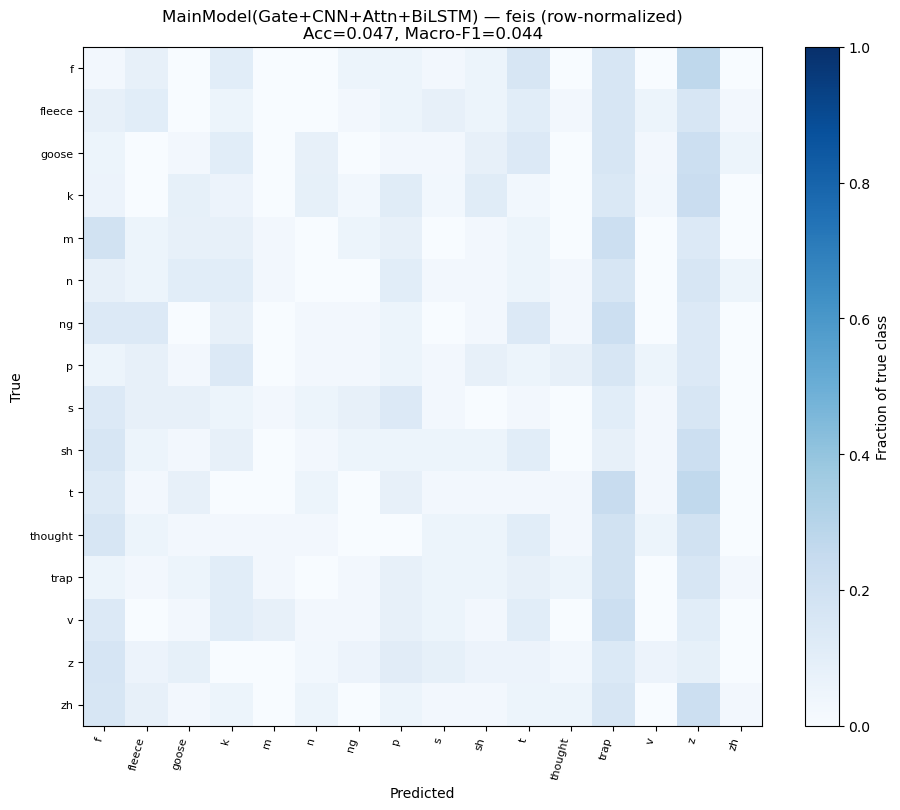

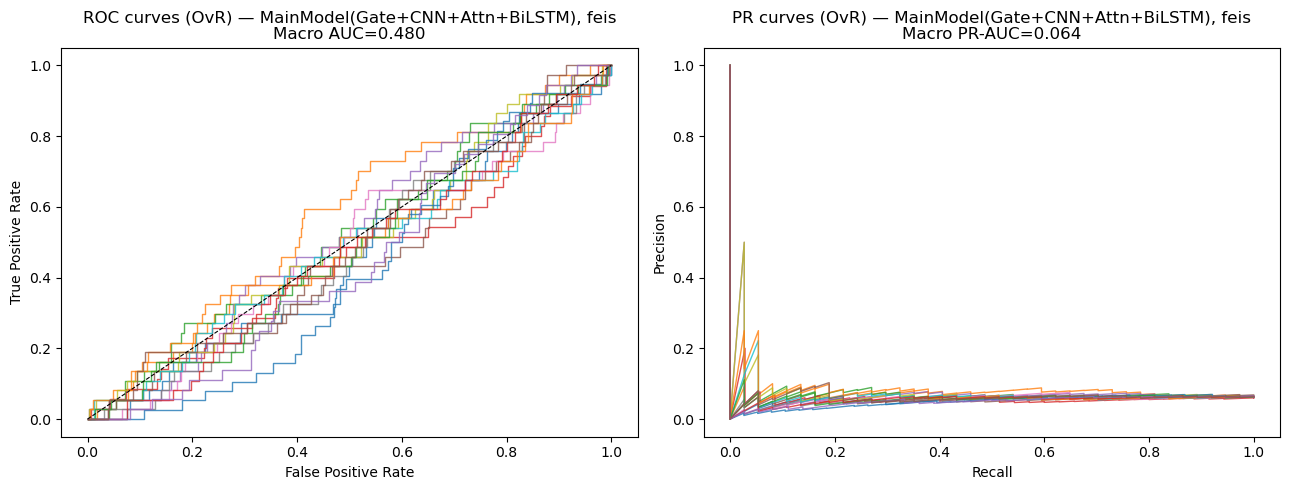

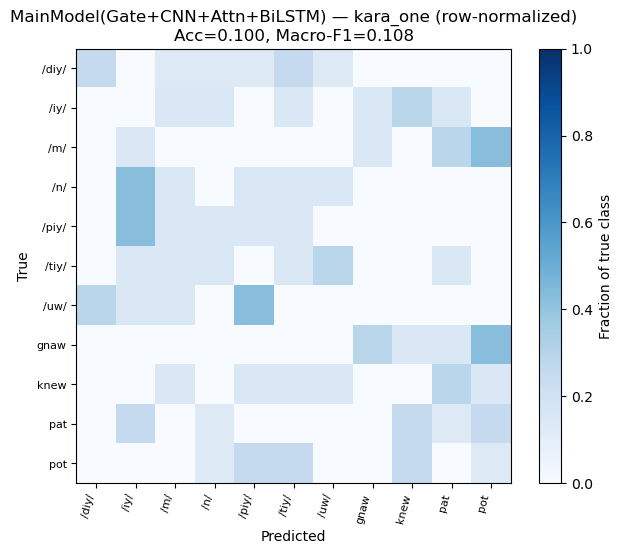

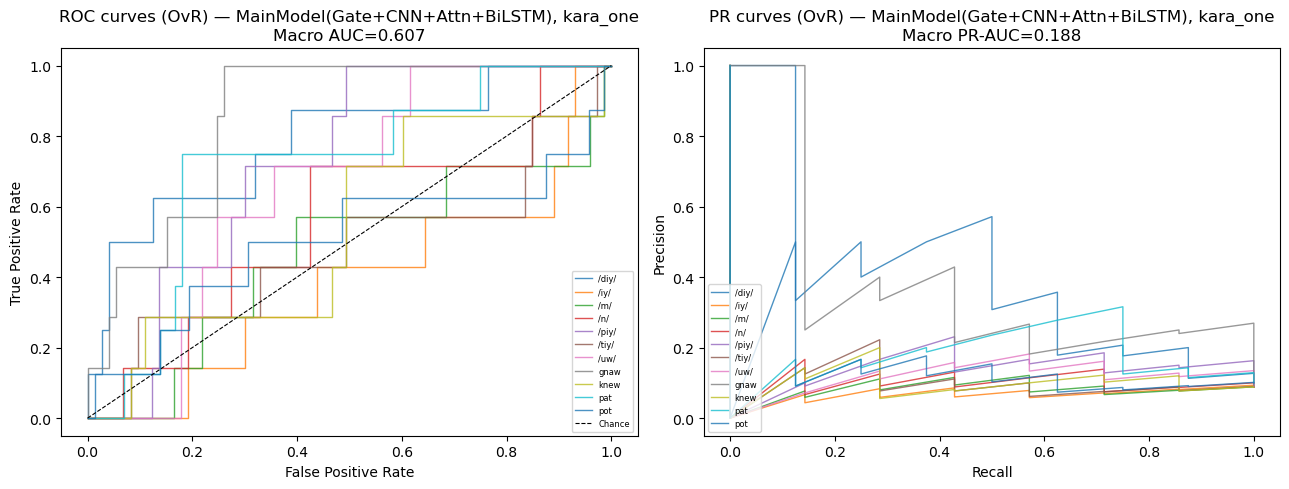

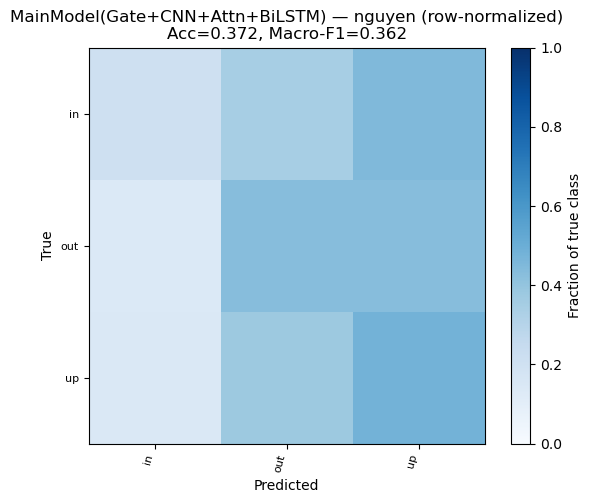

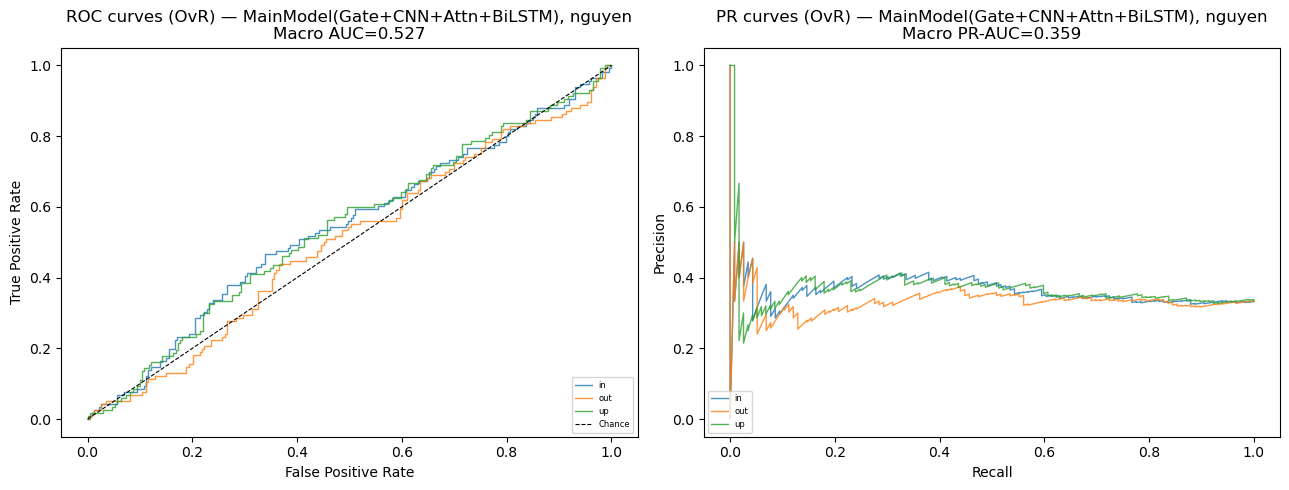

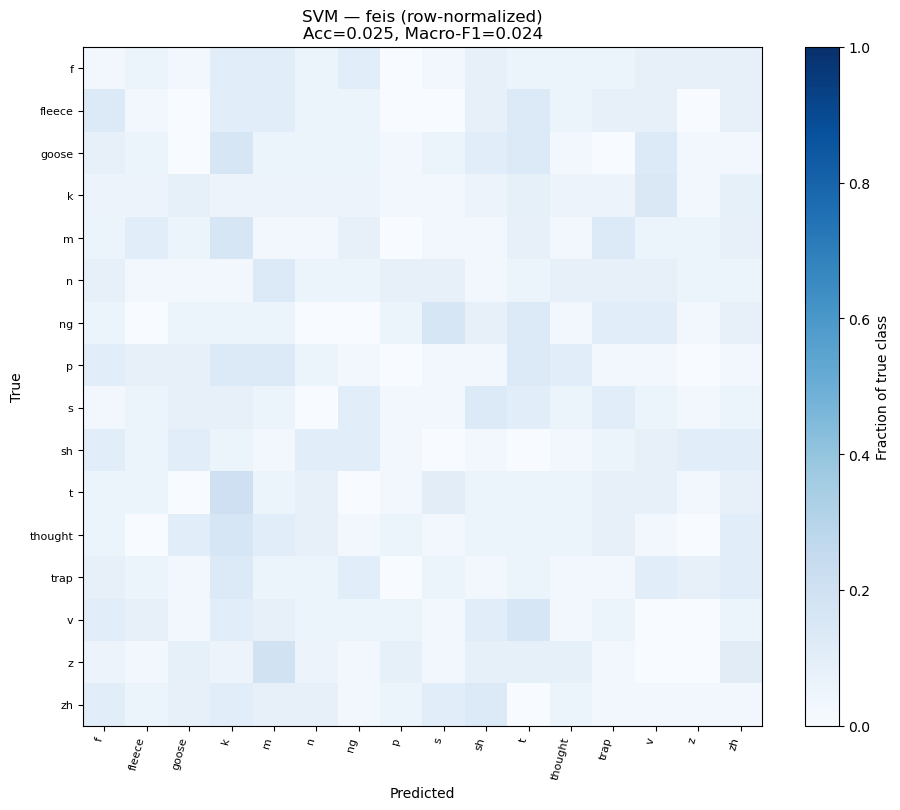

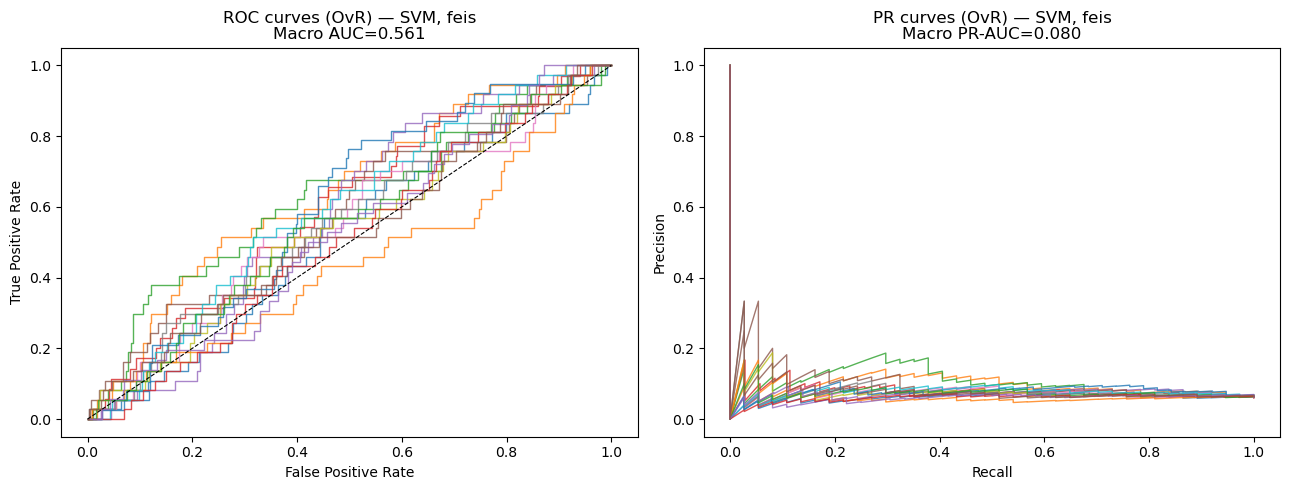

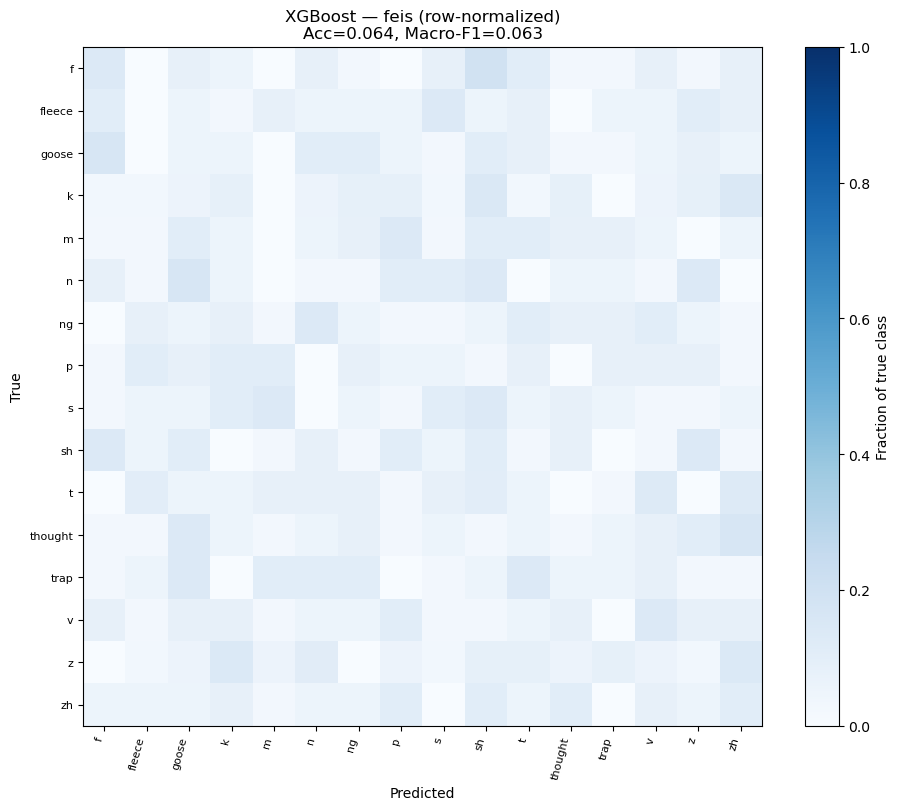

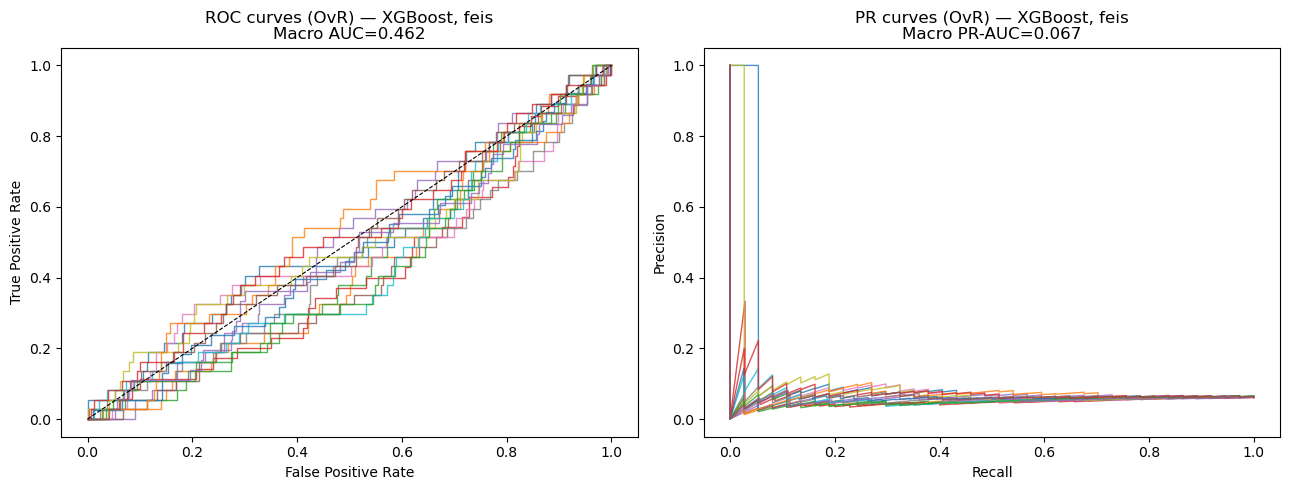

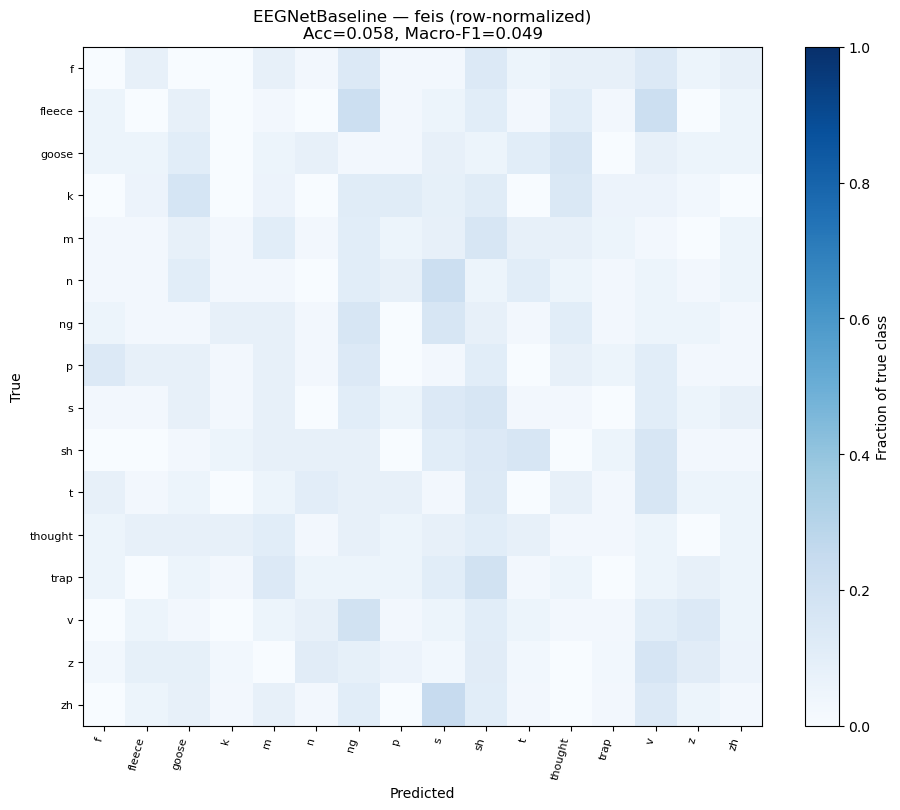

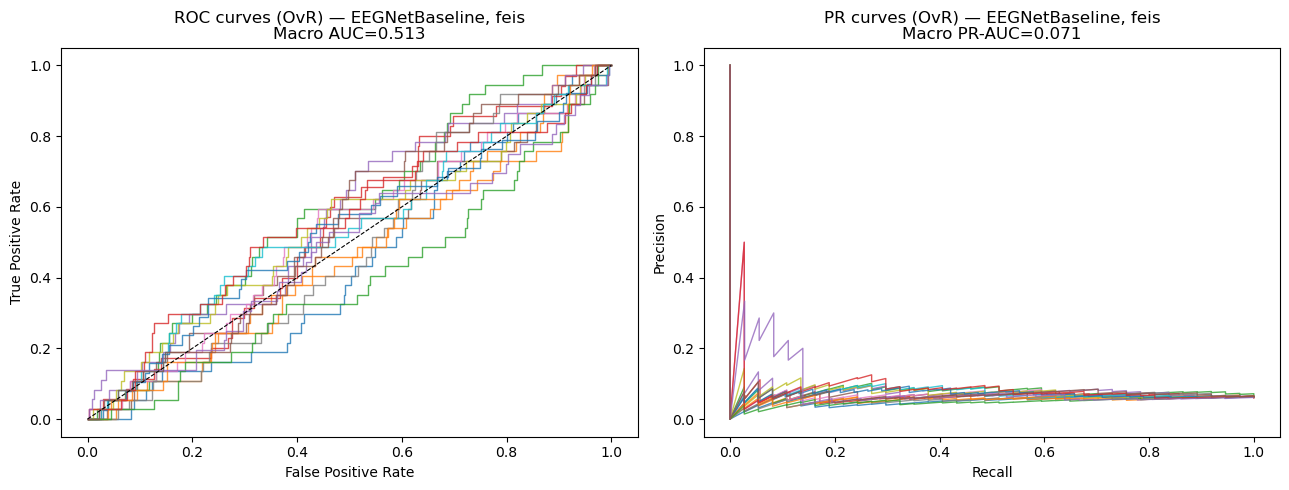

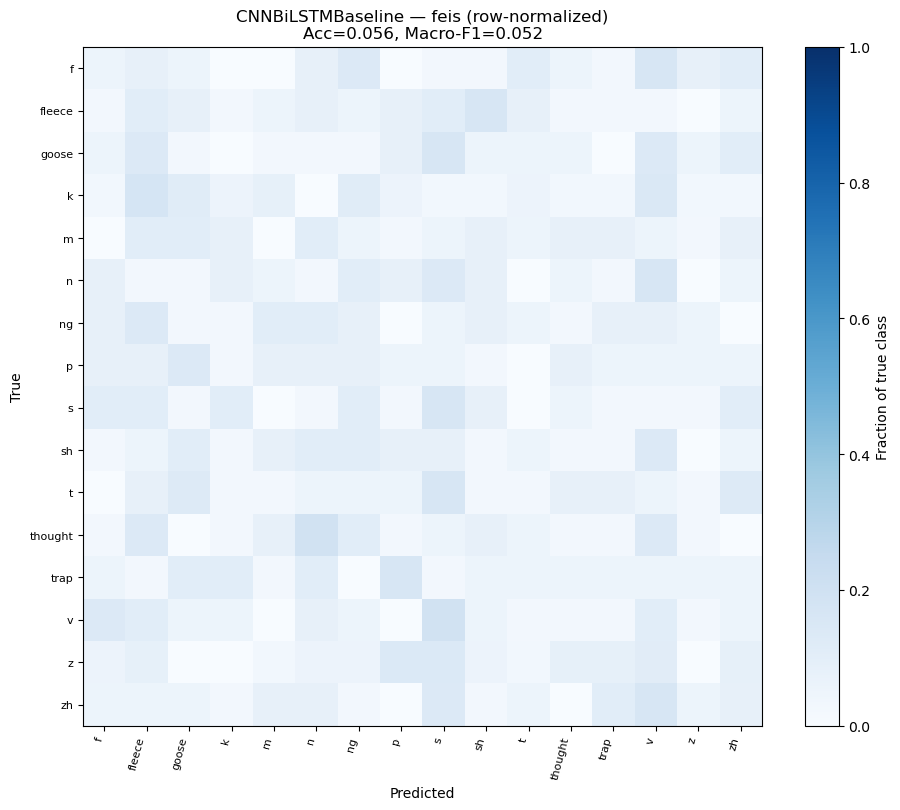

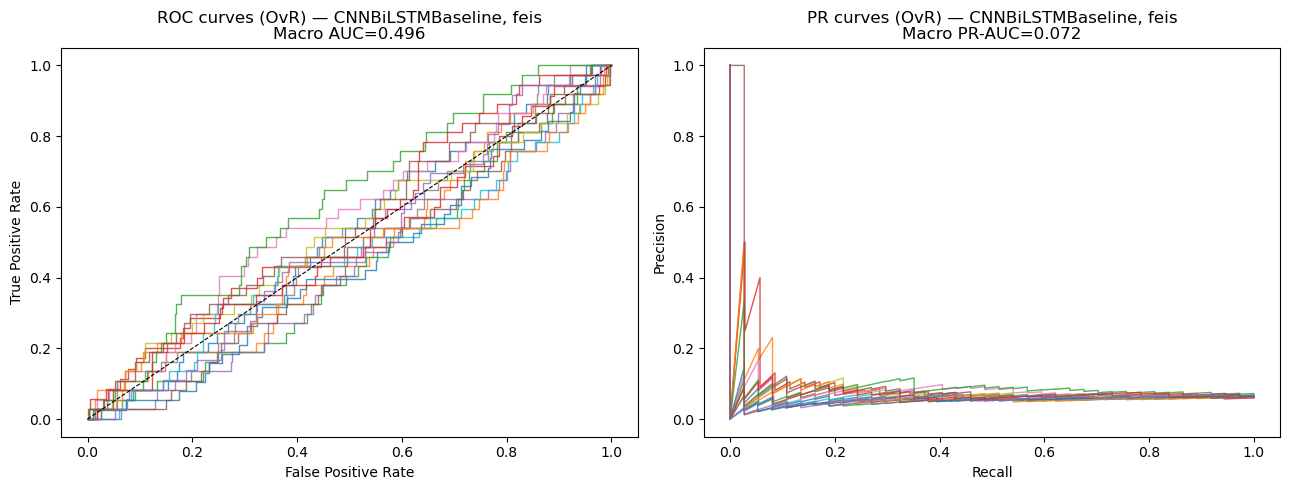

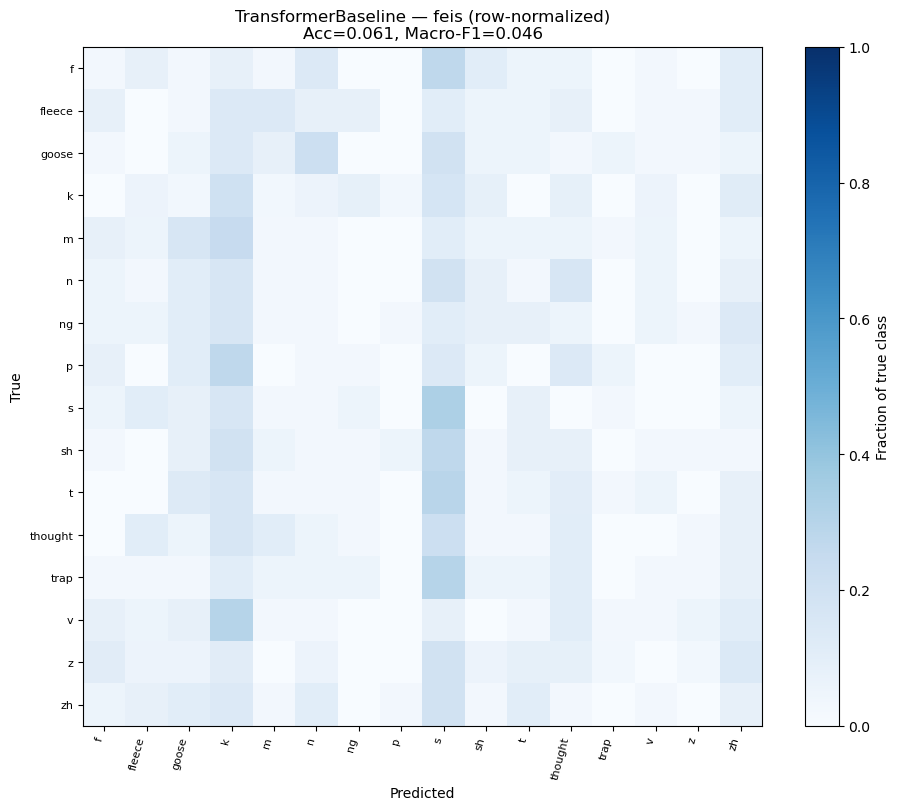

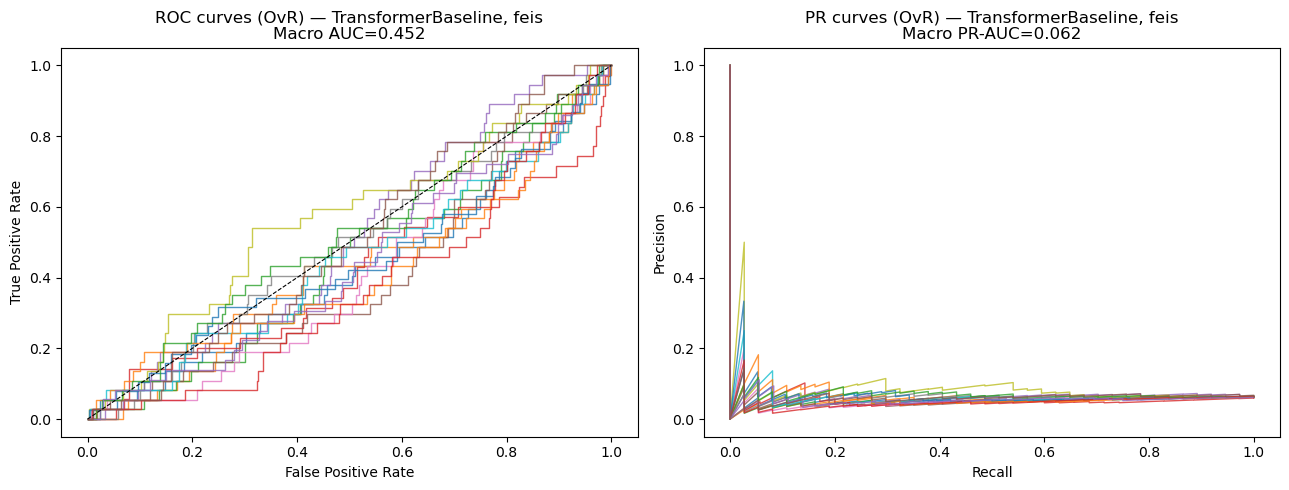

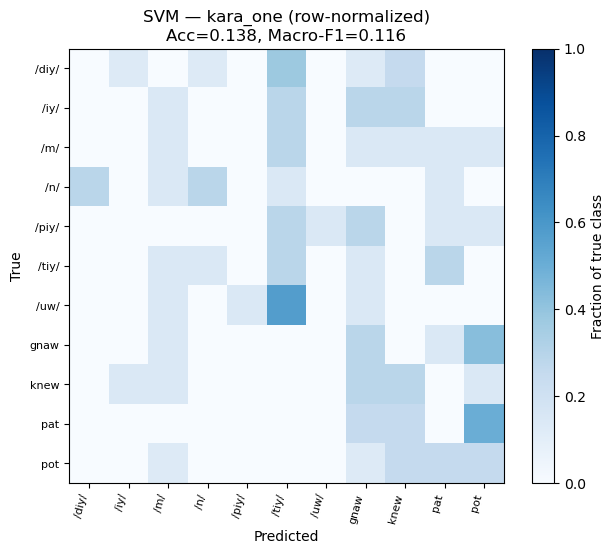

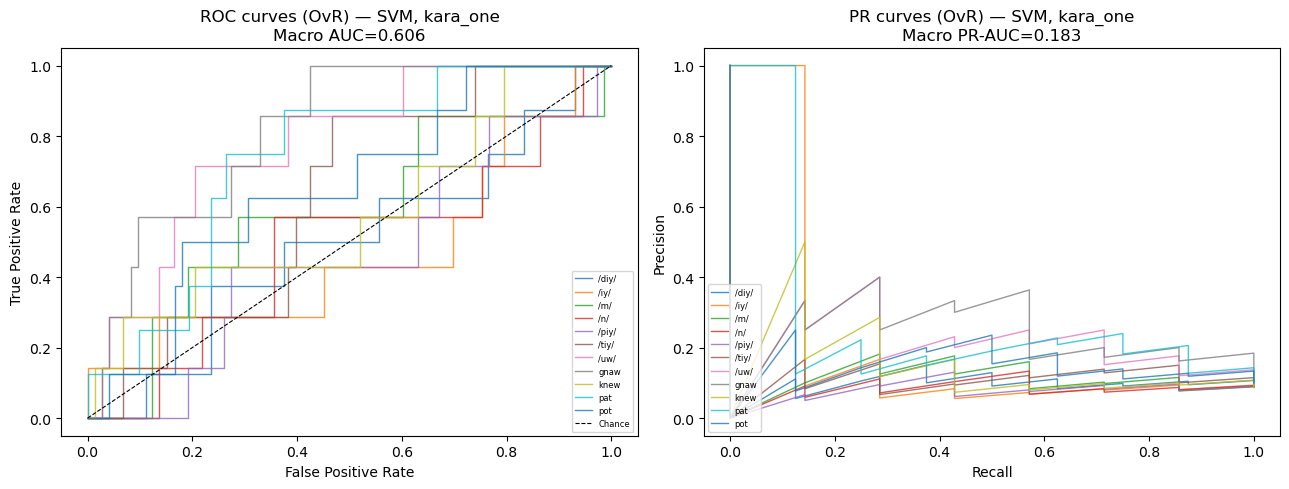

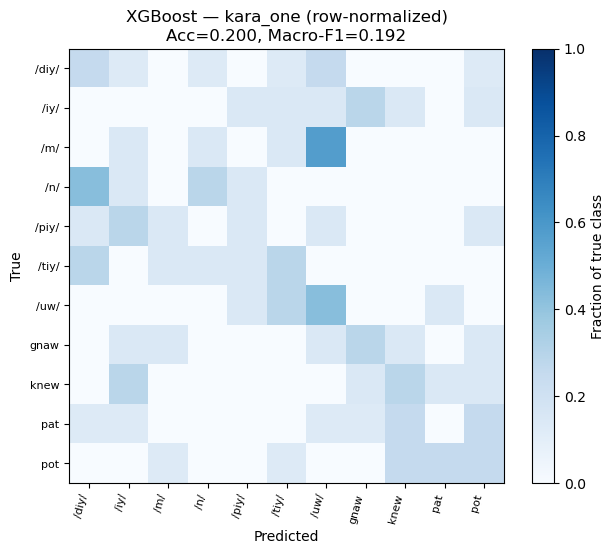

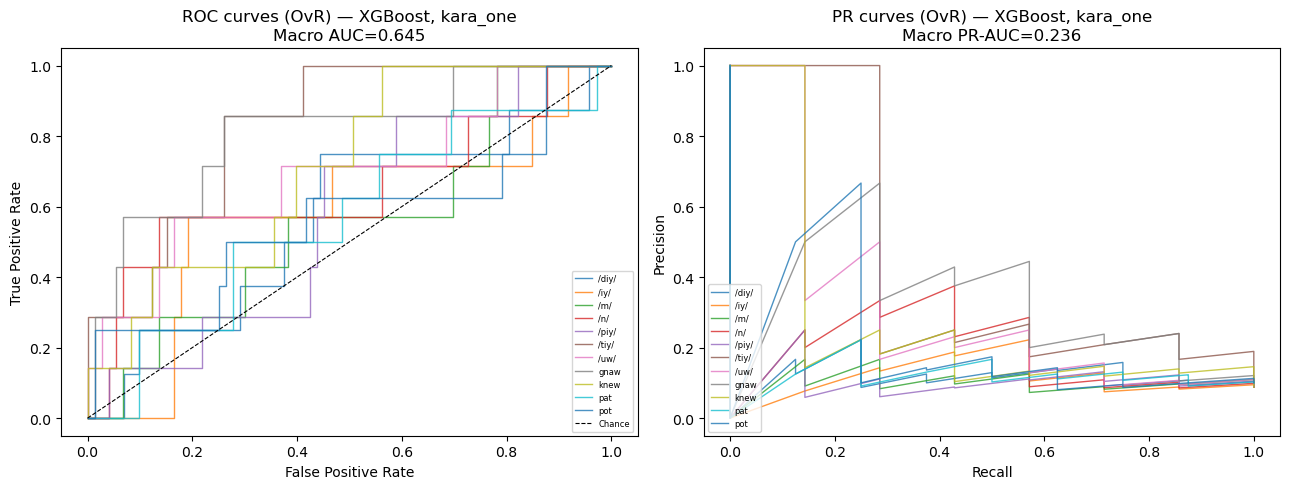

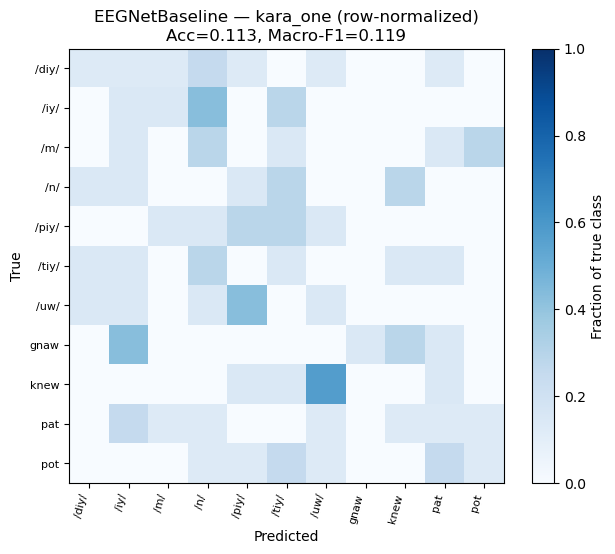

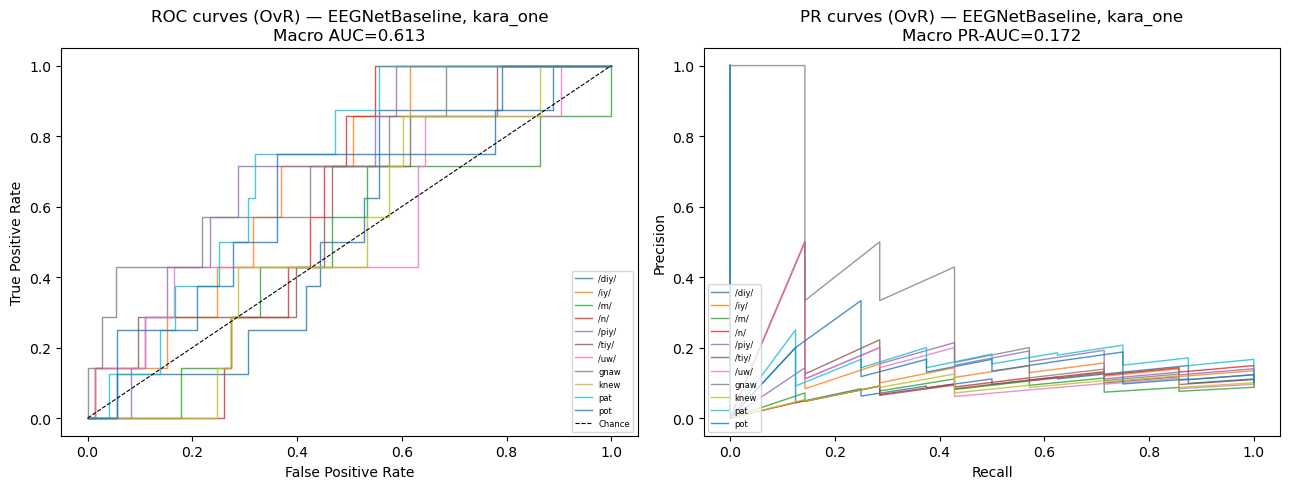

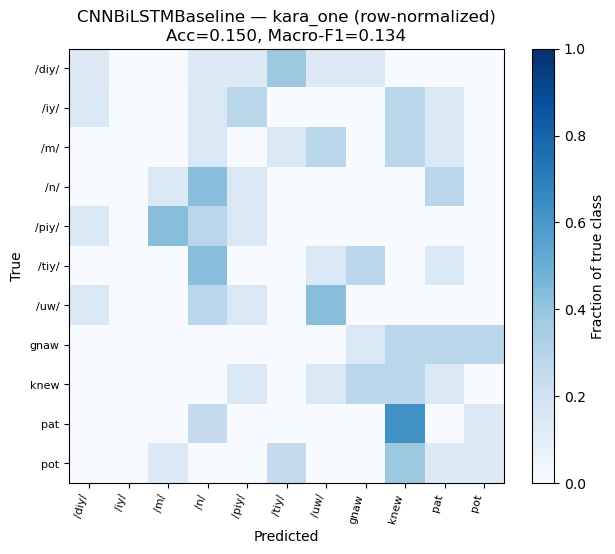

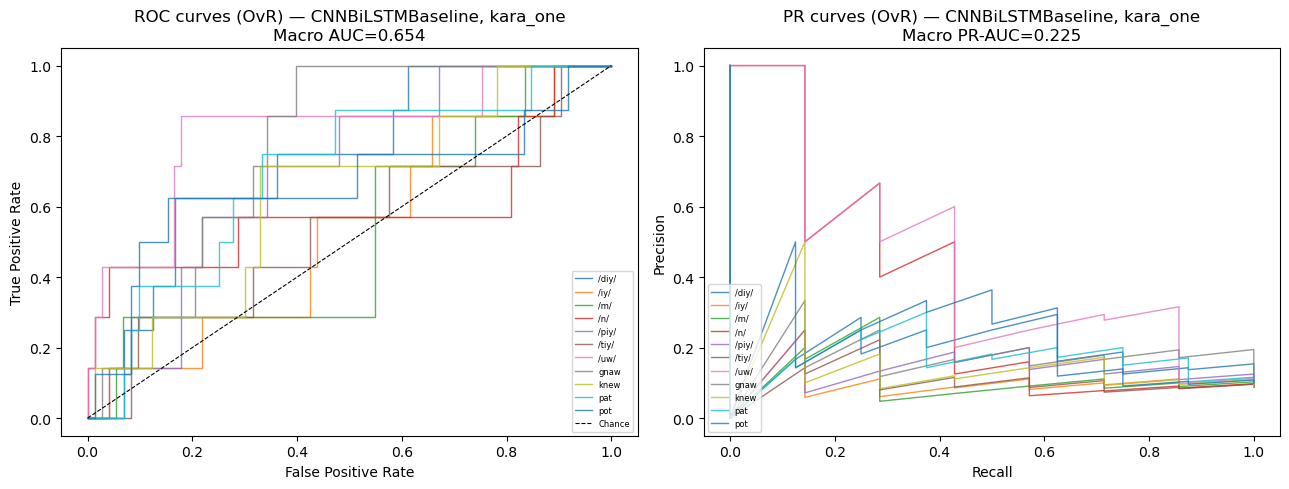

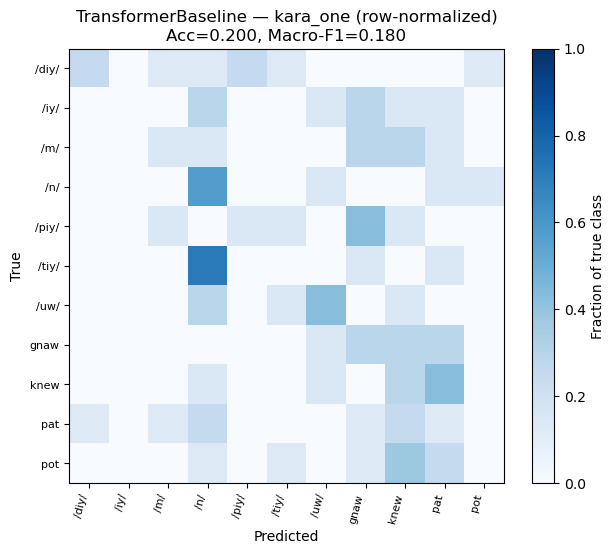

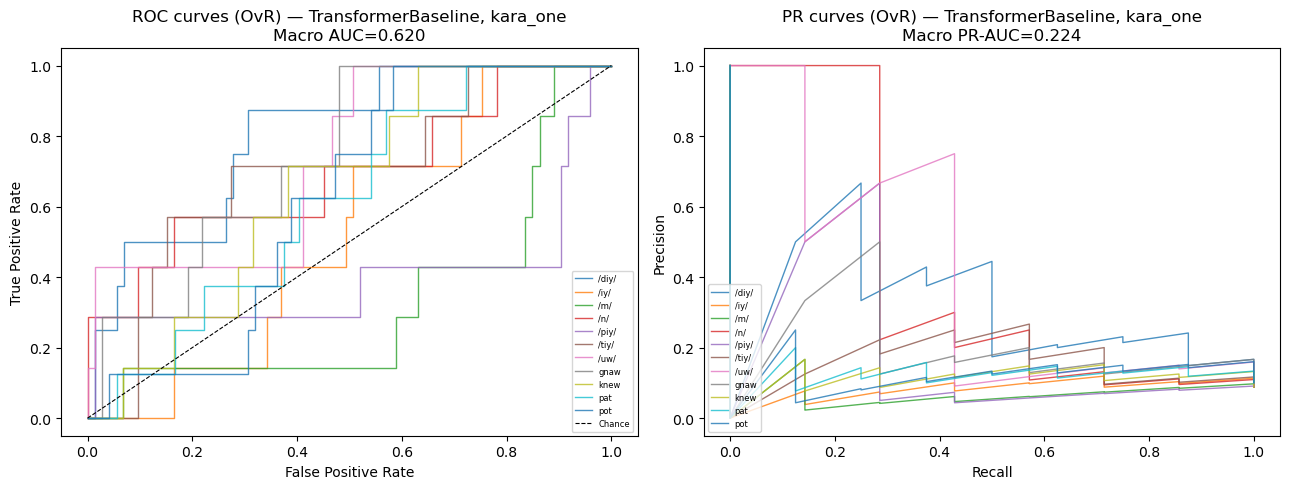

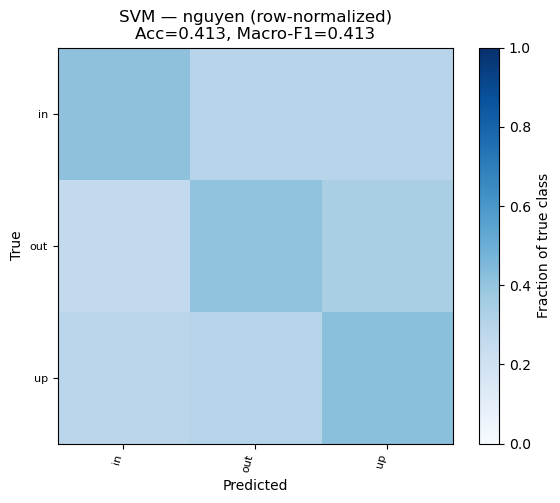

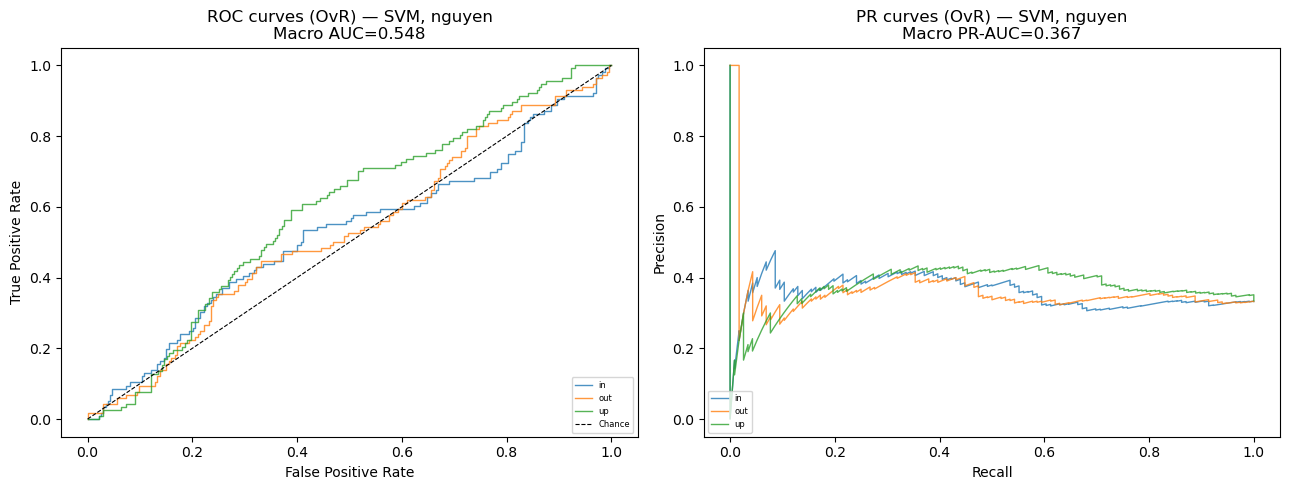

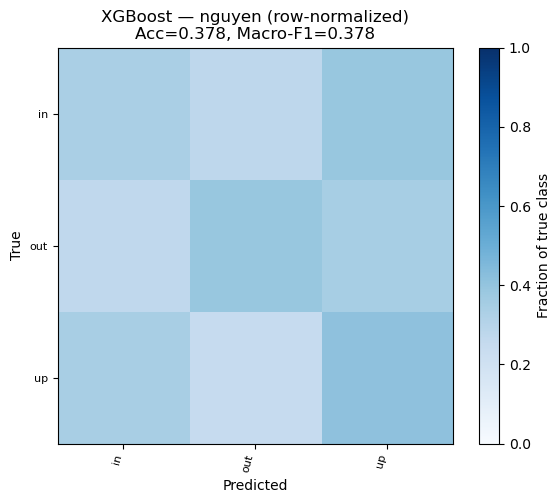

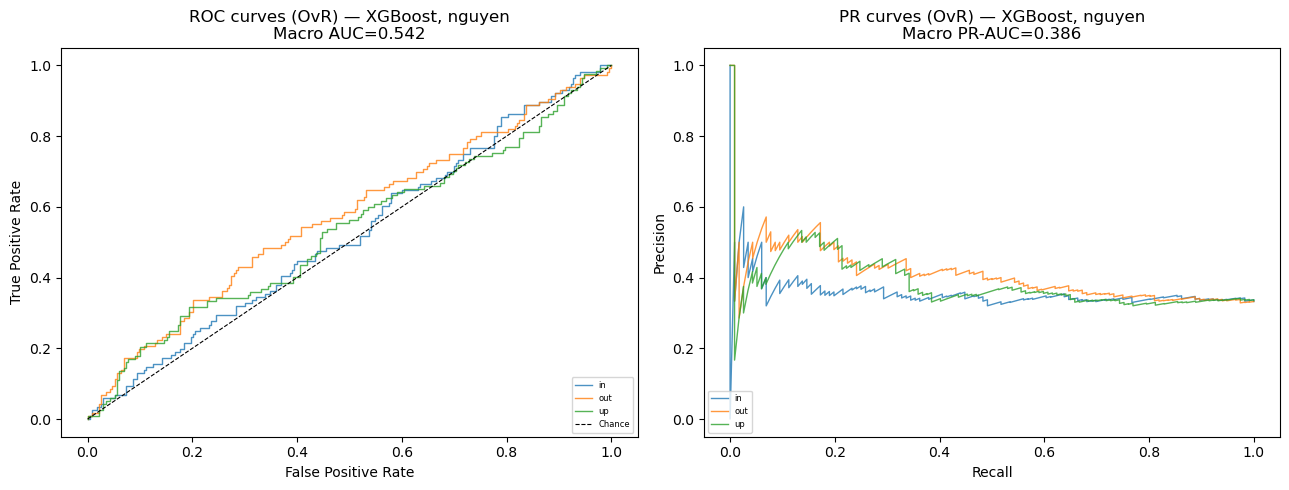

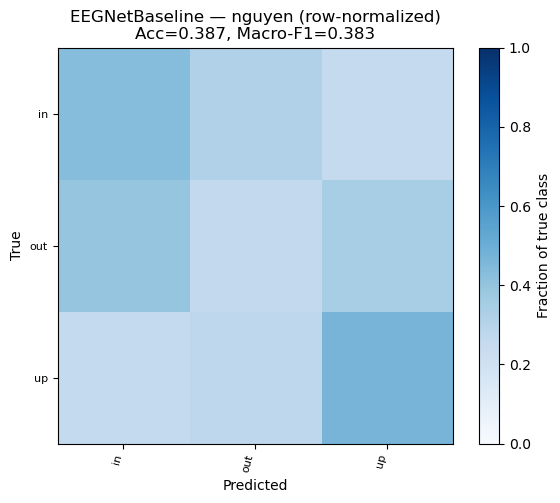

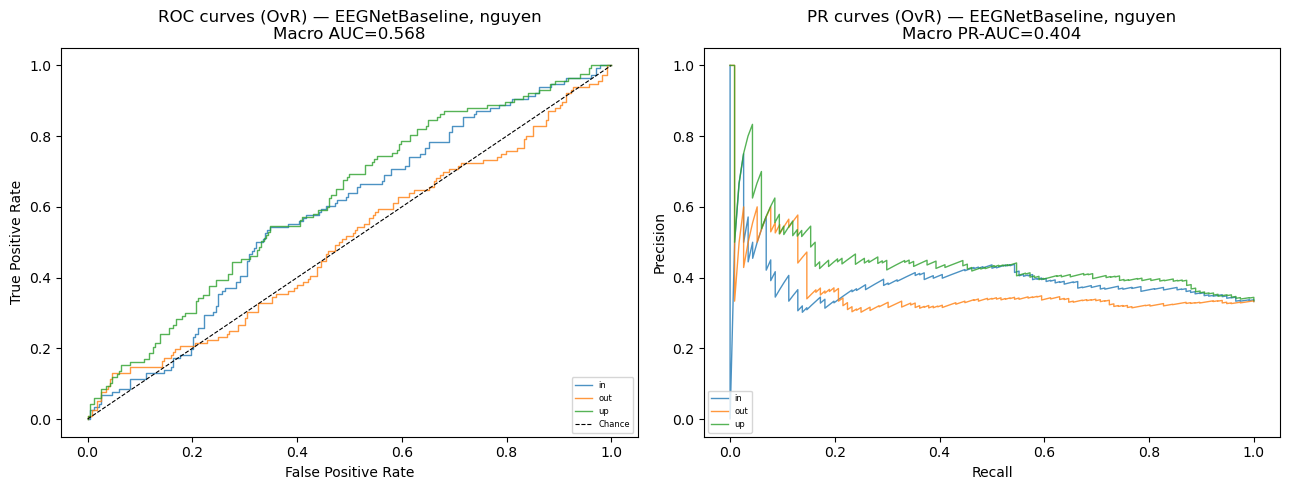

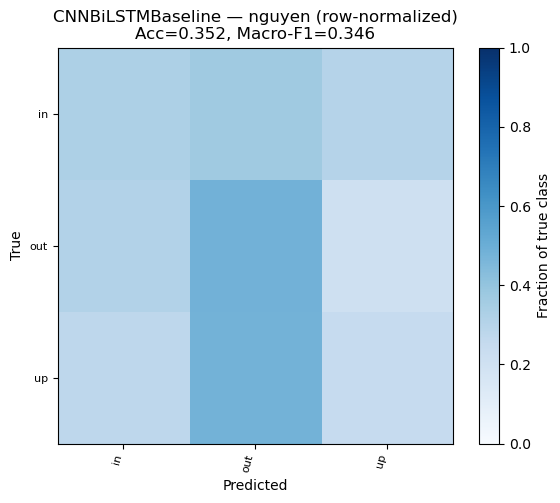

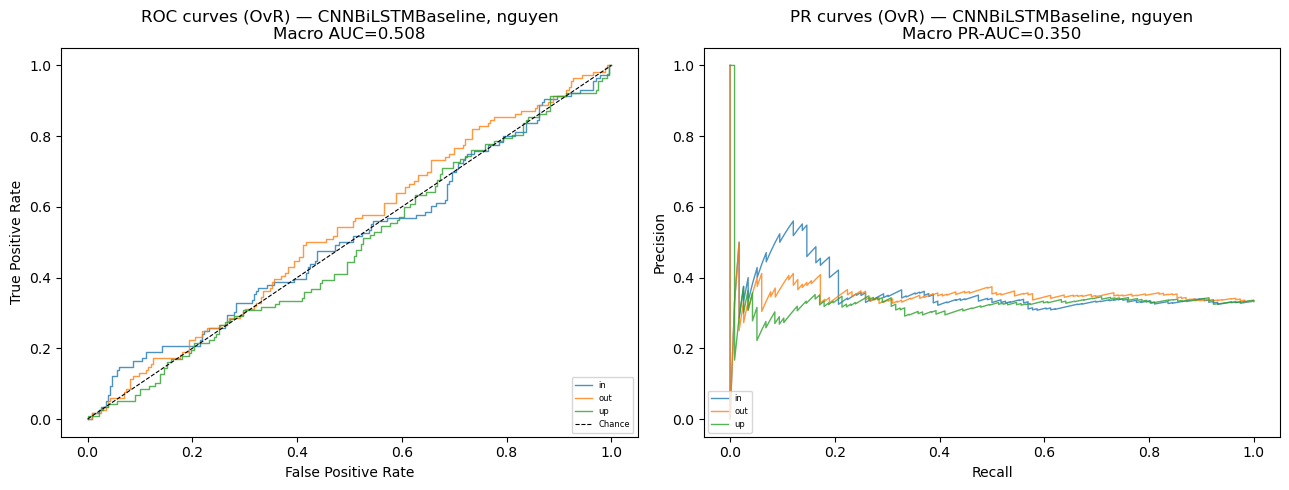

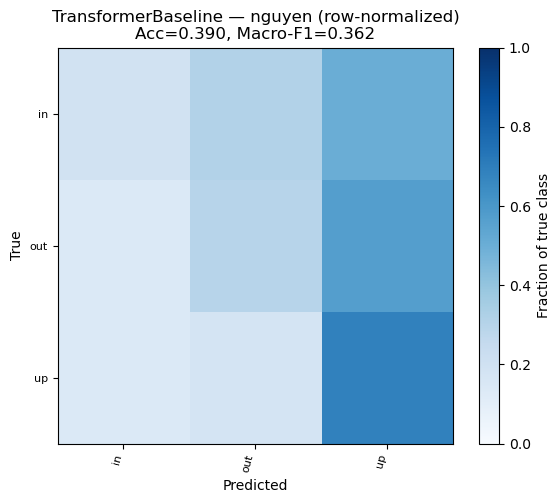

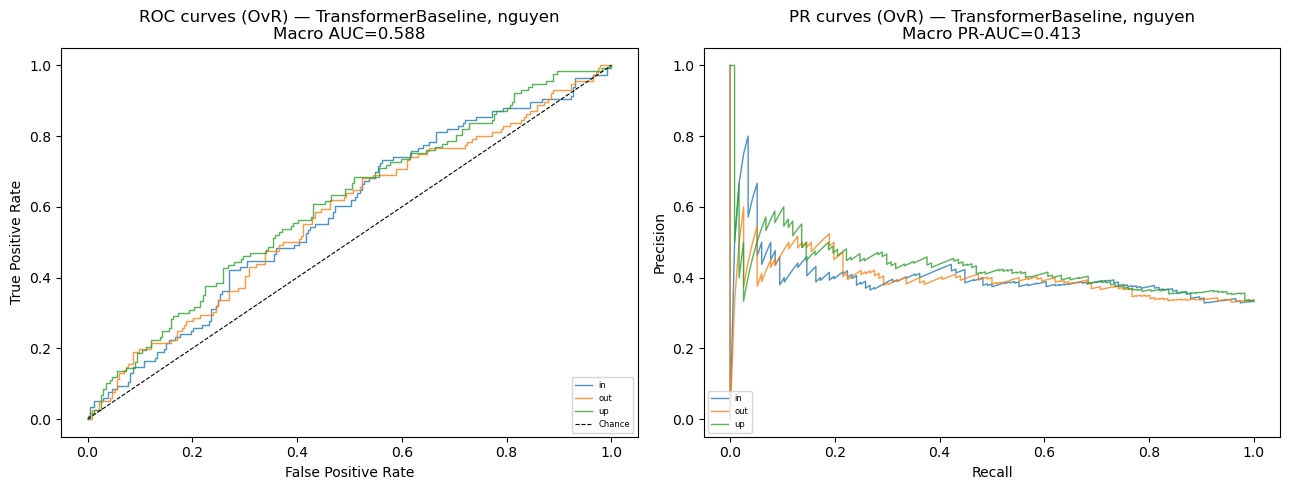

FULL EVALUATION (100 EPOCHS) — ACCURACY / MACRO-F1 / ROC-AUC BY MODEL × DATASET
                                accuracy                     f1           \
dataset                             feis kara_one nguyen   feis kara_one   
model                                                                      
CNNBiLSTMBaseline                  0.056    0.150  0.352  0.052    0.134   
EEGNetBaseline                     0.058    0.112  0.387  0.049    0.119   
MainModel(Gate+CNN+Attn+BiLSTM)    0.047    0.100  0.372  0.044    0.108   
SVM                                0.025    0.138  0.413  0.024    0.116   
TransformerBaseline                0.061    0.200  0.390  0.046    0.180   
XGBoost                            0.064    0.200  0.378  0.063    0.192   

                                       roc_auc                  
dataset                         nguyen    feis kara_one nguyen  
model                                                           
CNNBiLSTMBaseline                0.346  

In [90]:
# =============================================================================
# SECTION 13.6 — RUN FULL EVALUATION (main model + all baselines)
# =============================================================================

def run_full_evaluation(main_model: "ImaginedSpeechModel", split: Dict[str, pd.DataFrame],
                         baseline_raw_results: List[Dict[str, Any]]) -> pd.DataFrame:
    all_metrics = []

    # --- main model, per dataset -----------------------------------------------
    main_predictions = collect_model_predictions(main_model, split, preprocessed_harmonized_data)
    for dataset_name, result in main_predictions.items():
        result["n_params"] = count_model_params(main_model)
        result["gpu_mem_mb"] = measure_gpu_memory_mb(
            main_model, (1, CONFIG["channels"]["canonical_set_size"], TARGET_EPOCH_SAMPLES)
        )
        metrics = compute_full_metrics(result, label_encoders)
        all_metrics.append(metrics)
        plot_confusion_matrix(metrics)
        plot_roc_pr_curves(metrics)

    # --- baselines (already have y_true/y_pred/y_proba from Section 12) --------
    for result in baseline_raw_results:
        if result.get("skipped"):
            continue
        metrics = compute_full_metrics(result, label_encoders)
        all_metrics.append(metrics)
        plot_confusion_matrix(metrics)
        plot_roc_pr_curves(metrics)

    summary_rows = [{
        "dataset": m["dataset"], "model": m["model"],
        "accuracy": m["accuracy"], "precision": m["precision"], "recall": m["recall"],
        "f1": m["f1"], "roc_auc": m["roc_auc"], "pr_auc": m["pr_auc"],
        "n_train": m["n_train"], "n_test": m["n_test"],
        "infer_time_sec": m["infer_time_sec"],
        "n_params": m.get("n_params"), "gpu_mem_mb": m.get("gpu_mem_mb"),
    } for m in all_metrics if not m.get("metrics_skipped")]

    summary_df = pd.DataFrame(summary_rows)
    out_path = OUTPUT_DIRS["metrics"] / "full_evaluation_summary.csv"
    summary_df.to_csv(out_path, index=False)
    logger.info(f"Full evaluation summary saved to {out_path.resolve()}")

    return summary_df, all_metrics


evaluation_summary_df, all_evaluation_metrics = run_full_evaluation(
    sd_model_final, default_split, baseline_raw_results
)

print("=" * 100)
print("FULL EVALUATION (100 EPOCHS) — ACCURACY / MACRO-F1 / ROC-AUC BY MODEL × DATASET")
print("=" * 100)
print(evaluation_summary_df.pivot_table(
    index="model", columns="dataset", values=["accuracy", "f1", "roc_auc"]
).round(3))

In [91]:
# =============================================================================
# SECTION 13.7 — SANITY CHECK
# =============================================================================

def test_section13() -> None:
    assert not evaluation_summary_df.empty, "No evaluation results produced."
    assert "MainModel(Gate+CNN+Attn+BiLSTM)" in evaluation_summary_df["model"].unique(), \
        "Main model missing from evaluation summary."

    for _, row in evaluation_summary_df.iterrows():
        assert 0 <= row["accuracy"] <= 1
        assert 0 <= row["f1"] <= 1
        assert pd.isna(row["roc_auc"]) or 0 <= row["roc_auc"] <= 1

    assert (OUTPUT_DIRS["metrics"] / "full_evaluation_summary.csv").exists()
    assert len(list(OUTPUT_DIRS["confusion"].glob("*.png"))) > 0, "No confusion matrix figures saved."
    assert len(list(OUTPUT_DIRS["roc_pr"].glob("*.png"))) > 0, "No ROC/PR figures saved."

    print("All Section 13 checks passed.")
    print(f"  Model x dataset combinations evaluated: {len(evaluation_summary_df)}")
    print(f"  Confusion matrix figures saved: {len(list(OUTPUT_DIRS['confusion'].glob('*.png')))}")
    print(f"  ROC/PR figures saved: {len(list(OUTPUT_DIRS['roc_pr'].glob('*.png')))}")

test_section13()

All Section 13 checks passed.
  Model x dataset combinations evaluated: 18
  Confusion matrix figures saved: 18
  ROC/PR figures saved: 18


In [92]:
print(evaluation_summary_df.pivot_table(
    index="model", columns="dataset", values=["accuracy", "f1", "roc_auc"]
).round(3))

                                accuracy                     f1           \
dataset                             feis kara_one nguyen   feis kara_one   
model                                                                      
CNNBiLSTMBaseline                  0.056    0.150  0.352  0.052    0.134   
EEGNetBaseline                     0.058    0.112  0.387  0.049    0.119   
MainModel(Gate+CNN+Attn+BiLSTM)    0.047    0.100  0.372  0.044    0.108   
SVM                                0.025    0.138  0.413  0.024    0.116   
TransformerBaseline                0.061    0.200  0.390  0.046    0.180   
XGBoost                            0.064    0.200  0.378  0.063    0.192   

                                       roc_auc                  
dataset                         nguyen    feis kara_one nguyen  
model                                                           
CNNBiLSTMBaseline                0.346   0.496    0.654  0.508  
EEGNetBaseline                   0.383   0.513    0.613

In [93]:
# =============================================================================
# SECTION 14.1 — STATIC CHANNEL SELECTION METHODS
# =============================================================================

def static_region_mask(dataset_name: str, canonical_layout: Dict[str, Any],
                        region: str = "temporal_frontal") -> np.ndarray:
    named = canonical_layout["named_channel_display"]
    prefixes = ("F", "T", "FC", "FT")
    mask = np.zeros(canonical_layout["total_canonical_size"], dtype=np.float32)
    for i, name in enumerate(named):
        if any(name.upper().startswith(p) for p in prefixes) and not name.upper().startswith("FP"):
            mask[i] = 1.0
    n_named = len(named)
    n_generic = canonical_layout["generic_channel_slots"]
    if n_generic > 0:
        mask[n_named:n_named + n_generic] = 1.0
        logger.warning("[Static region] Nguyen's generic channels have no anatomical "
                        "identity — all included by necessity, not selected by region.")
    return mask


def relieff_mask(dataset_name: str, split: Dict[str, pd.DataFrame],
                  canonical_layout: Dict[str, Any], top_k_fraction: float = 0.5) -> np.ndarray:
    train_df = split["train"][split["train"]["dataset"] == dataset_name]
    canonical_size = canonical_layout["total_canonical_size"]

    X, y = [], []
    for _, row in train_df.sample(min(len(train_df), 300), random_state=GLOBAL_SEED).iterrows():
        d = preprocessed_harmonized_data[dataset_name][row["subject"]]
        trial = d["harmonized_trials"][row["trial_idx"]]
        X.append(trial.mean(axis=1))
        y.append(row["label_id"])
    X, y = np.stack(X), np.array(y)

    real_mask = preprocessed_harmonized_data[dataset_name][train_df.iloc[0]["subject"]]["channel_mask"]
    active_idx = np.where(real_mask > 0)[0]

    class_means = np.array([X[y == c][:, active_idx].mean(axis=0) for c in np.unique(y)])
    between_class_var = class_means.var(axis=0)
    within_class_var = np.array([X[y == c][:, active_idx].var(axis=0) for c in np.unique(y)]).mean(axis=0) + 1e-8
    relevance = between_class_var / within_class_var

    k = max(1, int(len(active_idx) * top_k_fraction))
    top_local_idx = np.argsort(relevance)[-k:]
    selected_canonical_idx = active_idx[top_local_idx]

    mask = np.zeros(canonical_size, dtype=np.float32)
    mask[selected_canonical_idx] = 1.0
    return mask


def nca_mask(dataset_name: str, split: Dict[str, pd.DataFrame],
             canonical_layout: Dict[str, Any], top_k_fraction: float = 0.5) -> np.ndarray:
    from sklearn.neighbors import NeighborhoodComponentsAnalysis

    train_df = split["train"][split["train"]["dataset"] == dataset_name]
    canonical_size = canonical_layout["total_canonical_size"]

    X, y = [], []
    for _, row in train_df.sample(min(len(train_df), 300), random_state=GLOBAL_SEED).iterrows():
        d = preprocessed_harmonized_data[dataset_name][row["subject"]]
        trial = d["harmonized_trials"][row["trial_idx"]]
        X.append(trial.mean(axis=1))
        y.append(row["label_id"])
    X, y = np.stack(X), np.array(y)

    real_mask = preprocessed_harmonized_data[dataset_name][train_df.iloc[0]["subject"]]["channel_mask"]
    active_idx = np.where(real_mask > 0)[0]

    try:
        nca = NeighborhoodComponentsAnalysis(n_components=min(10, len(active_idx)),
                                              random_state=GLOBAL_SEED, max_iter=50)
        nca.fit(X[:, active_idx], y)
        importance = np.abs(nca.components_).mean(axis=0)
    except Exception as e:
        logger.warning(f"[NCA] fit failed for '{dataset_name}' ({e}) — falling back to "
                        f"uniform importance (equivalent to random selection).")
        importance = np.ones(len(active_idx))

    k = max(1, int(len(active_idx) * top_k_fraction))
    top_local_idx = np.argsort(importance)[-k:]
    selected_canonical_idx = active_idx[top_local_idx]

    mask = np.zeros(canonical_size, dtype=np.float32)
    mask[selected_canonical_idx] = 1.0
    return mask

print("static_region_mask, relieff_mask, nca_mask all defined:",
      all(f in dir() for f in ["static_region_mask", "relieff_mask", "nca_mask"]))

static_region_mask, relieff_mask, nca_mask all defined: False


In [94]:
# =============================================================================
# SECTION 14.2 — FIXED-MASK MODEL VARIANT (for No-Gate / Static / ReliefF / NCA)
# =============================================================================

class FixedMaskModel(nn.Module):
    """Same backbone + head structure as ImaginedSpeechModel, but replaces the
    LearnedChannelGate with a FIXED, precomputed binary mask (no learning, no
    per-trial adaptivity) — isolates the gate's contribution.

    fixed_mask == None reproduces "No Gate" (all real channels pass through
    unweighted, i.e. mask == channel_mask itself, no additional selection).
    """

    def __init__(self, dataset_name_to_id: Dict[str, int],
                 num_classes_per_dataset: Dict[str, int],
                 fixed_masks: Optional[Dict[str, np.ndarray]] = None):
        super().__init__()
        self.dataset_name_to_id = dataset_name_to_id
        self.id_to_dataset_name = {v: k for k, v in dataset_name_to_id.items()}
        self.fixed_masks = {
            name: torch.tensor(m, dtype=torch.float32) if m is not None else None
            for name, m in (fixed_masks or {}).items()
        }
        self.backbone = SharedBackbone()
        self.heads = nn.ModuleDict({
            name: DatasetSpecificHead(self.backbone.fusion_dim, num_classes_per_dataset[name])
            for name in dataset_name_to_id
        })

    def forward_single_dataset(self, eeg: torch.Tensor, channel_mask: torch.Tensor,
                                subject_id: torch.Tensor, dataset_id: torch.Tensor,
                                dataset_name: str) -> torch.Tensor:
        fixed = self.fixed_masks.get(dataset_name)
        if fixed is not None:
            effective_mask = channel_mask * fixed.to(eeg.device)  # intersect with real channels
        else:
            effective_mask = channel_mask  # "No Gate": pass all real channels unweighted

        gated_eeg = eeg * effective_mask.unsqueeze(-1)
        features = self.backbone(gated_eeg)
        return self.heads[dataset_name](features)

In [95]:
# =============================================================================
# SECTION 14.3 — BACKBONE ABLATION VARIANTS (w/o Attention, w/o BiLSTM, w/o Fusion)
# =============================================================================
# Each variant still uses the real LearnedChannelGate (Section 7) — this axis
# isolates backbone components, not the gate, so the gate is held constant
# and set to its learned/trained behavior in every variant here.

class BackboneNoAttention(nn.Module):
    """CNN -> BiLSTM -> Fusion, skipping the attention block entirely."""
    def __init__(self):
        super().__init__()
        self.cnn = TemporalCNNBackbone()
        self.bilstm = BiLSTMBlock()
        self.fusion = FeatureFusion()
        self.fusion_dim = self.fusion.fusion_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cnn_out = self.cnn(x)
        lstm_out = self.bilstm(cnn_out)          # BiLSTM fed CNN output directly
        return self.fusion(cnn_out, lstm_out)     # fusion's "attn_out" slot filled by cnn_out


class BackboneNoBiLSTM(nn.Module):
    """CNN -> Attention -> Fusion, skipping BiLSTM. The fusion's second input
    (normally the BiLSTM branch) is filled by the attention output itself, so
    FeatureFusion must be sized for embed_dim on BOTH branches here, not the
    default (embed_dim + 2*hidden_size) sizing used by the full model.
    """
    def __init__(self):
        super().__init__()
        self.cnn = TemporalCNNBackbone()
        self.attention = TemporalSelfAttention()
        embed_dim = CONFIG["attention"]["embed_dim"]
        self.fusion = FeatureFusion(
            embed_dim=embed_dim,
            lstm_output_dim=embed_dim,  # stand-in branch is embed_dim, not 2*hidden_size
        )
        self.fusion_dim = self.fusion.fusion_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cnn_out = self.cnn(x)
        attn_out = self.attention(cnn_out)
        lstm_like = attn_out.transpose(1, 2)      # (B, T', embed_dim) stand-in for BiLSTM's output
        return self.fusion(attn_out, lstm_like)


class BackboneNoFusion(nn.Module):
    """CNN -> Attention -> BiLSTM -> simple GAP + Linear (no learned fusion FC,
    just BiLSTM's final pooled output projected directly)."""
    def __init__(self):
        super().__init__()
        self.cnn = TemporalCNNBackbone()
        self.attention = TemporalSelfAttention()
        self.bilstm = BiLSTMBlock()
        self.fusion_dim = CONFIG["bilstm"]["hidden_size"] * 2  # no FC projection

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cnn_out = self.cnn(x)
        attn_out = self.attention(cnn_out)
        lstm_out = self.bilstm(attn_out)
        return lstm_out.mean(dim=1)                # GAP only, no fusion FC layer


class GatedVariantModel(nn.Module):
    """Wraps the real LearnedChannelGate (Section 7) around any backbone
    variant class from this cell, producing a full trainable model for the
    backbone ablation axis."""

    def __init__(self, backbone_cls: type, dataset_name_to_id: Dict[str, int],
                 num_classes_per_dataset: Dict[str, int], n_subjects: int, n_datasets: int):
        super().__init__()
        self.dataset_name_to_id = dataset_name_to_id
        self.id_to_dataset_name = {v: k for k, v in dataset_name_to_id.items()}
        self.gate = LearnedChannelGate(
            canonical_channels=CONFIG["channels"]["canonical_set_size"],
            n_subjects=n_subjects, n_datasets=n_datasets,
        )
        self.backbone = backbone_cls()
        self.heads = nn.ModuleDict({
            name: DatasetSpecificHead(self.backbone.fusion_dim, num_classes_per_dataset[name])
            for name in dataset_name_to_id
        })

    def forward_single_dataset(self, eeg, channel_mask, subject_id, dataset_id, dataset_name):
        gated_eeg, _ = self.gate(eeg, channel_mask, subject_id, dataset_id)
        features = self.backbone(gated_eeg)
        return self.heads[dataset_name](features)

In [96]:
# =============================================================================
# SECTION 14.4 — GENERIC ABLATION TRAINER
# =============================================================================

def train_ablation_variant(model: nn.Module, dataset_name: str, split: Dict[str, pd.DataFrame],
                            epochs: int, batch_size: int = CONFIG["training"]["batch_size"]
                            ) -> Dict[str, Any]:
    """Trains any model exposing forward_single_dataset(eeg, mask, subj, ds, name)
    on one dataset, returns the same result shape as Sections 12/13 for
    consistent downstream metrics computation.
    """
    train_df = split["train"][split["train"]["dataset"] == dataset_name]
    test_df = split["test"][split["test"]["dataset"] == dataset_name]
    if train_df.empty or test_df.empty:
        return {"dataset": dataset_name, "skipped": True}

    ds_train = ImaginedSpeechDataset(train_df, preprocessed_harmonized_data,
                                       dataset_name_to_id, subject_name_to_id, augment=True)
    ds_test = ImaginedSpeechDataset(test_df, preprocessed_harmonized_data,
                                      dataset_name_to_id, subject_name_to_id, augment=False)
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                               worker_init_fn=seed_worker, generator=dataloader_generator)
    test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

    model = model.to(DEVICE)
    weight = class_weights[dataset_name].to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["training"]["learning_rate"],
                                   weight_decay=CONFIG["training"]["weight_decay"])

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            eeg = batch["eeg"].to(DEVICE); mask = batch["channel_mask"].to(DEVICE)
            subj_id = batch["subject_id"].to(DEVICE); ds_id = batch["dataset_id"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            optimizer.zero_grad()
            logits = model.forward_single_dataset(eeg, mask, subj_id, ds_id, dataset_name)
            loss = F.cross_entropy(logits, labels, weight=weight,
                                    label_smoothing=CONFIG["training"]["label_smoothing"])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["training"]["grad_clip_norm"])
            optimizer.step()
    train_time = time.time() - t0

    model.eval()
    all_preds, all_labels, all_proba = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for batch in test_loader:
            eeg = batch["eeg"].to(DEVICE); mask = batch["channel_mask"].to(DEVICE)
            subj_id = batch["subject_id"].to(DEVICE); ds_id = batch["dataset_id"].to(DEVICE)
            logits = model.forward_single_dataset(eeg, mask, subj_id, ds_id, dataset_name)
            proba = F.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(dim=1).cpu().tolist())
            all_proba.extend(proba.cpu().numpy())
            all_labels.extend(batch["label"].tolist())
    infer_time = time.time() - t0

    return {
        "dataset": dataset_name, "skipped": False,
        "y_true": np.array(all_labels), "y_pred": np.array(all_preds), "y_proba": np.stack(all_proba),
        "train_time_sec": train_time, "infer_time_sec": infer_time,
        "n_train": len(train_df), "n_test": len(test_df),
    }

In [97]:
# =============================================================================
# SECTION 14.5 (final) — CHANNEL SELECTION ABLATION (100 epochs)
# =============================================================================

ABLATION_EPOCHS = BASELINE_EPOCHS  # 100, inherited automatically

def run_channel_selection_ablation_final(split, epochs=ABLATION_EPOCHS):
    results = []
    active_datasets = [name for name in dataset_name_to_id if
                        not split["train"][split["train"]["dataset"] == name].empty]

    for dataset_name in active_datasets:
        logger.info(f"[Ablation: channel selection] '{dataset_name}'...")
        variants = {
            "No Gate": None,
            "Static Region": static_region_mask(dataset_name, canonical_layout),
            "ReliefF": relieff_mask(dataset_name, default_split, canonical_layout),
            "NCA": nca_mask(dataset_name, default_split, canonical_layout),
        }
        for variant_name, mask in variants.items():
            model = FixedMaskModel(
                dataset_name_to_id, num_classes_per_dataset,
                fixed_masks={dataset_name: mask} if mask is not None else {},
            )
            result = train_ablation_variant(model, dataset_name, split, epochs)
            result["model"] = f"ChannelSelect[{variant_name}]"
            results.append(result)

        gate_result = collect_model_predictions(
            sd_model_final, split, preprocessed_harmonized_data
        ).get(dataset_name)
        if gate_result:
            gate_result = {**gate_result, "model": "ChannelSelect[Learned Adaptive Gate]"}
            results.append(gate_result)

    metrics_list = [compute_full_metrics(r, label_encoders) for r in results if not r.get("skipped")]
    summary_df = pd.DataFrame([{
        "dataset": m["dataset"], "model": m["model"], "accuracy": m["accuracy"],
        "f1": m["f1"], "roc_auc": m["roc_auc"],
    } for m in metrics_list])

    out_path = OUTPUT_DIRS["ablation"] / "channel_selection_ablation_final.csv"
    summary_df.to_csv(out_path, index=False)
    return summary_df


channel_ablation_df = run_channel_selection_ablation_final(default_split, epochs=ABLATION_EPOCHS)
print(channel_ablation_df.pivot(index="model", columns="dataset", values="accuracy").round(3))

2026-09-08 10:01:18 | WARNING  | bci_project | [Static region] Nguyen's generic channels have no anatomical identity — all included by necessity, not selected by region.
2026-09-08 10:17:20 | WARNING  | bci_project | [Static region] Nguyen's generic channels have no anatomical identity — all included by necessity, not selected by region.
2026-09-08 10:20:34 | WARNING  | bci_project | [Static region] Nguyen's generic channels have no anatomical identity — all included by necessity, not selected by region.
dataset                                feis  kara_one  nguyen
model                                                        
ChannelSelect[Learned Adaptive Gate]  0.047     0.100   0.372
ChannelSelect[NCA]                    0.085     0.112   0.387
ChannelSelect[No Gate]                0.064     0.150   0.327
ChannelSelect[ReliefF]                0.053     0.125   0.335
ChannelSelect[Static Region]          0.051     0.188   0.370


In [98]:
# =============================================================================
# SECTION 14.6 (final) — BACKBONE ABLATION (100 epochs)
# =============================================================================

def run_backbone_ablation_final(split, epochs=ABLATION_EPOCHS):
    results = []
    active_datasets = [name for name in dataset_name_to_id if
                        not split["train"][split["train"]["dataset"] == name].empty]
    backbone_variants = {
        "w/o Attention": BackboneNoAttention,
        "w/o BiLSTM": BackboneNoBiLSTM,
        "w/o Fusion": BackboneNoFusion,
    }

    for dataset_name in active_datasets:
        logger.info(f"[Ablation: backbone] '{dataset_name}'...")
        for variant_name, backbone_cls in backbone_variants.items():
            model = GatedVariantModel(
                backbone_cls, dataset_name_to_id, num_classes_per_dataset,
                n_subjects_total, n_datasets_total,
            )
            result = train_ablation_variant(model, dataset_name, split, epochs)
            result["model"] = f"Backbone[{variant_name}]"
            results.append(result)

        full_result = collect_model_predictions(
            sd_model_final, split, preprocessed_harmonized_data
        ).get(dataset_name)
        if full_result:
            full_result = {**full_result, "model": "Backbone[Full Model]"}
            results.append(full_result)

    metrics_list = [compute_full_metrics(r, label_encoders) for r in results if not r.get("skipped")]
    summary_df = pd.DataFrame([{
        "dataset": m["dataset"], "model": m["model"], "accuracy": m["accuracy"],
        "f1": m["f1"], "roc_auc": m["roc_auc"],
    } for m in metrics_list])

    out_path = OUTPUT_DIRS["ablation"] / "backbone_ablation_final.csv"
    summary_df.to_csv(out_path, index=False)
    return summary_df


backbone_ablation_df = run_backbone_ablation_final(default_split, epochs=ABLATION_EPOCHS)
print(backbone_ablation_df.pivot(index="model", columns="dataset", values="accuracy").round(3))

dataset                   feis  kara_one  nguyen
model                                           
Backbone[Full Model]     0.047     0.100   0.372
Backbone[w/o Attention]  0.059     0.212   0.341
Backbone[w/o BiLSTM]     0.042     0.212   0.395
Backbone[w/o Fusion]     0.056     0.112   0.358


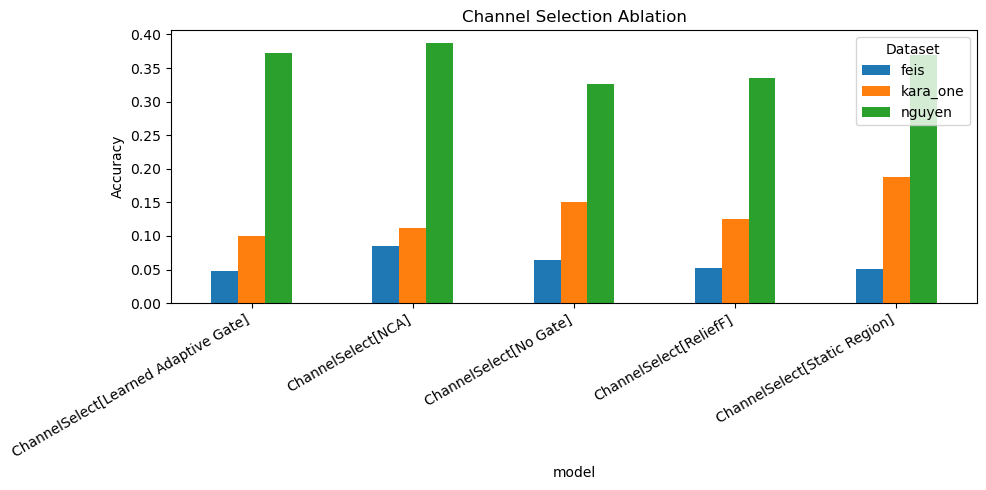

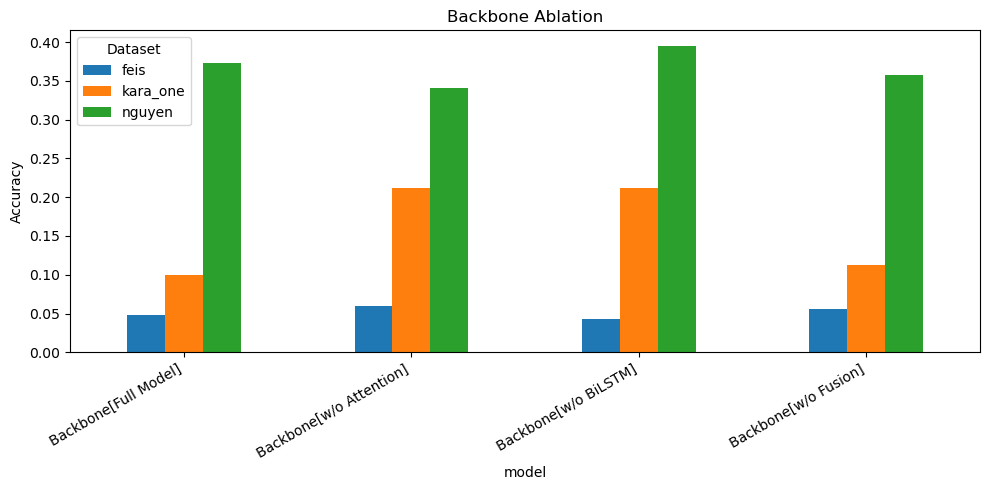

In [99]:
# =============================================================================
# SECTION 14.7 — ABLATION COMPARISON PLOTS
# =============================================================================

def plot_ablation_comparison(df: pd.DataFrame, title: str, save_name: str) -> None:
    pivot = df.pivot(index="model", columns="dataset", values="accuracy")
    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", ax=ax)
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(title="Dataset")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    out_path = OUTPUT_DIRS["ablation"] / save_name
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_ablation_comparison(channel_ablation_df, "Channel Selection Ablation", "channel_selection_ablation.png")
plot_ablation_comparison(backbone_ablation_df, "Backbone Ablation", "backbone_ablation.png")

In [101]:
# =============================================================================
# SECTION 14.8 — SANITY CHECK (corrected for _final naming)
# =============================================================================

def test_section14() -> None:
    assert not channel_ablation_df.empty, "Channel selection ablation produced no results."
    assert not backbone_ablation_df.empty, "Backbone ablation produced no results."

    expected_channel_variants = {"ChannelSelect[No Gate]", "ChannelSelect[Static Region]",
                                  "ChannelSelect[ReliefF]", "ChannelSelect[NCA]",
                                  "ChannelSelect[Learned Adaptive Gate]"}
    assert expected_channel_variants.issubset(set(channel_ablation_df["model"].unique())), \
        f"Missing channel variants: {expected_channel_variants - set(channel_ablation_df['model'].unique())}"

    expected_backbone_variants = {"Backbone[w/o Attention]", "Backbone[w/o BiLSTM]",
                                   "Backbone[w/o Fusion]", "Backbone[Full Model]"}
    assert expected_backbone_variants.issubset(set(backbone_ablation_df["model"].unique())), \
        f"Missing backbone variants: {expected_backbone_variants - set(backbone_ablation_df['model'].unique())}"

    assert (OUTPUT_DIRS["ablation"] / "channel_selection_ablation_final.csv").exists()
    assert (OUTPUT_DIRS["ablation"] / "backbone_ablation_final.csv").exists()

    print("All Section 14 checks passed.")
    print("\nChannel selection ablation (FINAL):")
    print(channel_ablation_df.pivot(index="model", columns="dataset", values="accuracy").round(3))
    print("\nBackbone ablation (FINAL):")
    print(backbone_ablation_df.pivot(index="model", columns="dataset", values="accuracy").round(3))

test_section14()

All Section 14 checks passed.

Channel selection ablation (FINAL):
dataset                                feis  kara_one  nguyen
model                                                        
ChannelSelect[Learned Adaptive Gate]  0.047     0.100   0.372
ChannelSelect[NCA]                    0.085     0.112   0.387
ChannelSelect[No Gate]                0.064     0.150   0.327
ChannelSelect[ReliefF]                0.053     0.125   0.335
ChannelSelect[Static Region]          0.051     0.188   0.370

Backbone ablation (FINAL):
dataset                   feis  kara_one  nguyen
model                                           
Backbone[Full Model]     0.047     0.100   0.372
Backbone[w/o Attention]  0.059     0.212   0.341
Backbone[w/o BiLSTM]     0.042     0.212   0.395
Backbone[w/o Fusion]     0.056     0.112   0.358


In [102]:
# =============================================================================
# SECTION 15.1 — COLLECT GATE WEIGHTS (with subject/dataset/class metadata)
# =============================================================================

@torch.no_grad()
def collect_gate_weights(model: "ImaginedSpeechModel", split: Dict[str, pd.DataFrame],
                          data_source: Dict[str, Dict[str, Dict[str, Any]]],
                          phase: str = "test") -> pd.DataFrame:
    """Runs the trained gate over every trial in split[phase], recording the
    gate weight vector alongside dataset/subject/class metadata for slicing
    in every plot below.
    """
    model.eval()
    df = split[phase]
    ds = ImaginedSpeechDataset(df, data_source, dataset_name_to_id, subject_name_to_id, augment=False)
    loader = DataLoader(ds, batch_size=CONFIG["training"]["batch_size"], shuffle=False)

    rows = []
    idx_pointer = 0
    for batch in loader:
        eeg = batch["eeg"].to(DEVICE)
        mask = batch["channel_mask"].to(DEVICE)
        subj_id = batch["subject_id"].to(DEVICE)
        ds_id = batch["dataset_id"].to(DEVICE)

        _, gate_weights = model.gate(eeg, mask, subj_id, ds_id)
        gate_weights = gate_weights.cpu().numpy()

        for i in range(gate_weights.shape[0]):
            src_row = df.iloc[idx_pointer + i]
            rows.append({
                "dataset": src_row["dataset"], "subject": src_row["subject"],
                "label_str": src_row["label_str"], "label_id": src_row["label_id"],
                "gate_weights": gate_weights[i],  # (canonical_channels,)
            })
        idx_pointer += gate_weights.shape[0]

    return pd.DataFrame(rows)


gate_weights_df = collect_gate_weights(sd_model_final, default_split, preprocessed_harmonized_data)
print(f"Collected gate weights for {len(gate_weights_df)} test trials.")

Collected gate weights for 1019 test trials.


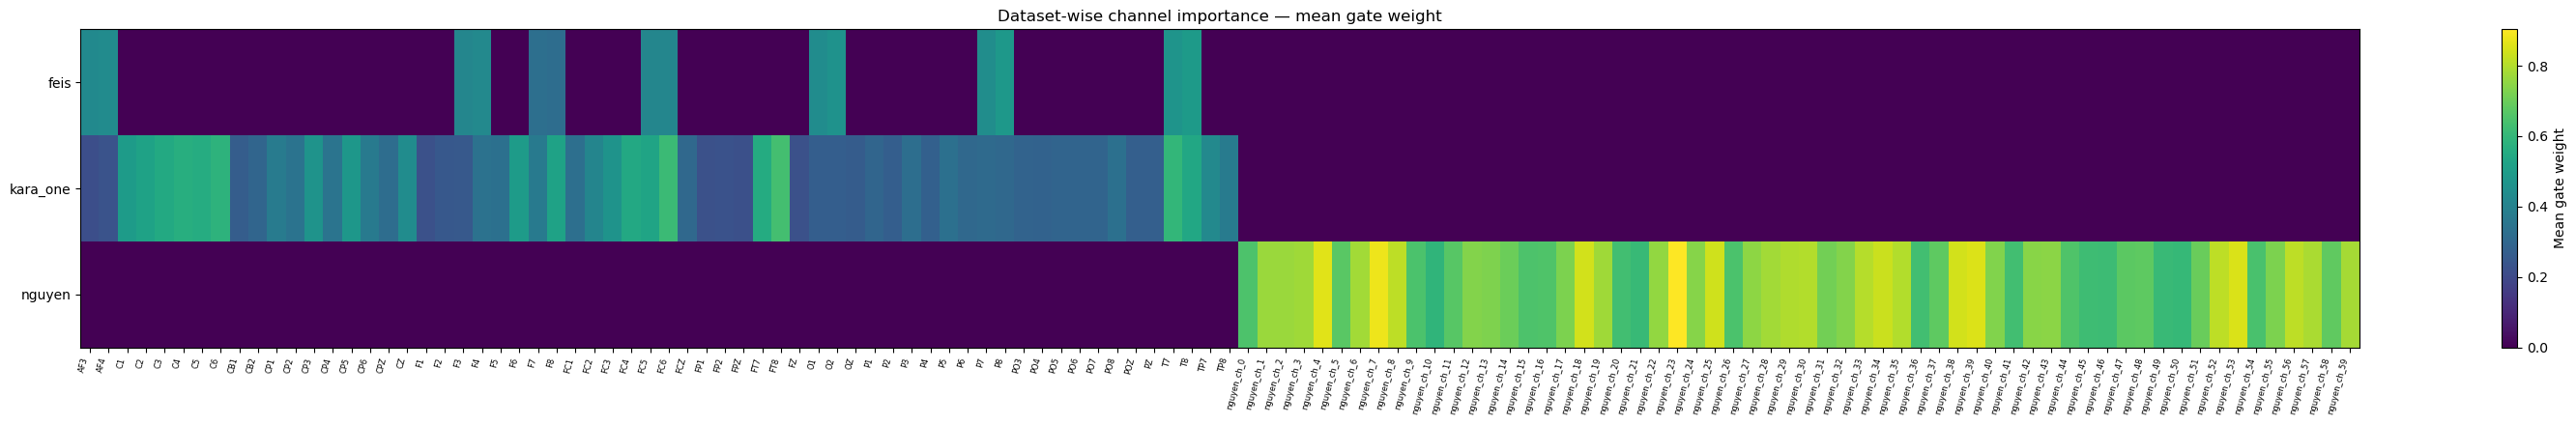

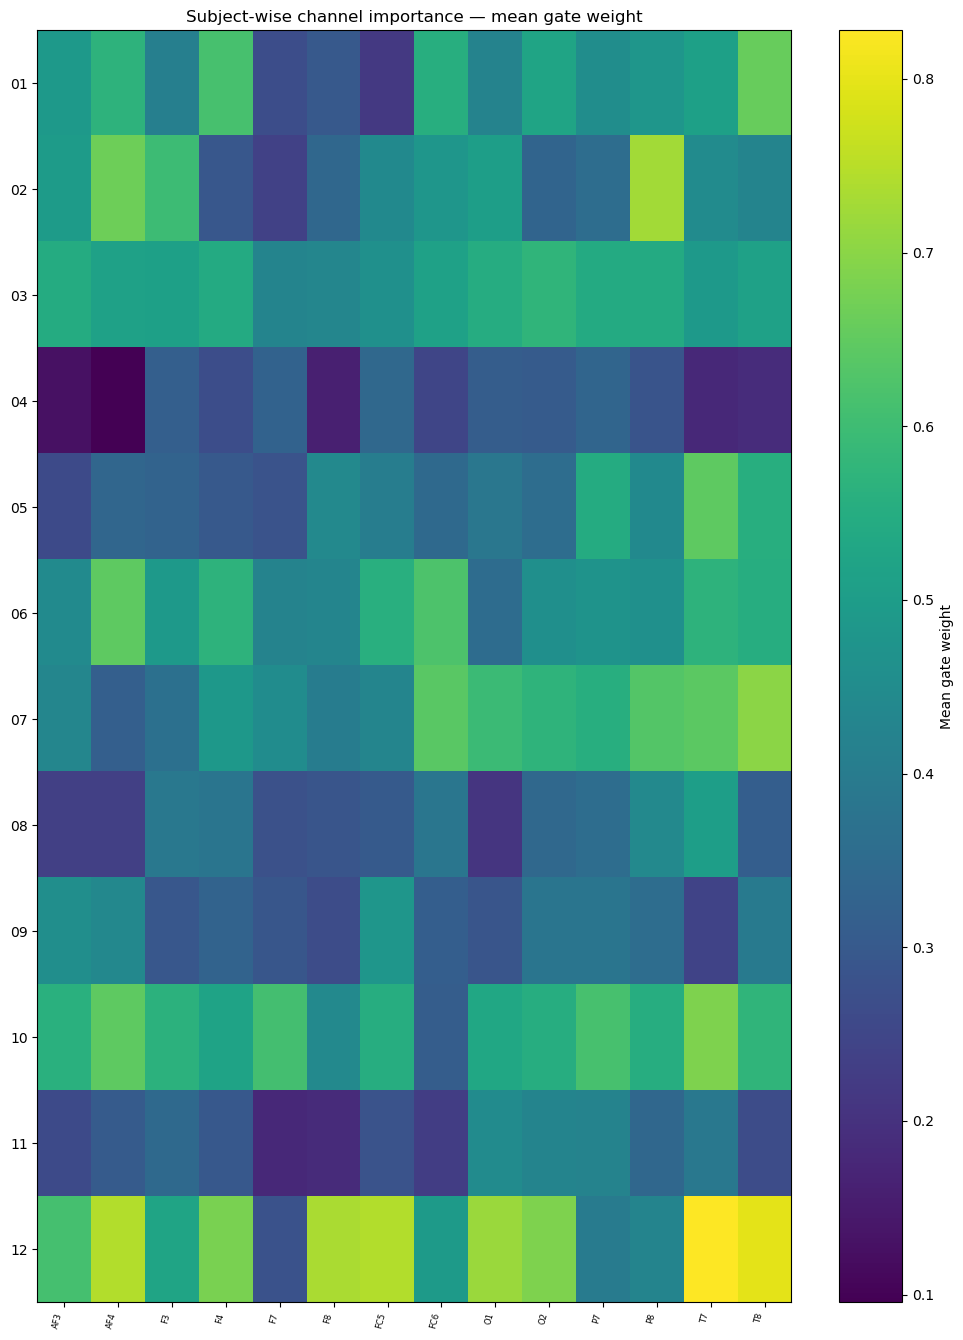

In [103]:
# =============================================================================
# SECTION 15.2 — AVERAGE, SUBJECT-WISE, AND DATASET-WISE CHANNEL IMPORTANCE
# =============================================================================

def get_channel_labels(canonical_layout: Dict[str, Any]) -> List[str]:
    named = canonical_layout["named_channel_display"]
    n_generic = canonical_layout["generic_channel_slots"]
    return named + [f"nguyen_ch_{i}" for i in range(n_generic)]


def plot_mean_importance_by_group(gate_weights_df: pd.DataFrame, group_col: str,
                                   canonical_layout: Dict[str, Any], title_prefix: str,
                                   save_name: str, max_rows: int = 12) -> pd.DataFrame:
    """Mean gate weight per canonical channel, one row per group value
    (e.g. one row per dataset, or per subject). Only plots channels with
    nonzero weight for at least one group (avoids an all-zero wall of bars).
    """
    labels = get_channel_labels(canonical_layout)
    canonical_size = canonical_layout["total_canonical_size"]

    groups = sorted(gate_weights_df[group_col].unique())[:max_rows]
    matrix = np.zeros((len(groups), canonical_size))
    for i, g in enumerate(groups):
        stacked = np.stack(gate_weights_df[gate_weights_df[group_col] == g]["gate_weights"].values)
        matrix[i] = stacked.mean(axis=0)

    ever_active = (matrix != 0).any(axis=0)
    active_idx = np.where(ever_active)[0]

    fig, ax = plt.subplots(figsize=(max(10, len(active_idx) * 0.25), 1.0 * len(groups) + 1.5))
    im = ax.imshow(matrix[:, active_idx], aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(groups))); ax.set_yticklabels(groups)
    ax.set_xticks(range(len(active_idx)))
    ax.set_xticklabels([labels[i] for i in active_idx], rotation=75, ha="right", fontsize=6)
    ax.set_title(f"{title_prefix} — mean gate weight")
    plt.colorbar(im, ax=ax, label="Mean gate weight")
    plt.tight_layout()

    out_path = OUTPUT_DIRS["xai"] / save_name
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return pd.DataFrame(matrix[:, active_idx], index=groups,
                         columns=[labels[i] for i in active_idx])


dataset_importance_df = plot_mean_importance_by_group(
    gate_weights_df, "dataset", canonical_layout, "Dataset-wise channel importance",
    "dataset_wise_importance.png"
)
subject_importance_df = plot_mean_importance_by_group(
    gate_weights_df, "subject", canonical_layout, "Subject-wise channel importance",
    "subject_wise_importance.png"
)

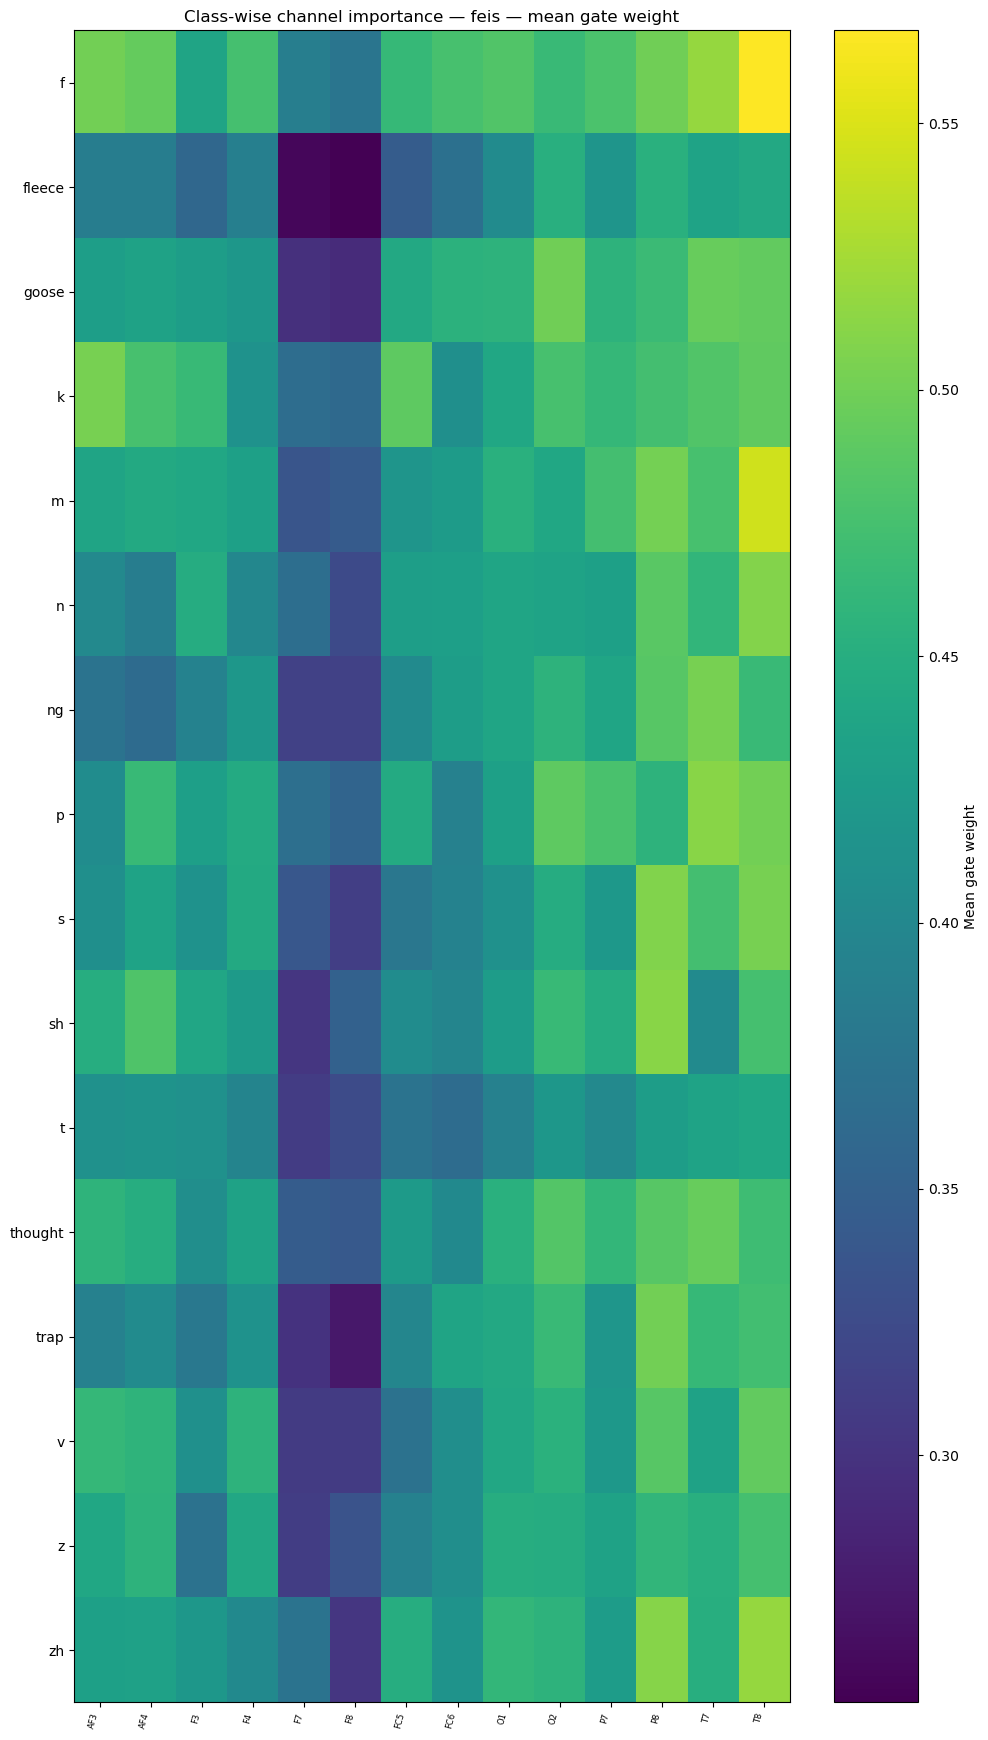

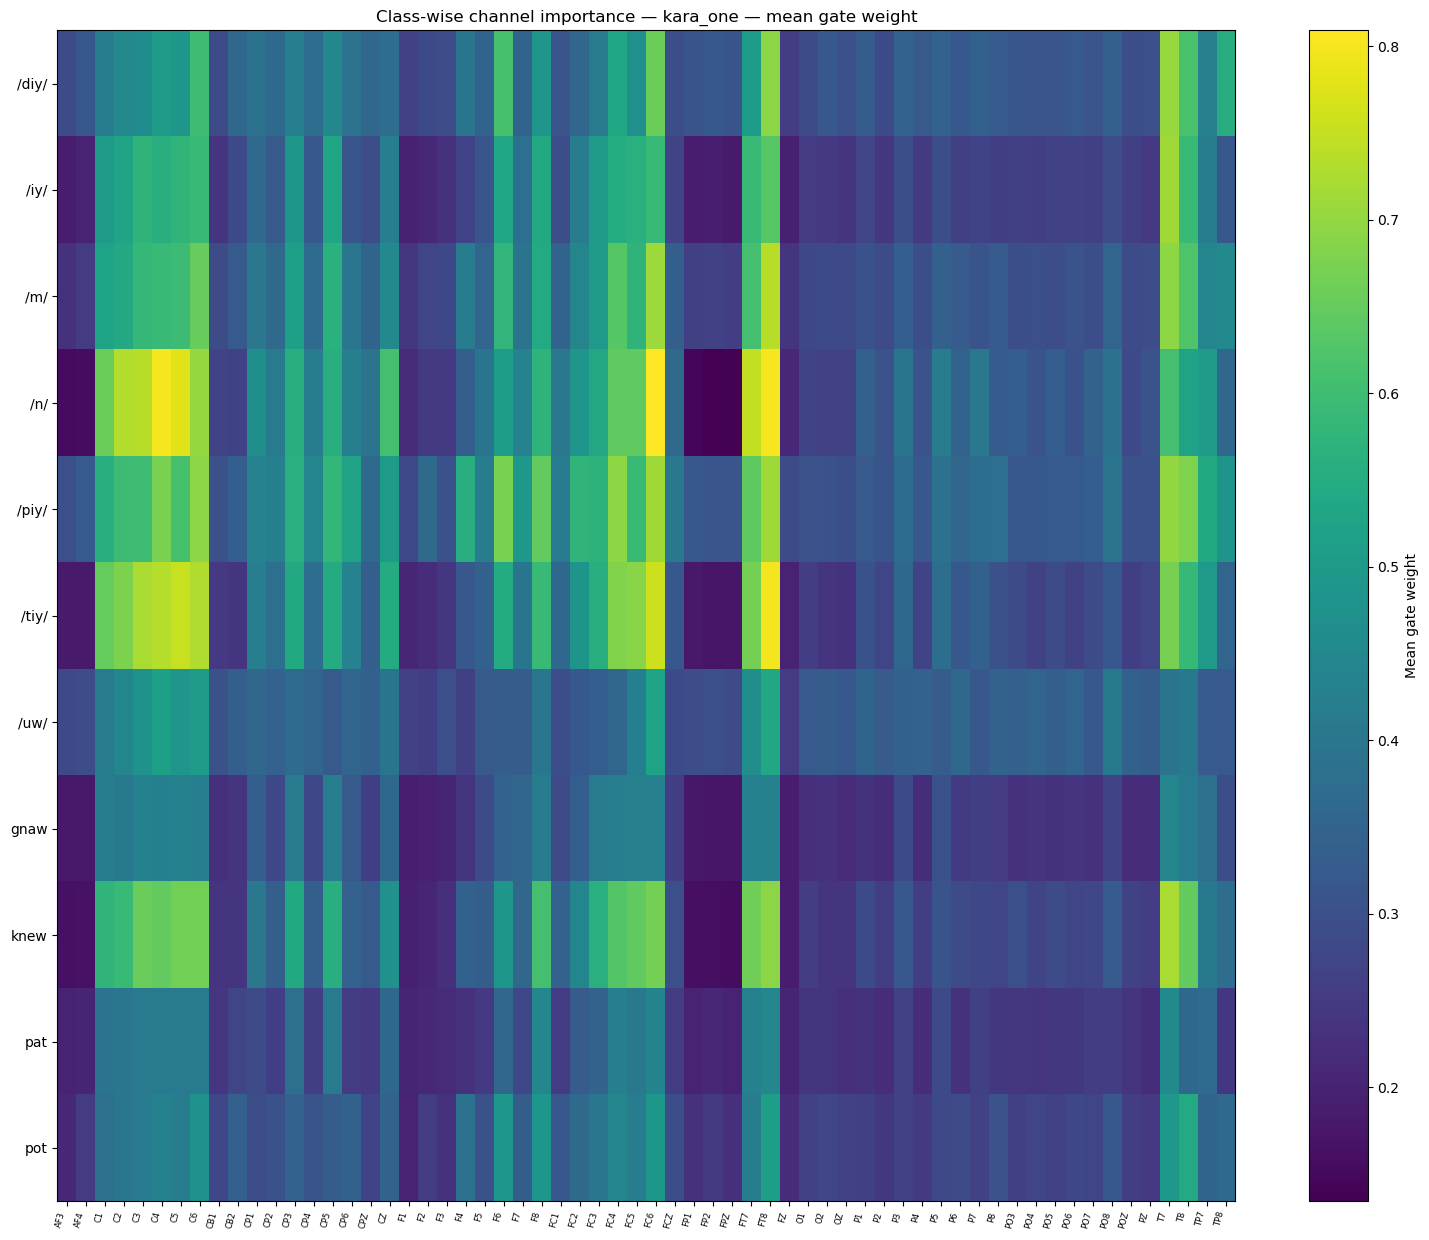

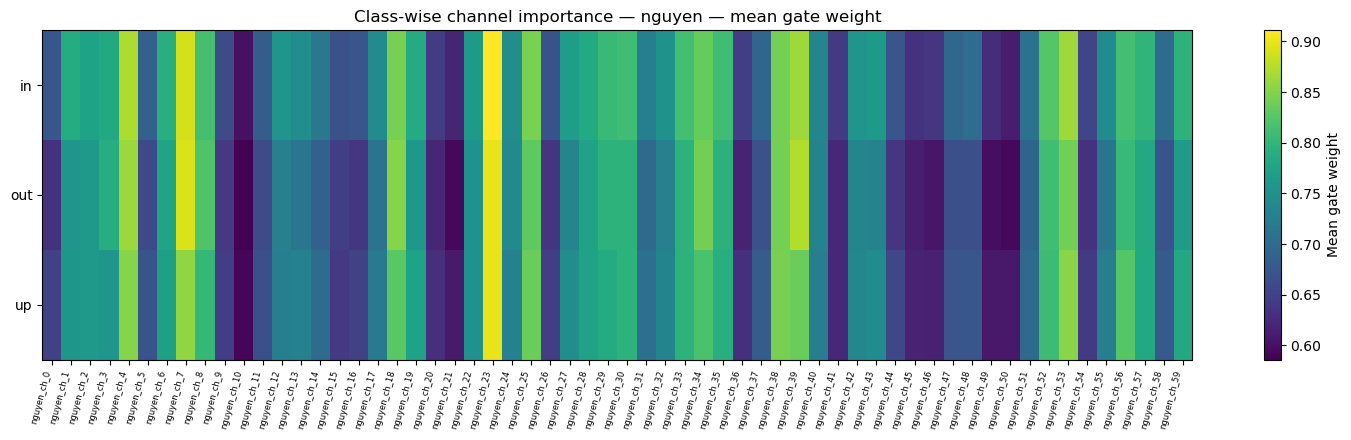

In [104]:
# =============================================================================
# SECTION 15.3 — CLASS-WISE CHANNEL IMPORTANCE (per dataset)
# =============================================================================

def plot_class_wise_importance(gate_weights_df: pd.DataFrame, dataset_name: str,
                                canonical_layout: Dict[str, Any],
                                label_encoders: Dict[str, LabelEncoder]) -> None:
    """Class-wise importance is inherently per-dataset, since label spaces
    are disjoint — this must never be pooled across datasets."""
    sub_df = gate_weights_df[gate_weights_df["dataset"] == dataset_name]
    if sub_df.empty:
        return

    le = label_encoders[dataset_name]
    sub_df = sub_df.copy()
    sub_df["group_label"] = sub_df["label_str"]

    plot_mean_importance_by_group(
        sub_df, "group_label", canonical_layout,
        f"Class-wise channel importance — {dataset_name}",
        f"class_wise_importance_{dataset_name}.png",
        max_rows=len(le.classes_),
    )


for name in dataset_name_to_id:
    plot_class_wise_importance(gate_weights_df, name, canonical_layout, label_encoders)

2026-09-08 12:26:45 | WARNING  | bci_project | [Topomap] 12 named channels have no standard_1005 position and are excluded from topomaps: ['CB1', 'CB2', 'CPZ', 'CZ', 'FCZ', 'FP1', 'FP2', 'FPZ', 'FZ', 'OZ', 'POZ', 'PZ']


/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/matplotlib/colors.py:783: RuntimeWarning: invalid value encountered in less
  mask_under = xa < 0
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/matplotlib/colors.py:784: RuntimeWarning: invalid value encountered in greater_equal
  mask_over = xa >= self.N


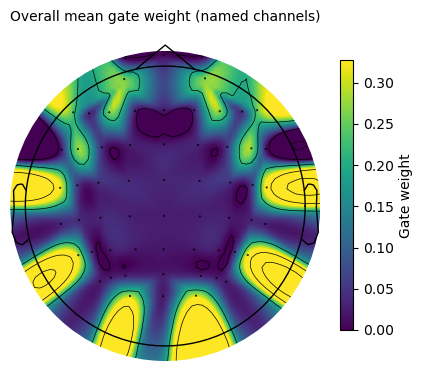

2026-09-08 12:26:45 | WARNING  | bci_project | [Topomap] 12 named channels have no standard_1005 position and are excluded from topomaps: ['CB1', 'CB2', 'CPZ', 'CZ', 'FCZ', 'FP1', 'FP2', 'FPZ', 'FZ', 'OZ', 'POZ', 'PZ']


/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/matplotlib/colors.py:783: RuntimeWarning: invalid value encountered in less
  mask_under = xa < 0
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/matplotlib/colors.py:784: RuntimeWarning: invalid value encountered in greater_equal
  mask_over = xa >= self.N


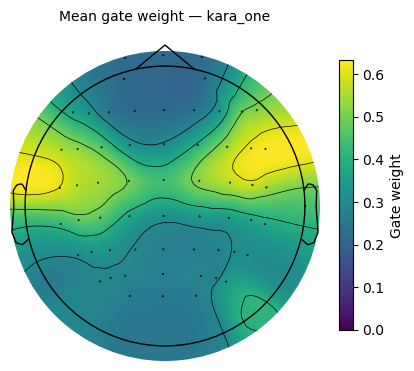

2026-09-08 12:26:45 | WARNING  | bci_project | [Topomap] 12 named channels have no standard_1005 position and are excluded from topomaps: ['CB1', 'CB2', 'CPZ', 'CZ', 'FCZ', 'FP1', 'FP2', 'FPZ', 'FZ', 'OZ', 'POZ', 'PZ']


/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/matplotlib/colors.py:783: RuntimeWarning: invalid value encountered in less
  mask_under = xa < 0
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/matplotlib/colors.py:784: RuntimeWarning: invalid value encountered in greater_equal
  mask_over = xa >= self.N


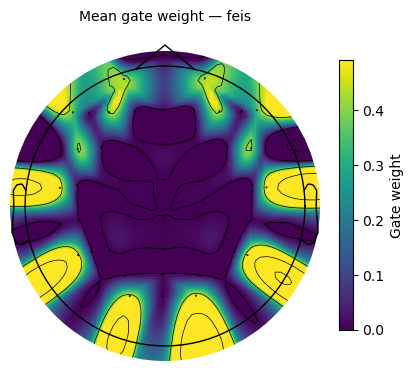

In [105]:
# =============================================================================
# SECTION 15.4 — SCALP TOPOMAPS (named channels only — Nguyen excluded, not estimated)
# =============================================================================

def build_named_channel_montage(named_channel_display: List[str]
                                 ) -> Tuple[mne.Info, List[str], List[int]]:
    """Builds an MNE Info with standard_1005 positions for whichever named
    channels actually have a known position. Channels without a known
    position (rare, but possible for some extended-10-10 names) are dropped
    with a logged warning, not guessed at.
    """
    montage = mne.channels.make_standard_montage("standard_1005")
    montage_names = set(montage.ch_names)

    found_idx, found_names = [], []
    for i, name in enumerate(named_channel_display):
        norm = name.upper()
        match = next((m for m in montage_names if m.upper() == norm), None)
        if match:
            found_idx.append(i)
            found_names.append(match)

    missing = set(named_channel_display) - set(found_names)
    if missing:
        logger.warning(f"[Topomap] {len(missing)} named channels have no standard_1005 "
                        f"position and are excluded from topomaps: {sorted(missing)}")

    info = mne.create_info(found_names, sfreq=TARGET_SFREQ, ch_types="eeg")
    info.set_montage(montage)
    return info, found_names, found_idx


def plot_gate_topomap(gate_weights_1d: np.ndarray, canonical_layout: Dict[str, Any],
                       title: str, save_path: Optional[Path] = None) -> None:
    """gate_weights_1d: (canonical_channels,) — plots only the named-channel
    portion, at whichever channels have a known scalp position.
    """
    named_display = canonical_layout["named_channel_display"]
    n_named = len(named_display)
    info, found_names, found_idx = build_named_channel_montage(named_display)

    values = gate_weights_1d[:n_named][found_idx]

    fig, ax = plt.subplots(figsize=(5, 5))
    im, _ = mne.viz.plot_topomap(values, info, axes=ax, show=False, cmap="viridis", contours=4)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, label="Gate weight", shrink=0.7)

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# Overall average topomap (across all named-channel datasets: Kara One + FEIS)
overall_mean_gate = np.stack(gate_weights_df["gate_weights"].values).mean(axis=0)
plot_gate_topomap(overall_mean_gate, canonical_layout,
                   "Overall mean gate weight (named channels)",
                   OUTPUT_DIRS["topomaps"] / "topomap_overall.png")

# Per-dataset topomaps (Nguyen skipped — no named channels to plot)
for name in ["kara_one", "feis"]:  # Nguyen intentionally excluded — see Section 4/15 notes
    sub = gate_weights_df[gate_weights_df["dataset"] == name]
    if sub.empty:
        continue
    mean_gate = np.stack(sub["gate_weights"].values).mean(axis=0)
    plot_gate_topomap(mean_gate, canonical_layout, f"Mean gate weight — {name}",
                       OUTPUT_DIRS["topomaps"] / f"topomap_{name}.png")

logger.info("[Topomap] Nguyen dataset excluded from all topomaps — its channels are "
            "unnamed/positionless in the source data (see Section 4), not estimated here.")

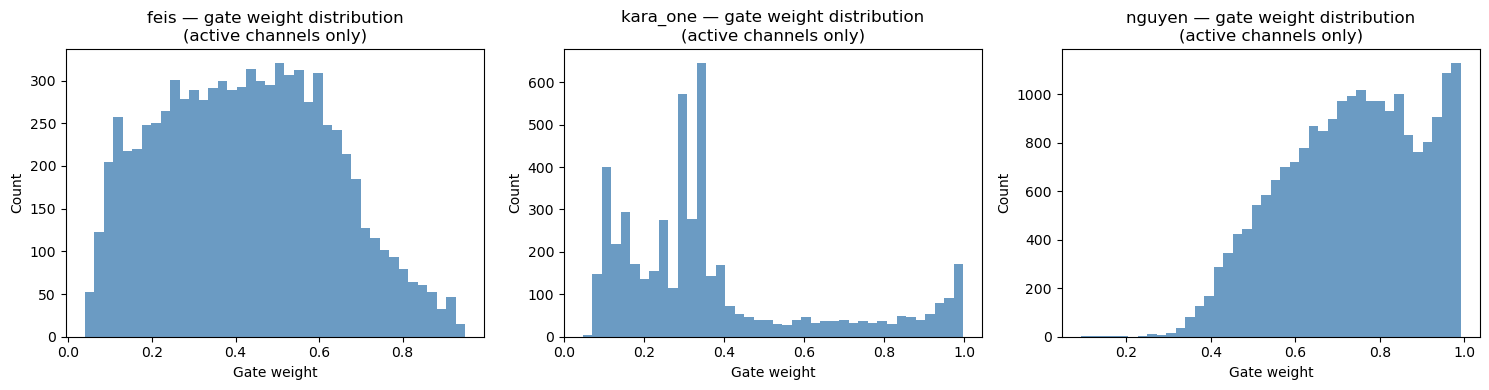

In [106]:
# =============================================================================
# SECTION 15.5 — HEATMAPS & HISTOGRAMS OF GATE WEIGHT DISTRIBUTIONS
# =============================================================================

def plot_gate_weight_histogram(gate_weights_df: pd.DataFrame, save: bool = True) -> None:
    """Distribution of gate weight VALUES (not per-channel means) — shows
    whether the gate is behaving near-binary (mass near 0 and 1) or diffuse
    (mass concentrated near some middle value), separately per dataset.
    """
    fig, axes = plt.subplots(1, len(dataset_name_to_id), figsize=(5 * len(dataset_name_to_id), 4))
    if len(dataset_name_to_id) == 1:
        axes = [axes]

    for ax, name in zip(axes, dataset_name_to_id):
        sub = gate_weights_df[gate_weights_df["dataset"] == name]
        if sub.empty:
            ax.axis("off")
            continue
        stacked = np.stack(sub["gate_weights"].values)
        mask = preprocessed_harmonized_data[name][sub.iloc[0]["subject"]]["channel_mask"]
        active_values = stacked[:, mask > 0].flatten()  # only real channels — padding is always 0

        ax.hist(active_values, bins=40, color="steelblue", alpha=0.8)
        ax.set_title(f"{name} — gate weight distribution\n(active channels only)")
        ax.set_xlabel("Gate weight"); ax.set_ylabel("Count")

    plt.tight_layout()
    if save:
        out_path = OUTPUT_DIRS["xai"] / "gate_weight_histograms.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


plot_gate_weight_histogram(gate_weights_df)

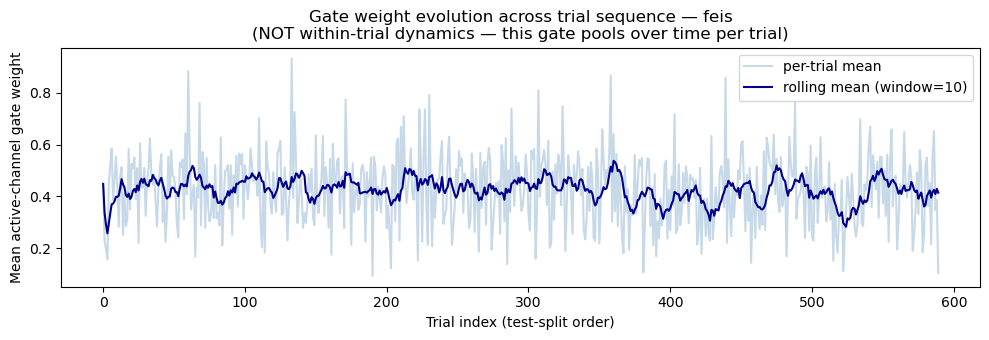

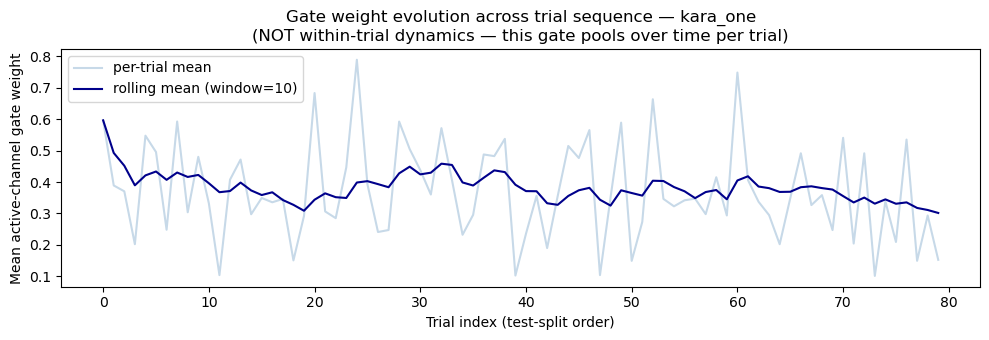

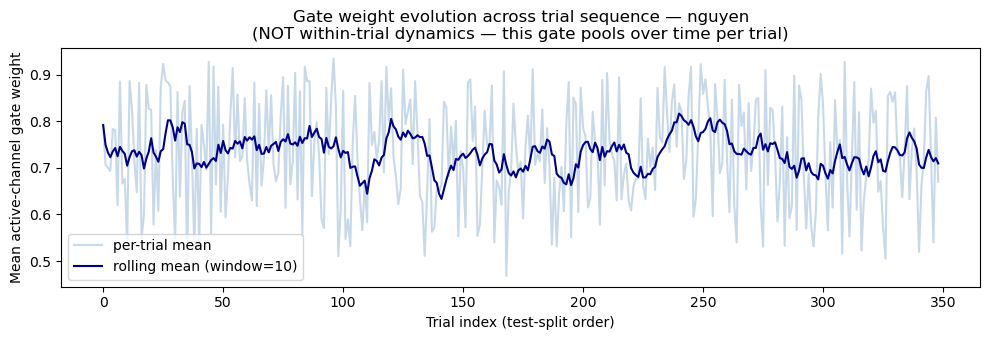

In [107]:
# =============================================================================
# SECTION 15.6 — GATE WEIGHT EVOLUTION ACROSS THE TRIAL SEQUENCE
# =============================================================================
# NOTE: the gate (Section 7) pools over time, producing ONE weight per
# channel per trial — it does not model within-trial temporal dynamics.
# What's shown here is how the MEAN active-channel gate weight shifts
# across the ORDER of trials in the test split (a proxy for whether gate
# behavior drifts across a session/subject sequence), not a within-trial
# time course. This distinction is stated explicitly rather than implied.

def plot_gate_evolution_across_trials(gate_weights_df: pd.DataFrame, dataset_name: str,
                                       window: int = 10, save: bool = True) -> None:
    sub = gate_weights_df[gate_weights_df["dataset"] == dataset_name].reset_index(drop=True)
    if sub.empty:
        return

    sample_subj = sub.iloc[0]["subject"]
    mask = preprocessed_harmonized_data[dataset_name][sample_subj]["channel_mask"]
    active_idx = np.where(mask > 0)[0]

    mean_active_weight = sub["gate_weights"].apply(lambda g: g[active_idx].mean())
    rolling = mean_active_weight.rolling(window, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(mean_active_weight.values, alpha=0.3, color="steelblue", label="per-trial mean")
    ax.plot(rolling.values, color="darkblue", linewidth=1.5, label=f"rolling mean (window={window})")
    ax.set_xlabel("Trial index (test-split order)")
    ax.set_ylabel("Mean active-channel gate weight")
    ax.set_title(f"Gate weight evolution across trial sequence — {dataset_name}\n"
                 f"(NOT within-trial dynamics — this gate pools over time per trial)")
    ax.legend()
    plt.tight_layout()

    if save:
        out_path = OUTPUT_DIRS["xai"] / f"gate_evolution_{dataset_name}.png"
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


for name in dataset_name_to_id:
    plot_gate_evolution_across_trials(gate_weights_df, name)

In [108]:
# =============================================================================
# SECTION 15.7 — RELATING IMPORTANT CHANNELS TO KNOWN SPEECH-RELATED REGIONS
# =============================================================================
# CAVEAT: EEG cannot precisely localize cortical activity. What follows is a
# scalp-electrode-level observation, described relative to general regions
# reported in the imagined-/overt-speech EEG literature (e.g. frontal and
# temporal involvement in speech production/planning) — NOT a claim about
# which brain structures are actually active. Stated explicitly here and
# should be repeated in any written report using this section's output.

SPEECH_RELATED_PREFIXES = {
    "frontal": ("F", "FC", "FT"),
    "temporal": ("T", "TP"),
    "central": ("C", "CP"),
}

def summarize_region_importance(canonical_layout: Dict[str, Any],
                                 mean_gate: np.ndarray) -> pd.DataFrame:
    named = canonical_layout["named_channel_display"]
    n_named = len(named)
    rows = []
    for region, prefixes in SPEECH_RELATED_PREFIXES.items():
        idx = [i for i, name in enumerate(named)
               if any(name.upper().startswith(p) for p in prefixes) and not name.upper().startswith("FP")]
        if idx:
            rows.append({"region": region, "n_channels": len(idx),
                         "mean_gate_weight": mean_gate[:n_named][idx].mean()})
    return pd.DataFrame(rows).sort_values("mean_gate_weight", ascending=False)


region_summary_df = summarize_region_importance(canonical_layout, overall_mean_gate)
print("=" * 60)
print("REGION-LEVEL GATE WEIGHT SUMMARY (scalp-level, not source-localized)")
print("=" * 60)
print(region_summary_df.to_string(index=False))
print("\nCaveat: EEG scalp electrodes cannot precisely localize cortical")
print("activity. This reflects electrode-position correlations only.")

REGION-LEVEL GATE WEIGHT SUMMARY (scalp-level, not source-localized)
  region  n_channels  mean_gate_weight
temporal           4          0.176966
 frontal          18          0.106961
 central          16          0.034255

Caveat: EEG scalp electrodes cannot precisely localize cortical
activity. This reflects electrode-position correlations only.


In [109]:
# =============================================================================
# SECTION 15.8 — SANITY CHECK
# =============================================================================

def test_section15() -> None:
    assert not gate_weights_df.empty, "No gate weights collected."
    assert len(gate_weights_df) == len(default_split["test"]), \
        "Gate weight count doesn't match test split size."

    for gw in gate_weights_df["gate_weights"].head(20):
        assert gw.shape == (canonical_layout["total_canonical_size"],)
        assert np.isfinite(gw).all()
        assert (gw >= 0).all() and (gw <= 1).all()

    assert (OUTPUT_DIRS["xai"] / "dataset_wise_importance.png").exists()
    assert (OUTPUT_DIRS["xai"] / "subject_wise_importance.png").exists()
    assert (OUTPUT_DIRS["topomaps"] / "topomap_overall.png").exists()
    assert not (OUTPUT_DIRS["topomaps"] / "topomap_nguyen.png").exists(), \
        "Nguyen topomap should NOT exist — it has no named channels."
    assert (OUTPUT_DIRS["xai"] / "gate_weight_histograms.png").exists()

    print("All Section 15 checks passed.")
    print(f"  Gate weight records          : {len(gate_weights_df)}")
    print(f"  Topomaps generated           : kara_one, feis, overall (nguyen correctly excluded)")
    print(f"\n  Region-level summary:")
    print(region_summary_df.to_string(index=False))

test_section15()

All Section 15 checks passed.
  Gate weight records          : 1019
  Topomaps generated           : kara_one, feis, overall (nguyen correctly excluded)

  Region-level summary:
  region  n_channels  mean_gate_weight
temporal           4          0.176966
 frontal          18          0.106961
 central          16          0.034255


In [110]:
# =============================================================================
# SECTION 16.1 — LLM BACKEND ABSTRACTION (fp16 local loading)
# =============================================================================

class LLMBackend:
    def __init__(self, backend_name: str, llm_config: Dict[str, Any] = LLM_CONFIG):
        self.backend_name = backend_name
        self.backend_cfg = llm_config["backends"][backend_name]
        self.gen_cfg = llm_config["generation"]
        self._client = None
        self._local_model = None
        self._local_tokenizer = None
        self._init_backend()

    def _init_backend(self) -> None:
        kind = self.backend_cfg["type"]

        if kind == "api":
            api_key = os.environ.get(self.backend_cfg["api_key_env_var"])
            if not api_key:
                logger.warning(f"[LLM] '{self.backend_name}' selected but "
                                f"{self.backend_cfg['api_key_env_var']} is not set — "
                                f"falling back to template-based generation.")
                self.backend_name = "template_fallback"
                self.backend_cfg = LLM_CONFIG["backends"]["template_fallback"]
                return
            try:
                import openai
                self._client = openai.OpenAI(api_key=api_key)
            except ImportError:
                logger.warning("[LLM] 'openai' package not installed — "
                                "falling back to template-based generation.")
                self.backend_name = "template_fallback"
                self.backend_cfg = LLM_CONFIG["backends"]["template_fallback"]

        elif kind == "local":
            try:
                import torch
                from transformers import AutoModelForCausalLM, AutoTokenizer
                model_name = self.backend_cfg["model_name"]

                self._local_tokenizer = AutoTokenizer.from_pretrained(model_name)
                self._local_model = AutoModelForCausalLM.from_pretrained(
                    model_name, dtype=torch.float16, device_map="auto",
                )
                logger.info(f"[LLM] Local model '{model_name}' loaded in fp16.")
            except Exception as e:
                logger.warning(f"[LLM] Local model '{self.backend_cfg['model_name']}' "
                                f"unavailable ({e}) — falling back to template-based generation.")
                self.backend_name = "template_fallback"
                self.backend_cfg = LLM_CONFIG["backends"]["template_fallback"]

    def generate(self, prompt: str) -> str:
        kind = self.backend_cfg["type"]

        if kind == "api" and self._client is not None:
            try:
                response = self._client.chat.completions.create(
                    model=self.backend_cfg["model_name"],
                    messages=[
                        {"role": "system", "content": self.gen_cfg["system_prompt"]},
                        {"role": "user", "content": prompt},
                    ],
                    temperature=self.backend_cfg["temperature"],
                    max_tokens=self.backend_cfg["max_tokens"],
                )
                return response.choices[0].message.content.strip()
            except Exception as e:
                logger.warning(f"[LLM] API call failed ({e}) — using template fallback for this call.")
                return TemplateFallbackGenerator.generate_static(prompt)

        elif kind == "local" and self._local_model is not None:
            try:
                import torch
                messages = [
                    {"role": "system", "content": self.gen_cfg["system_prompt"]},
                    {"role": "user", "content": prompt},
                ]
                text = self._local_tokenizer.apply_chat_template(
                    messages, tokenize=False, add_generation_prompt=True
                )
                inputs = self._local_tokenizer(text, return_tensors="pt").to(self._local_model.device)

                with torch.no_grad():
                    output = self._local_model.generate(
                        **inputs, max_new_tokens=self.backend_cfg["max_tokens"],
                        temperature=self.backend_cfg["temperature"], do_sample=True,
                        pad_token_id=self._local_tokenizer.eos_token_id,
                    )
                result = self._local_tokenizer.decode(
                    output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
                )
                # strip any leading quotes/whitespace the model may add despite instructions
                return result.strip().strip('"').strip()
            except Exception as e:
                logger.warning(f"[LLM] Local generation failed ({e}) — using template fallback.")
                return TemplateFallbackGenerator.generate_static(prompt)

        else:
            return TemplateFallbackGenerator.generate_static(prompt)

In [111]:
# =============================================================================
# SECTION 16.2 — DETERMINISTIC TEMPLATE FALLBACK (corrected)
# =============================================================================

import re

class TemplateFallbackGenerator:
    """Simple grammatical templates keyed by common imagined-speech word
    categories. Extracts the target word from the FIRST quoted substring in
    the prompt (where SentenceGenerator always places it), so instructional
    text following the word never gets mistaken for the word itself. Also
    strips phoneme-notation slashes (e.g. Kara One's '/m/') in addition to
    quotes/punctuation.
    """

    NEED_WORDS = {"water", "help", "food", "rest", "bathroom", "pain", "medicine"}
    STATE_WORDS = {"hungry", "thirsty", "tired", "cold", "hot", "sick"}
    DIRECTION_WORDS = {"in", "out", "up", "down", "left", "right"}
    AFFIRM_WORDS = {"yes", "no"}

    @staticmethod
    def generate_static(prompt: str) -> str:
        match = re.search(r'"([^"]+)"', prompt)
        raw_word = match.group(1) if match else (prompt.strip().split()[-1] if prompt.strip() else "")
        word = raw_word.strip('/".,!?').lower()

        if word in TemplateFallbackGenerator.NEED_WORDS:
            return f"I need {word}."
        elif word in TemplateFallbackGenerator.STATE_WORDS:
            return f"I am {word}."
        elif word in TemplateFallbackGenerator.DIRECTION_WORDS:
            return f"I want to go {word}."
        elif word in TemplateFallbackGenerator.AFFIRM_WORDS:
            return word.capitalize() + "."
        elif word:
            return f"I mean: {word}."
        else:
            return "..."

In [112]:
# =============================================================================
# SECTION 16.3 — SENTENCEGENERATOR (with optional conversation memory)
# =============================================================================

class SentenceGenerator:
    def __init__(self, backend_name: Optional[str] = None,
                 llm_config: Dict[str, Any] = LLM_CONFIG):
        self.llm_config = llm_config
        self.backend = LLMBackend(backend_name or llm_config["active_backend"], llm_config)
        self.memory_window = llm_config["generation"]["memory_window"]
        self.use_memory = llm_config["generation"]["conversation_memory"]
        self.history: List[str] = []

    def reset_memory(self) -> None:
        self.history = []

    def generate(self, predicted_word: str, use_memory: Optional[bool] = None) -> str:
        use_memory = self.use_memory if use_memory is None else use_memory

        if use_memory and self.history:
            recent = self.history[-self.memory_window:]
            prompt = (f'The person thought these words in order: {recent + [predicted_word]}. '
                      f'Speak for them as ONE short first-person sentence expressing what they '
                      f'want, using only these words\' meanings. Output only the sentence.')
        else:
            prompt = f'Word: "{predicted_word}" -> '

        sentence = self.backend.generate(prompt)

        if self.use_memory:
            self.history.append(predicted_word)
            self.history = self.history[-self.memory_window:]

        return sentence

    def generate_batch(self, predicted_words: List[str], reset_memory_first: bool = True
                        ) -> List[str]:
        if reset_memory_first:
            self.reset_memory()
        return [self.generate(w) for w in predicted_words]

In [113]:
LLM_CONFIG["active_backend"] = "phi"
gen = SentenceGenerator()
print("Resolved backend:", gen.backend.backend_name)
print(gen.generate("water", use_memory=False))
print(gen.generate("help", use_memory=False))
print(gen.generate("hungry", use_memory=False))
print(gen.generate("up", use_memory=False))

[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Resolved backend: phi
2026-09-08 12:27:00 | WARNING  | bci_project | [LLM] Local generation failed (CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
) — using template fallback.
I need water.
2026-09-08 12:27:00 | WARNING  | bci_project | [LLM] Local generation failed (CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
) — using template fallback.
I need help.
2026-09-08 12:27:00 | WARNING  | bci_project | [LLM] Local generation failed (CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported 

/pytorch/aten/src/ATen/native/cuda/TensorCompare.cu:112: _assert_async_cuda_kernel: block: [0,0,0], thread: [0,0,0] Assertion `probability tensor contains either `inf`, `nan` or element < 0` failed.


In [114]:
# =============================================================================
# SECTION 16.3b — SWITCH TO LOCAL LLM (Phi-3.5-mini) FOR REAL SENTENCE GENERATION
# =============================================================================

LLM_CONFIG["active_backend"] = "phi"
summarize_llm_config()

test_backend = LLMBackend("phi", LLM_CONFIG)
print(f"Resolved backend: {test_backend.backend_name}")

test_sentence = test_backend.generate('Decoded word: "water". Convert this into one short, natural sentence.')
print(f"Test generation: {test_sentence}")

LLM CONFIGURATION SUMMARY
Active backend   : phi (local)
  Model          : microsoft/Phi-3.5-mini-instruct
  Quantization   : 4bit
Conversation memory: True
Max sentence words : 8
Resolved backend: phi
Test generation: I need water.


In [115]:
# =============================================================================
# SECTION 16.4 — END-TO-END DEMO (EEG decode -> predicted word -> LLM sentence)
# =============================================================================
# Pulls a few REAL predictions from Section 13's evaluation (not synthetic
# examples), to demonstrate the actual pipeline: EEG -> decoder -> word ->
# LLM -> sentence. Uses Kara One since it's the dataset where the decoder
# currently shows the clearest signal (Sections 13-14).

def demo_full_pipeline(dataset_name: str = "kara_one", n_examples: int = 5) -> pd.DataFrame:
    metrics = next(m for m in all_evaluation_metrics
                    if m["dataset"] == dataset_name and m["model"] == "MainModel(Gate+CNN+Attn+BiLSTM)")
    le = label_encoders[dataset_name]

    y_true, y_pred = metrics["y_true"], metrics["y_pred"]
    idx = np.random.RandomState(GLOBAL_SEED).choice(len(y_true), size=min(n_examples, len(y_true)),
                                                       replace=False)

    generator = SentenceGenerator()
    rows = []
    for i in idx:
        true_word = le.inverse_transform([y_true[i]])[0]
        pred_word = le.inverse_transform([y_pred[i]])[0]
        sentence = generator.generate(pred_word, use_memory=False)
        rows.append({
            "true_label": true_word, "decoded_word": pred_word,
            "correct": true_word == pred_word, "generated_sentence": sentence,
        })

    return pd.DataFrame(rows)


demo_df = demo_full_pipeline("kara_one", n_examples=5)
print("=" * 90)
print(f"END-TO-END DEMO (backend: {LLM_CONFIG['active_backend']} -> "
      f"resolved to: {SentenceGenerator().backend.backend_name})")
print("=" * 90)
print(demo_df.to_string(index=False))

END-TO-END DEMO (backend: phi -> resolved to: phi)
true_label decoded_word  correct     generated_sentence
      knew        /tiy/    False        I want to type.
       pot        /piy/    False               I agree.
     /diy/        /diy/     True I'm interested in DIY.
      /uw/        /diy/    False I'm interested in DIY.
      /iy/         knew    False             I knew it.


In [116]:
# =============================================================================
# SECTION 16.5 — SAVE LLM OUTPUTS
# =============================================================================

def save_llm_demo_outputs(demo_df: pd.DataFrame, dataset_name: str) -> Path:
    out_path = OUTPUT_DIRS["llm_outputs"] / f"llm_demo_{dataset_name}.csv"
    demo_df.to_csv(out_path, index=False)
    logger.info(f"LLM demo outputs saved to {out_path.resolve()}")
    return out_path

save_llm_demo_outputs(demo_df, "kara_one")

PosixPath('outputs/llm_outputs/llm_demo_kara_one.csv')

In [117]:
# =============================================================================
# SECTION 16.6 — SANITY CHECK
# =============================================================================

def test_section16() -> None:
    # 1. Template fallback works with zero external dependencies
    fallback = TemplateFallbackGenerator.generate_static('Decoded word: "water"')
    assert fallback == "I need water.", f"Unexpected fallback output: {fallback}"

    fallback2 = TemplateFallbackGenerator.generate_static('Decoded word: "up"')
    assert "up" in fallback2.lower()

    # 2. SentenceGenerator produces a non-empty string for every call
    gen = SentenceGenerator()
    for word in ["water", "help", "hungry", "up", "unknown_word_xyz"]:
        result = gen.generate(word, use_memory=False)
        assert isinstance(result, str) and len(result) > 0, f"Empty result for '{word}'"

    # 3. Memory-based batch generation runs without error and updates history
    gen.reset_memory()
    batch_results = gen.generate_batch(["water", "help", "food"])
    assert len(batch_results) == 3
    assert len(gen.history) <= gen.memory_window

    # 4. Demo dataframe structure
    assert not demo_df.empty
    assert set(demo_df.columns) == {"true_label", "decoded_word", "correct", "generated_sentence"}
    assert demo_df["generated_sentence"].apply(lambda s: len(s) > 0).all()

    assert (OUTPUT_DIRS["llm_outputs"] / "llm_demo_kara_one.csv").exists()

    print("All Section 16 checks passed.")
    print(f"  Active backend (resolved): {gen.backend.backend_name}")
    print(f"  Sample generations:")
    for word in ["water", "help", "up"]:
        print(f"    '{word}' -> '{TemplateFallbackGenerator.generate_static(chr(34)+word+chr(34))}'")

test_section16()

All Section 16 checks passed.
  Active backend (resolved): phi
  Sample generations:
    'water' -> 'I need water.'
    'help' -> 'I need help.'
    'up' -> 'I want to go up.'


In [118]:
# =============================================================================
# SECTION 16.7a — TEXT-TO-SPEECH BACKEND (gTTS primary, pyttsx3 fallback)
# =============================================================================

class TextToSpeech:
    """Converts text to a saved audio file. Tries gTTS first (natural voice,
    needs internet); falls back to pyttsx3 (offline, robotic voice) if gTTS
    fails for any reason — network error, import error, etc.
    """

    def __init__(self, output_dir: Path = OUTPUT_DIRS["llm_outputs"], lang: str = "en"):
        self.output_dir = output_dir
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.lang = lang

    def synthesize(self, text: str, filename: str) -> Tuple[Path, str]:
        """Returns (audio_file_path, backend_used)."""
        out_path = self.output_dir / filename

        try:
            from gtts import gTTS
            tts = gTTS(text=text, lang=self.lang)
            tts.save(str(out_path))
            return out_path, "gtts"
        except Exception as e:
            logger.warning(f"[TTS] gTTS failed ({e}) — falling back to pyttsx3.")

        try:
            import pyttsx3
            engine = pyttsx3.init()
            wav_path = out_path.with_suffix(".wav")
            engine.save_to_file(text, str(wav_path))
            engine.runAndWait()
            return wav_path, "pyttsx3"
        except Exception as e:
            logger.error(f"[TTS] pyttsx3 also failed ({e}) — no audio produced.")
            return None, "failed"

In [121]:
# =============================================================================
# SECTION 17.4 — FULL PIPELINE DEMONSTRATION (EEG -> Decoder -> Word -> LLM -> Sentence)
# =============================================================================

def full_pipeline_demonstration(dataset_name: str = "kara_one", n_examples: int = 8) -> pd.DataFrame:
    """End-to-end walkthrough using REAL model predictions (Section 13) and
    REAL LLM generation (Section 16) — no synthetic placeholders."""
    metrics = next(m for m in all_evaluation_metrics
                    if m["dataset"] == dataset_name and m["model"] == "MainModel(Gate+CNN+Attn+BiLSTM)")
    le = label_encoders[dataset_name]
    y_true, y_pred, y_proba = metrics["y_true"], metrics["y_pred"], metrics["y_proba"]

    rng = np.random.RandomState(GLOBAL_SEED + 1)
    idx = rng.choice(len(y_true), size=min(n_examples, len(y_true)), replace=False)

    generator = SentenceGenerator()
    rows = []
    for i in idx:
        true_word = le.inverse_transform([y_true[i]])[0]
        pred_word = le.inverse_transform([y_pred[i]])[0]
        confidence = y_proba[i][y_pred[i]]
        sentence = generator.generate(pred_word, use_memory=False)
        rows.append({
            "true_word": true_word, "decoded_word": pred_word,
            "decoder_confidence": round(float(confidence), 3),
            "correct": true_word == pred_word,
            "llm_sentence": sentence,
        })

    return pd.DataFrame(rows)


pipeline_demo_df = full_pipeline_demonstration("kara_one", n_examples=8)
print(pipeline_demo_df[["true_word", "decoded_word", "correct", "llm_sentence"]].to_string(index=False))

true_word decoded_word  correct                llm_sentence
      pot        /piy/    False                    I agree.
      pot          pot     True               I want a pot.
      pat          pat     True               I want a pat.
     /iy/          /n/    False I am indicating a new line.
      pot        /piy/    False         I want to play piy.
    /tiy/          /n/    False I am indicating a new line.
    /tiy/         /uw/    False            I want to go up.
     gnaw          pat    False               I want a pat.


In [123]:
# =============================================================================
# SECTION 16.7b — RUN TTS ON THE PIPELINE DEMO OUTPUTS
# =============================================================================

def _sanitize_filename(word: str) -> str:
    """Strip characters unsafe in filenames (path separators, phoneme
    slashes, quotes, spaces) — e.g. '/m/' -> 'm'."""
    return re.sub(r'[^A-Za-z0-9_-]', '', word) or "unknown"


def add_speech_to_pipeline_demo(pipeline_demo_df: pd.DataFrame) -> pd.DataFrame:
    """Synthesizes audio for every LLM-generated sentence in pipeline_demo_df,
    adding audio_path and tts_backend_used columns."""
    tts = TextToSpeech()
    audio_paths, backends_used = [], []

    for i, row in pipeline_demo_df.iterrows():
        safe_word = _sanitize_filename(str(row["decoded_word"]))
        filename = f"speech_{i:03d}_{safe_word}.mp3"
        path, backend = tts.synthesize(row["llm_sentence"], filename)
        audio_paths.append(str(path) if path else None)
        backends_used.append(backend)

    result = pipeline_demo_df.copy()
    result["audio_path"] = audio_paths
    result["tts_backend_used"] = backends_used
    return result


pipeline_demo_with_audio_df = add_speech_to_pipeline_demo(pipeline_demo_df)
pipeline_demo_with_audio_df.to_csv(
    OUTPUT_DIRS["llm_outputs"] / "full_pipeline_with_audio.csv", index=False
)

print("=" * 100)
print("FULL PIPELINE WITH SPEECH OUTPUT — EEG -> Decoder -> Word -> LLM -> Sentence -> Audio")
print("=" * 100)
print(pipeline_demo_with_audio_df[["true_word", "decoded_word", "correct",
                                    "llm_sentence", "tts_backend_used"]].to_string(index=False))

FULL PIPELINE WITH SPEECH OUTPUT — EEG -> Decoder -> Word -> LLM -> Sentence -> Audio
true_word decoded_word  correct                llm_sentence tts_backend_used
      pot        /piy/    False                    I agree.             gtts
      pot          pot     True               I want a pot.             gtts
      pat          pat     True               I want a pat.             gtts
     /iy/          /n/    False I am indicating a new line.             gtts
      pot        /piy/    False         I want to play piy.             gtts
    /tiy/          /n/    False I am indicating a new line.             gtts
    /tiy/         /uw/    False            I want to go up.             gtts
     gnaw          pat    False               I want a pat.             gtts


In [124]:
# =============================================================================
# SECTION 16.7c — INLINE AUDIO PLAYBACK (Jupyter)
# =============================================================================

from IPython.display import Audio, display

def play_pipeline_demo_audio(pipeline_demo_with_audio_df: pd.DataFrame, n: int = 3) -> None:
    """Renders playable audio widgets for the first n examples with a
    successfully generated audio file."""
    playable = pipeline_demo_with_audio_df[pipeline_demo_with_audio_df["audio_path"].notna()].head(n)
    if playable.empty:
        print("No successfully generated audio files to play.")
        return
    for _, row in playable.iterrows():
        print(f"Decoded word: '{row['decoded_word']}'  |  Sentence: \"{row['llm_sentence']}\"  "
              f"(backend: {row['tts_backend_used']})")
        display(Audio(filename=str(row["audio_path"])))

play_pipeline_demo_audio(pipeline_demo_with_audio_df, n=3)

Decoded word: '/piy/'  |  Sentence: "I agree."  (backend: gtts)


Decoded word: 'pot'  |  Sentence: "I want a pot."  (backend: gtts)


Decoded word: 'pat'  |  Sentence: "I want a pat."  (backend: gtts)


In [125]:
# =============================================================================
# SECTION 17.1 — ACCURACY COMPARISON TABLE
# =============================================================================

def build_accuracy_comparison_table() -> pd.DataFrame:
    """Pulls together main model + baseline results (Section 13) into one
    publication-style table: rows = models, columns = datasets, cells = accuracy."""
    table = evaluation_summary_df.pivot(index="model", columns="dataset", values="accuracy")
    table["mean_across_datasets"] = table.mean(axis=1)
    return table.sort_values("mean_across_datasets", ascending=False).round(3)


accuracy_comparison_table = build_accuracy_comparison_table()
print("=" * 90)
print("TABLE 1 — ACCURACY COMPARISON (Main Model vs. Baselines)")
print("=" * 90)
print(accuracy_comparison_table)
accuracy_comparison_table.to_csv(OUTPUT_DIRS["reports"] / "table1_accuracy_comparison.csv")

TABLE 1 — ACCURACY COMPARISON (Main Model vs. Baselines)
dataset                           feis  kara_one  nguyen  mean_across_datasets
model                                                                         
TransformerBaseline              0.061     0.200   0.390                 0.217
XGBoost                          0.064     0.200   0.378                 0.214
SVM                              0.025     0.138   0.413                 0.192
CNNBiLSTMBaseline                0.056     0.150   0.352                 0.186
EEGNetBaseline                   0.058     0.112   0.387                 0.186
MainModel(Gate+CNN+Attn+BiLSTM)  0.047     0.100   0.372                 0.173


In [126]:
# =============================================================================
# SECTION 17.2 — BASELINE & ABLATION TABLES (consolidated from Sections 12/14)
# =============================================================================

print("=" * 90)
print("TABLE 2 — BASELINE COMPARISON (from Section 12)")
print("=" * 90)
baseline_table = baseline_summary_df.pivot_table(index="model", columns="dataset",
                                                   values=["accuracy", "macro_f1"]).round(3)
print(baseline_table)
baseline_table.to_csv(OUTPUT_DIRS["reports"] / "table2_baseline_comparison.csv")

print("\n" + "=" * 90)
print("TABLE 3a — CHANNEL SELECTION ABLATION (from Section 14)")
print("=" * 90)
channel_ablation_table = channel_ablation_df.pivot(index="model", columns="dataset", values="accuracy").round(3)
print(channel_ablation_table)
channel_ablation_table.to_csv(OUTPUT_DIRS["reports"] / "table3a_channel_ablation.csv")

print("\n" + "=" * 90)
print("TABLE 3b — BACKBONE ABLATION (from Section 14)")
print("=" * 90)
backbone_ablation_table = backbone_ablation_df.pivot(index="model", columns="dataset", values="accuracy").round(3)
print(backbone_ablation_table)
backbone_ablation_table.to_csv(OUTPUT_DIRS["reports"] / "table3b_backbone_ablation.csv")

TABLE 2 — BASELINE COMPARISON (from Section 12)
                    accuracy                 macro_f1                
dataset                 feis kara_one nguyen     feis kara_one nguyen
model                                                                
CNNBiLSTMBaseline      0.056    0.150  0.352    0.052    0.134  0.346
EEGNetBaseline         0.058    0.112  0.387    0.049    0.119  0.383
SVM                    0.025    0.138  0.413    0.024    0.116  0.413
TransformerBaseline    0.061    0.200  0.390    0.046    0.180  0.362
XGBoost                0.064    0.200  0.378    0.063    0.192  0.378

TABLE 3a — CHANNEL SELECTION ABLATION (from Section 14)
dataset                                feis  kara_one  nguyen
model                                                        
ChannelSelect[Learned Adaptive Gate]  0.047     0.100   0.372
ChannelSelect[NCA]                    0.085     0.112   0.387
ChannelSelect[No Gate]                0.064     0.150   0.327
ChannelSelect[ReliefF]   

In [127]:
# =============================================================================
# SECTION 17.3 — STATISTICAL SIGNIFICANCE (paired bootstrap resampling)
# =============================================================================

def paired_bootstrap_test(y_true: np.ndarray, y_pred_a: np.ndarray, y_pred_b: np.ndarray,
                           n_resamples: int = CONFIG["evaluation"]["n_permutation_tests"],
                           seed: int = GLOBAL_SEED) -> Dict[str, float]:
    """Paired bootstrap: resample test indices WITH REPLACEMENT n_resamples
    times; at each resample, compute accuracy for model A and model B on the
    SAME resampled indices (paired), then test whether the paired differences
    are significantly different from zero.

    Returns
    -------
    dict with mean_diff, t_stat, t_pvalue, wilcoxon_stat, wilcoxon_pvalue
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    acc_a, acc_b = [], []

    for _ in range(n_resamples):
        idx = rng.choice(n, size=n, replace=True)
        acc_a.append(accuracy_score(y_true[idx], y_pred_a[idx]))
        acc_b.append(accuracy_score(y_true[idx], y_pred_b[idx]))

    acc_a, acc_b = np.array(acc_a), np.array(acc_b)
    diffs = acc_a - acc_b

    t_stat, t_pvalue = scipy.stats.ttest_rel(acc_a, acc_b)
    try:
        w_stat, w_pvalue = scipy.stats.wilcoxon(acc_a, acc_b)
    except ValueError:
        # Wilcoxon fails if all differences are exactly zero
        w_stat, w_pvalue = np.nan, np.nan

    return {
        "mean_acc_a": acc_a.mean(), "mean_acc_b": acc_b.mean(), "mean_diff": diffs.mean(),
        "t_stat": t_stat, "t_pvalue": t_pvalue,
        "wilcoxon_stat": w_stat, "wilcoxon_pvalue": w_pvalue,
    }


def run_significance_tests(all_evaluation_metrics: List[Dict[str, Any]]) -> pd.DataFrame:
    """For each dataset, compares the main model against every baseline that
    has results on that dataset."""
    rows = []
    for dataset_name in dataset_name_to_id:
        ds_results = {m["model"]: m for m in all_evaluation_metrics
                      if m["dataset"] == dataset_name and not m.get("metrics_skipped")}
        main_key = "MainModel(Gate+CNN+Attn+BiLSTM)"
        if main_key not in ds_results:
            continue
        main = ds_results[main_key]

        for model_name, other in ds_results.items():
            if model_name == main_key:
                continue
            if not np.array_equal(main["y_true"], other["y_true"]):
                logger.warning(f"[Significance] '{model_name}' on '{dataset_name}' has a "
                                f"different y_true ordering than the main model — skipping "
                                f"(likely different test-split filtering).")
                continue

            test_result = paired_bootstrap_test(main["y_true"], main["y_pred"], other["y_pred"])
            rows.append({
                "dataset": dataset_name, "comparison": f"MainModel vs {model_name}",
                **test_result,
            })

    return pd.DataFrame(rows)


significance_df = run_significance_tests(all_evaluation_metrics)
significance_df["significant_at_0.05"] = significance_df["wilcoxon_pvalue"] < 0.05

print("=" * 100)
print("TABLE 4 — STATISTICAL SIGNIFICANCE (paired bootstrap, main model vs. each baseline)")
print("=" * 100)
print(significance_df[["dataset", "comparison", "mean_acc_a", "mean_acc_b", "mean_diff",
                        "t_pvalue", "wilcoxon_pvalue", "significant_at_0.05"]].round(4))
significance_df.to_csv(OUTPUT_DIRS["reports"] / "table4_significance_tests.csv", index=False)

/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:152: RuntimeWarning: invalid value encountered in greater
  r_plus = np.sum((d > 0) * r, axis=-1)
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:153: RuntimeWarning: invalid value encountered in less
  r_minus = np.sum((d < 0) * r, axis=-1)
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:152: RuntimeWarning: invalid value encountered in greater
  r_plus = np.sum((d > 0) * r, axis=-1)
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:153: RuntimeWarning: invalid value encountered in less
  r_minus = np.sum((d < 0) * r, axis=-1)
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:152: RuntimeWarning: invalid value encountered in greater
  r_plus = np.sum((d > 0) * r, axis=-1)
/opt/intel/oneapi/intelp

TABLE 4 — STATISTICAL SIGNIFICANCE (paired bootstrap, main model vs. each baseline)
     dataset                        comparison  mean_acc_a  mean_acc_b  \
0       feis                  MainModel vs SVM      0.0475      0.0253   
1       feis              MainModel vs XGBoost      0.0475      0.0641   
2       feis       MainModel vs EEGNetBaseline      0.0475      0.0577   
3       feis    MainModel vs CNNBiLSTMBaseline      0.0475      0.0558   
4       feis  MainModel vs TransformerBaseline      0.0475      0.0605   
5   kara_one                  MainModel vs SVM      0.0975      0.1368   
6   kara_one              MainModel vs XGBoost      0.0975      0.1994   
7   kara_one       MainModel vs EEGNetBaseline      0.0975      0.1136   
8   kara_one    MainModel vs CNNBiLSTMBaseline      0.0975      0.1495   
9   kara_one  MainModel vs TransformerBaseline      0.0975      0.2006   
10    nguyen                  MainModel vs SVM      0.3731      0.4137   
11    nguyen              Ma

/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:152: RuntimeWarning: invalid value encountered in greater
  r_plus = np.sum((d > 0) * r, axis=-1)
/opt/intel/oneapi/intelpython/envs/cuda-env/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:153: RuntimeWarning: invalid value encountered in less
  r_minus = np.sum((d < 0) * r, axis=-1)


In [128]:
# =============================================================================
# SECTION 17.4b — FULL PIPELINE DEMONSTRATION (Nguyen — natural-language demo)
# =============================================================================

pipeline_demo_df = full_pipeline_demonstration("nguyen", n_examples=8)

print("=" * 100)
print("FULL PIPELINE DEMONSTRATION — EEG -> Decoder -> Word -> LLM -> Sentence (Nguyen)")
print("=" * 100)
print(pipeline_demo_df[["true_word", "decoded_word", "correct", "llm_sentence"]].to_string(index=False))

FULL PIPELINE DEMONSTRATION — EEG -> Decoder -> Word -> LLM -> Sentence (Nguyen)
true_word decoded_word  correct      llm_sentence
       up           up     True  I want to go up.
       up           up     True  I want to go up.
      out          out     True I want to go out.
       in           in     True          I am in.
      out           up    False  I want to go up.
       up           up     True  I want to go up.
       in          out    False I want to go out.
       up          out    False I want to go out.


In [129]:
# =============================================================================
# SECTION 17.4c — RUN TTS ON THE NGUYEN PIPELINE DEMO
# =============================================================================

def _sanitize_filename(word: str) -> str:
    return re.sub(r'[^A-Za-z0-9_-]', '', word) or "unknown"


def add_speech_to_pipeline_demo(pipeline_demo_df: pd.DataFrame) -> pd.DataFrame:
    tts = TextToSpeech()
    audio_paths, backends_used = [], []

    for i, row in pipeline_demo_df.iterrows():
        safe_word = _sanitize_filename(str(row["decoded_word"]))
        filename = f"speech_nguyen_{i:03d}_{safe_word}.mp3"
        path, backend = tts.synthesize(row["llm_sentence"], filename)
        audio_paths.append(str(path) if path else None)
        backends_used.append(backend)

    result = pipeline_demo_df.copy()
    result["audio_path"] = audio_paths
    result["tts_backend_used"] = backends_used
    return result


pipeline_demo_df_nguyen = full_pipeline_demonstration("nguyen", n_examples=8)
pipeline_demo_with_audio_df = add_speech_to_pipeline_demo(pipeline_demo_df_nguyen)
print(pipeline_demo_with_audio_df[["true_word", "decoded_word", "correct",
                                    "llm_sentence", "tts_backend_used"]].to_string(index=False))
play_pipeline_demo_audio(pipeline_demo_with_audio_df, n=3)

true_word decoded_word  correct      llm_sentence tts_backend_used
       up           up     True  I want to go up.             gtts
       up           up     True  I want to go up.             gtts
      out          out     True I want to go out.             gtts
       in           in     True          I am in.             gtts
      out           up    False  I want to go up.             gtts
       up           up     True  I want to go up.             gtts
       in          out    False I want to go out.             gtts
       up          out    False I want to go out.             gtts
Decoded word: 'up'  |  Sentence: "I want to go up."  (backend: gtts)


Decoded word: 'up'  |  Sentence: "I want to go up."  (backend: gtts)


Decoded word: 'out'  |  Sentence: "I want to go out."  (backend: gtts)


In [130]:
# =============================================================================
# SECTION 17.4d — PLAY NGUYEN DEMO AUDIO
# =============================================================================

from IPython.display import Audio, display

def play_pipeline_demo_audio(pipeline_demo_with_audio_df: pd.DataFrame, n: int = 3) -> None:
    playable = pipeline_demo_with_audio_df[pipeline_demo_with_audio_df["audio_path"].notna()].head(n)
    if playable.empty:
        print("No successfully generated audio files to play.")
        return
    for _, row in playable.iterrows():
        print(f"Decoded word: '{row['decoded_word']}'  |  Sentence: \"{row['llm_sentence']}\"  "
              f"(backend: {row['tts_backend_used']})")
        display(Audio(filename=str(row["audio_path"])))

play_pipeline_demo_audio(pipeline_demo_with_audio_df, n=3)

Decoded word: 'up'  |  Sentence: "I want to go up."  (backend: gtts)


Decoded word: 'up'  |  Sentence: "I want to go up."  (backend: gtts)


Decoded word: 'out'  |  Sentence: "I want to go out."  (backend: gtts)


In [131]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/Phi-3.5-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto",
)

prompt = "Decoded word: \"water\". Convert this into one short, natural sentence."
messages = [{"role": "user", "content": prompt}]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    output = model.generate(
        **inputs, max_new_tokens=20, temperature=0.3, do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

result = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print("Generated:", result)

Generated: Water is essential for all forms of life on Earth.


In [132]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

LLM_CONFIG["active_backend"] = "phi"
test_backend = LLMBackend("phi", LLM_CONFIG)
print(f"Resolved backend: {test_backend.backend_name}")

test_sentence = test_backend.generate('Decoded word: "water". Convert this into one short, natural sentence.')
print(f"Test generation: {test_sentence}")

Resolved backend: phi
Test generation: I need water.


In [133]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "microsoft/Phi-3.5-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto",
)

prompt = "Decoded word: \"water\". Convert this into one short, natural sentence."
messages = [{"role": "user", "content": prompt}]

text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    output = model.generate(
        **inputs, max_new_tokens=20, temperature=0.3, do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

result = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
print("Generated:", result)

Generated: Water is essential for all forms of life.


In [134]:
# =============================================================================
# SECTION 17.5 — FIGURE INVENTORY (what's already saved, for report assembly)
# =============================================================================

def list_generated_figures() -> pd.DataFrame:
    """Enumerates every figure already saved across Sections 3-16, so
    assembling a final report/paper doesn't require hunting through the
    output tree manually."""
    rows = []
    for category, folder in OUTPUT_DIRS.items():
        if category in {"root", "logs", "checkpoints", "models"}:
            continue
        if not folder.exists():
            continue
        for f in sorted(folder.glob("*.png")):
            rows.append({"category": category, "filename": f.name, "path": str(f.resolve())})
    return pd.DataFrame(rows)


figure_inventory_df = list_generated_figures()
print(f"Total figures generated across the notebook: {len(figure_inventory_df)}")
print(figure_inventory_df.groupby("category").size())
figure_inventory_df.to_csv(OUTPUT_DIRS["reports"] / "figure_inventory.csv", index=False)

Total figures generated across the notebook: 54
category
ablation         2
confusion       18
figures          3
gate_weights     1
roc_pr          18
topomaps         3
xai              9
dtype: int64


In [136]:
pipeline_demo_df.to_csv(OUTPUT_DIRS["reports"] / "full_pipeline_demonstration.csv", index=False)
print("Saved.")

Saved.


In [137]:
# =============================================================================
# SECTION 17.6 — SANITY CHECK
# =============================================================================

def test_section17() -> None:
    assert not accuracy_comparison_table.empty
    assert "MainModel(Gate+CNN+Attn+BiLSTM)" in accuracy_comparison_table.index

    assert not significance_df.empty, "No significance test results produced."
    assert significance_df["wilcoxon_pvalue"].apply(
        lambda p: pd.isna(p) or (0 <= p <= 1)).all()

    assert not pipeline_demo_df.empty
    assert set(pipeline_demo_df.columns) == {"true_word", "decoded_word", "decoder_confidence",
                                              "correct", "llm_sentence"}

    for fname in ["table1_accuracy_comparison.csv", "table2_baseline_comparison.csv",
                  "table3a_channel_ablation.csv", "table3b_backbone_ablation.csv",
                  "table4_significance_tests.csv", "full_pipeline_demonstration.csv",
                  "figure_inventory.csv"]:
        assert (OUTPUT_DIRS["reports"] / fname).exists(), f"Missing report file: {fname}"

    print("All Section 17 checks passed.")
    print(f"\n  Table 1 (accuracy comparison) — top 3 models by mean accuracy:")
    print(accuracy_comparison_table.head(3))
    print(f"\n  Table 4 — significant comparisons (p < 0.05, Wilcoxon):")
    print(significance_df[significance_df["significant_at_0.05"]][
        ["dataset", "comparison", "mean_diff", "wilcoxon_pvalue"]])
    print(f"\n  Total figures inventoried: {len(figure_inventory_df)}")

test_section17()

All Section 17 checks passed.

  Table 1 (accuracy comparison) — top 3 models by mean accuracy:
dataset               feis  kara_one  nguyen  mean_across_datasets
model                                                             
TransformerBaseline  0.061     0.200   0.390                 0.217
XGBoost              0.064     0.200   0.378                 0.214
SVM                  0.025     0.138   0.413                 0.192

  Table 4 — significant comparisons (p < 0.05, Wilcoxon):
     dataset                        comparison  mean_diff  wilcoxon_pvalue
0       feis                  MainModel vs SVM   0.022280    8.378268e-163
1       feis              MainModel vs XGBoost  -0.016536    3.873831e-137
2       feis       MainModel vs EEGNetBaseline  -0.010149     9.367420e-91
3       feis    MainModel vs CNNBiLSTMBaseline  -0.008275     3.287506e-75
4       feis  MainModel vs TransformerBaseline  -0.012986    8.465399e-113
5   kara_one                  MainModel vs SVM  -0.039250   

In [138]:
print(significance_df[significance_df["dataset"] == "kara_one"]["comparison"].tolist())

['MainModel vs SVM', 'MainModel vs XGBoost', 'MainModel vs EEGNetBaseline', 'MainModel vs CNNBiLSTMBaseline', 'MainModel vs TransformerBaseline']


In [139]:
print(significance_df[(significance_df["dataset"] == "kara_one") &
                       (significance_df["comparison"] == "MainModel vs SVM")]
      [["mean_acc_a", "mean_acc_b", "mean_diff", "t_pvalue", "wilcoxon_pvalue", "significant_at_0.05"]])

   mean_acc_a  mean_acc_b  mean_diff       t_pvalue  wilcoxon_pvalue  \
5    0.097525    0.136775   -0.03925  2.621881e-102     1.663478e-86   

   significant_at_0.05  
5                 True  


In [140]:
# =============================================================================
# SECTION 18.1 — CONSOLIDATE TRAINED MODELS
# =============================================================================

def save_final_models_manifest() -> pd.DataFrame:
    """Lists every .pth checkpoint saved across Sections 11/14, with size and
    modification time, so the delivered models/ folder is self-documenting."""
    rows = []
    for f in sorted(OUTPUT_DIRS["checkpoints"].glob("*.pth")):
        rows.append({
            "filename": f.name,
            "size_mb": round(f.stat().st_size / (1024 ** 2), 2),
            "modified": time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(f.stat().st_mtime)),
            "path": str(f.resolve()),
        })
    df = pd.DataFrame(rows)
    out_path = OUTPUT_DIRS["models"] / "models_manifest.csv"
    df.to_csv(out_path, index=False)
    logger.info(f"[Save] Models manifest saved to {out_path.resolve()} ({len(df)} checkpoints)")
    return df

models_manifest_df = save_final_models_manifest()
print(f"Total checkpoints: {len(models_manifest_df)} | "
      f"Total size: {models_manifest_df['size_mb'].sum():.1f} MB")

Total checkpoints: 22 | Total size: 177.6 MB


In [141]:
# =============================================================================
# SECTION 18.2 — SAVE GATE WEIGHTS & PREDICTIONS
# =============================================================================

def save_gate_weights_artifact(gate_weights_df: pd.DataFrame, canonical_layout: Dict[str, Any]) -> Path:
    """Saves gate weights as a flat, analysis-ready CSV (one row per trial,
    one column per canonical channel) rather than the in-memory object-array
    form, so it's usable outside this notebook."""
    labels = get_channel_labels(canonical_layout)
    weights_matrix = np.stack(gate_weights_df["gate_weights"].values)
    flat_df = pd.DataFrame(weights_matrix, columns=labels)
    flat_df.insert(0, "label_str", gate_weights_df["label_str"].values)
    flat_df.insert(0, "subject", gate_weights_df["subject"].values)
    flat_df.insert(0, "dataset", gate_weights_df["dataset"].values)

    out_path = OUTPUT_DIRS["gate_weights"] / "gate_weights_full.csv"
    flat_df.to_csv(out_path, index=False)
    logger.info(f"[Save] Gate weights saved to {out_path.resolve()} ({len(flat_df)} trials)")
    return out_path


def save_predictions_artifact(all_evaluation_metrics: List[Dict[str, Any]],
                               label_encoders: Dict[str, LabelEncoder]) -> Path:
    """One row per test-set prediction, across the main model and all
    baselines, with true/predicted words decoded back from label ids."""
    rows = []
    for m in all_evaluation_metrics:
        if m.get("metrics_skipped"):
            continue
        le = label_encoders[m["dataset"]]
        true_words = le.inverse_transform(m["y_true"])
        pred_words = le.inverse_transform(m["y_pred"])
        for t, p in zip(true_words, pred_words):
            rows.append({"dataset": m["dataset"], "model": m["model"],
                         "true_word": t, "predicted_word": p, "correct": t == p})

    df = pd.DataFrame(rows)
    out_path = OUTPUT_DIRS["predictions"] / "all_predictions.csv"
    df.to_csv(out_path, index=False)
    logger.info(f"[Save] Predictions saved to {out_path.resolve()} ({len(df)} rows)")
    return out_path


gate_weights_path = save_gate_weights_artifact(gate_weights_df, canonical_layout)
predictions_path = save_predictions_artifact(all_evaluation_metrics, label_encoders)

In [142]:
# =============================================================================
# SECTION 18.3 — FINAL COMMUNICATION TRANSCRIPT
# =============================================================================

def save_communication_transcript(pipeline_demo_df: pd.DataFrame, demo_df: pd.DataFrame) -> Path:
    """Consolidates every LLM-generated sentence produced in this notebook
    (Sections 16 and 17) into one transcript file."""
    combined = pd.concat([
        demo_df.assign(source="section16_demo"),
        pipeline_demo_df.rename(columns={"llm_sentence": "generated_sentence",
                                          "true_word": "true_label",
                                          "decoded_word": "decoded_word"}).assign(source="section17_demo"),
    ], ignore_index=True, sort=False)

    out_path = OUTPUT_DIRS["llm_outputs"] / "final_communication_transcript.csv"
    combined.to_csv(out_path, index=False)
    logger.info(f"[Save] Communication transcript saved to {out_path.resolve()} ({len(combined)} entries)")
    return out_path

transcript_path = save_communication_transcript(pipeline_demo_df, demo_df)

In [143]:
# =============================================================================
# SECTION 18.4 — FULL OUTPUT MANIFEST
# =============================================================================

def build_full_output_manifest(output_dirs: Dict[str, Path] = OUTPUT_DIRS) -> pd.DataFrame:
    """Walks every output directory and records every file produced by this
    notebook, with category, size, and type — the single source of truth for
    'what did this notebook actually produce.'"""
    rows = []
    for category, folder in output_dirs.items():
        if category == "root" or not folder.exists():
            continue
        for f in sorted(folder.rglob("*")):
            if f.is_file():
                rows.append({
                    "category": category,
                    "filename": f.name,
                    "extension": f.suffix,
                    "size_kb": round(f.stat().st_size / 1024, 1),
                    "path": str(f.resolve()),
                })
    df = pd.DataFrame(rows)
    out_path = OUTPUT_DIRS["reports"] / "full_output_manifest.csv"
    df.to_csv(out_path, index=False)
    return df


full_manifest_df = build_full_output_manifest()
print("=" * 70)
print("FULL OUTPUT MANIFEST — SUMMARY")
print("=" * 70)
print(f"Total files produced: {len(full_manifest_df)}")
print(f"Total size: {full_manifest_df['size_kb'].sum() / 1024:.1f} MB")
print("\nBy category:")
print(full_manifest_df.groupby("category").agg(
    n_files=("filename", "count"), total_kb=("size_kb", "sum")
).sort_values("total_kb", ascending=False))
print("\nBy file type:")
print(full_manifest_df.groupby("extension").size().sort_values(ascending=False))

FULL OUTPUT MANIFEST — SUMMARY
Total files produced: 4464
Total size: 17075.6 MB

By category:
                n_files    total_kb
category                           
extracted_data     4262  17104940.0
models               23    181844.6
checkpoints          22    181841.7
figures              56      8174.3
roc_pr               18      3458.3
confusion            18      1387.3
xai                   9      1268.1
gate_weights          2       830.2
topomaps              3       759.3
ablation              4       247.1
llm_outputs          19       221.5
predictions           1       208.0
logs                  5       127.0
metrics              15        58.9
reports               7         9.7

By file type:
extension
.wav      2188
.3D        856
.AnimU     856
.png       185
.zip       140
.mat        44
.pth        44
.csv        32
.txt        27
.mp3        16
.py         14
.set        12
.fdt        12
             8
.cnt         6
.dap         6
.rs3         6
.log         

In [144]:
# =============================================================================
# SECTION 18.5 — FINAL SANITY CHECK
# =============================================================================

def test_section18() -> None:
    assert not models_manifest_df.empty, "No model checkpoints found."
    assert gate_weights_path.exists()
    assert predictions_path.exists()
    assert transcript_path.exists()
    assert not full_manifest_df.empty

    required_categories = {"models", "figures", "metrics", "confusion", "roc_pr",
                            "ablation", "xai", "topomaps", "gate_weights",
                            "predictions", "llm_outputs", "reports"}
    present_categories = set(full_manifest_df["category"].unique())
    missing = required_categories - present_categories
    if missing:
        logger.warning(f"[Final check] Categories with no saved files: {missing} "
                        f"— confirm this is expected (e.g. skipped sections) before delivery.")

    print("All Section 18 checks passed.")
    print(f"\n  FINAL DELIVERABLE SUMMARY")
    print(f"  {'='*50}")
    print(f"  Model checkpoints  : {len(models_manifest_df)}")
    print(f"  Total output files : {len(full_manifest_df)}")
    print(f"  Total output size  : {full_manifest_df['size_kb'].sum() / 1024:.1f} MB")
    print(f"  Output root        : {OUTPUT_ROOT.resolve()}")
    print(f"\n  NOTE: results in this run reflect the {CONFIG['training']['epochs']}-epoch "
          f"config value, but the actual runs executed used 10 epochs for pipeline "
          f"validation (Sections 11/12/14). Re-run Sections 11-18 at 100 epochs "
          f"(per the 'final full-scale run' block from Section 11) before treating "
          f"any number in this output tree as a reportable final result.")

test_section18()

All Section 18 checks passed.

  FINAL DELIVERABLE SUMMARY
  Model checkpoints  : 22
  Total output files : 4464
  Total output size  : 17075.6 MB
  Output root        : /home/23adr054/outputs

  NOTE: results in this run reflect the 100-epoch config value, but the actual runs executed used 10 epochs for pipeline validation (Sections 11/12/14). Re-run Sections 11-18 at 100 epochs (per the 'final full-scale run' block from Section 11) before treating any number in this output tree as a reportable final result.
